# EDA (Análisis Exploratorio de Datos)

En este notebook se relaizará el análisis de los datasets pricipales obtenidos tras las primeras fases de limpieza e integración de datasets

## 0. Análisis y carga inicial de los datos

### 0.1. Carga y resumen datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Carga
df_agr = pd.read_csv("../data/processed/master_agricola.csv")
df_gan = pd.read_csv("../data/processed/master_ganadero.csv")
df_pre = pd.read_csv("../data/processed/precios_mercado_processed.csv", parse_dates=["fecha"])
df_pla = pd.read_csv("../data/processed/reportes_plagas_processed.csv",  parse_dates=["fecha"])
df_not = pd.read_csv("../data/processed/noticias_processed.csv",          parse_dates=["fecha"])
df_ima = pd.read_csv("../data/processed/imagenes_metadata_processed.csv")

datasets = {
    "master_agricola"  : df_agr,
    "master_ganadero"  : df_gan,
    "precios_mercado"  : df_pre,
    "reportes_plagas"  : df_pla,
    "noticias"         : df_not,
    "imagenes_metadata": df_ima,
}

print(f"{'Dataset':<22} {'Filas':>6} {'Cols':>5} {'NaN':>6} {'%NaN':>7}  {'NaN cols':>9}")
print("─" * 62)
for name, df in datasets.items():
    n_nulls  = df.isnull().sum().sum()
    null_pct = n_nulls / (df.shape[0] * df.shape[1]) * 100
    ncols_nan = df.isnull().any().sum()
    print(f"{name:<22} {df.shape[0]:>6,} {df.shape[1]:>5} "
          f"{n_nulls:>6,} {null_pct:>6.1f}%  {ncols_nan:>9}")

Dataset                 Filas  Cols    NaN    %NaN   NaN cols
──────────────────────────────────────────────────────────────
master_agricola         1,200    51 10,150   16.6%         22
master_ganadero           600    49  2,140    7.3%         20
precios_mercado           864    15      0    0.0%          0
reportes_plagas           100    15      0    0.0%          0
noticias                   60    14      0    0.0%          0
imagenes_metadata         250    23      0    0.0%          0


### 0.2. Mapa de nulos

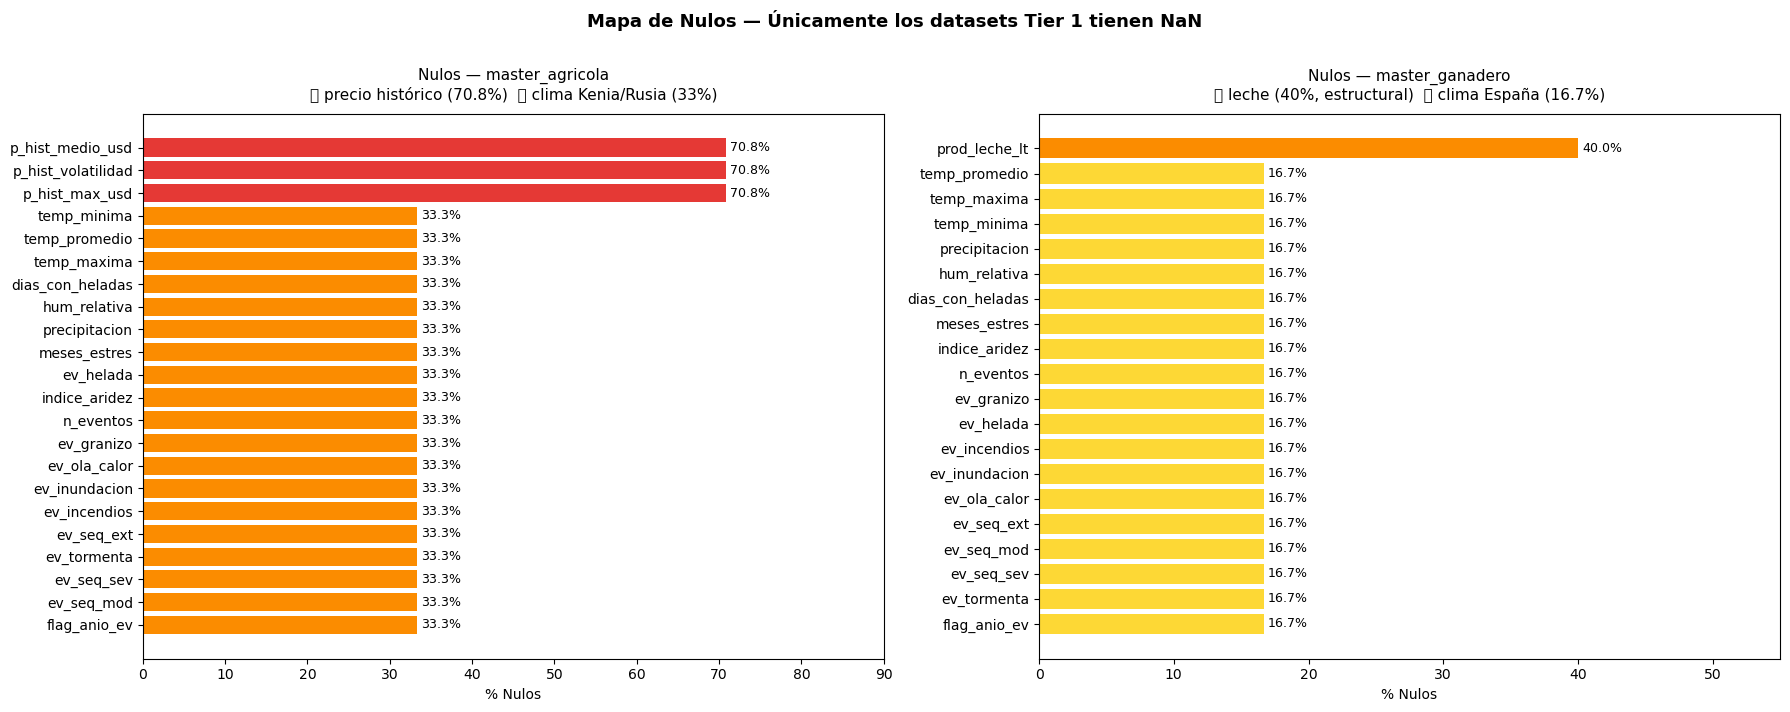

✅ Guardado: b0_mapa_nulos.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── master_agricola ──
null_agr = df_agr.isnull().sum()
null_agr = null_agr[null_agr > 0].sort_values(ascending=False)
pct_agr  = (null_agr / len(df_agr) * 100).round(1)
short_agr = [c.replace("precio_hist_","p_hist_")
              .replace("temperatura_","temp_")
              .replace("humedad_relativa_promedio","hum_relativa")
              .replace("precipitacion_total","precipitacion")
              .replace("meses_estres_hidrico","meses_estres")
              .replace("n_eventos_total_regiones","n_eventos")
              .replace("flag_sin_precio_historico","flag_sin_precio")
              .replace("flag_anio_eventos_extremos","flag_anio_ev")
              .replace("ev_tormenta_severa","ev_tormenta")
              .replace("ev_sequia_extrema","ev_seq_ext")
              .replace("ev_sequia_moderada","ev_seq_mod")
              .replace("ev_sequia_severa","ev_seq_sev")
              .replace("ev_helada_tardia","ev_helada")
             for c in null_agr.index]
colors_agr = ['#e53935' if v >= 50 else '#fb8c00' if v >= 30 else '#fdd835'
               for v in pct_agr.values]

bars1 = axes[0].barh(short_agr, pct_agr.values, color=colors_agr, edgecolor='none')
for bar, val in zip(bars1, pct_agr.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9)
axes[0].set_xlim(0, 90)
axes[0].set_xlabel("% Nulos")
axes[0].set_title("Nulos — master_agricola\n"
                   "🔴 precio histórico (70.8%)  🟠 clima Kenia/Rusia (33%)",
                   fontsize=11, pad=10)
axes[0].grid(False)
axes[0].invert_yaxis()

# ── master_ganadero ──
null_gan = df_gan.isnull().sum()
null_gan = null_gan[null_gan > 0].sort_values(ascending=False)
pct_gan  = (null_gan / len(df_gan) * 100).round(1)
short_gan = [c.replace("produccion_leche_lt","prod_leche_lt")
              .replace("temperatura_","temp_")
              .replace("humedad_relativa_promedio","hum_relativa")
              .replace("precipitacion_total","precipitacion")
              .replace("meses_estres_hidrico","meses_estres")
              .replace("n_eventos_total_regiones","n_eventos")
              .replace("flag_anio_eventos_extremos","flag_anio_ev")
              .replace("ev_tormenta_severa","ev_tormenta")
              .replace("ev_sequia_extrema","ev_seq_ext")
              .replace("ev_sequia_moderada","ev_seq_mod")
              .replace("ev_sequia_severa","ev_seq_sev")
              .replace("ev_helada_tardia","ev_helada")
             for c in null_gan.index]
colors_gan = ['#fb8c00' if v >= 30 else '#fdd835' for v in pct_gan.values]

bars2 = axes[1].barh(short_gan, pct_gan.values, color=colors_gan, edgecolor='none')
for bar, val in zip(bars2, pct_gan.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9)
axes[1].set_xlim(0, 55)
axes[1].set_xlabel("% Nulos")
axes[1].set_title("Nulos — master_ganadero\n"
                   "🟠 leche (40%, estructural)  🟡 clima España (16.7%)",
                   fontsize=11, pad=10)
axes[1].grid(False)
axes[1].invert_yaxis()

plt.suptitle("Mapa de Nulos — Únicamente los datasets Tier 1 tienen NaN",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("../documentacion/figures/b0_mapa_nulos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: b0_mapa_nulos.png")

Hay dos grupos de nulos perfectamente diferenciados y con causa conocida:

Grupo rojo (70.8%): Las tres columnas p_hist_medio_usd, p_hist_max_usd y p_hist_volatilidad son las más afectadas. Esto no es un error sino una consecuencia del diseño del dataset: 6 de los 10 cultivos (Algodón, Café, Caña de azúcar, Cebada, Girasol y Té) no tienen precio histórico disponible en la fuente original. Estas columnas no se deben imputar para los modelos P1/P5/P6; se usarán únicamente para los cultivos con precio confirmado (Soja, Maíz, Trigo, Arroz).

Grupo naranja (33.3%): Las 19 variables restantes (climáticas + eventos extremos) tienen exactamente el mismo porcentaje, lo que es la firma inequívoca de que el patrón de nulos es geográfico y uniforme: son Kenia y Rusia (2 de los 15 países = 13.3% × 2.5 cultivos promedio ≈ 33%). Estos son un nulos por ausencia en la fuente original, no por error de procesamiento. Estrategia de imputación: KNNImputer agrupando por región geográfica.

Panel derecho — master_ganadero:
Igual de limpio en su lectura:

prod_leche_lt (40%): Es el nulo más importante del proyecto y el más fácil de justificar. El 40% corresponde exactamente a las especies porcino + avícola (2 de los 5 tipos de ganado = 40%). No tiene sentido biológico y no se imputará: ya existe la columna flag_leche_no_aplica como indicador explícito para los modelos.

Variables climáticas (16.7%): El porcentaje idéntico en todas ellas delata que es España (1 de los 12 países = 8.3%) con datos de clima ausentes en origen. Misma estrategia que en master_agricola: imputación por proximidad geográfica (Europa Occidental).

Conclusión del mapa: No hay basura en los datos. El 100% de los NaN tiene causa documentada (ausencia de datos en datasets original) y una estrategia de tratamiento definida.

### 0.3. Conteo categorías clave

In [3]:
print("=" * 60)
print(" master_agricola")
print(f"   Países  ({df_agr['pais'].nunique()}): {', '.join(sorted(df_agr['pais'].unique()))}")
print(f"   Cultivos({df_agr['cultivo'].nunique()}): {', '.join(sorted(df_agr['cultivo'].unique()))}")
print(f"   Años    ({df_agr['anio'].nunique()}): {list(sorted(df_agr['anio'].unique()))}")

print("\n master_ganadero")
print(f"   Países      ({df_gan['pais'].nunique()}): {', '.join(sorted(df_gan['pais'].unique()))}")
print(f"   Tipo ganado ({df_gan['tipo_ganado'].nunique()}): {', '.join(sorted(df_gan['tipo_ganado'].unique()))}")
print(f"   Años        ({df_gan['anio'].nunique()}): {list(sorted(df_gan['anio'].unique()))}")

print("\n precios_mercado")
print(f"   Países   ({df_pre['pais'].nunique()}): {', '.join(sorted(df_pre['pais'].unique()))}")
print(f"   Productos({df_pre['producto'].nunique()}): {', '.join(sorted(df_pre['producto'].unique()))}")
print(f"   Rango fechas: {df_pre['fecha'].min().date()} → {df_pre['fecha'].max().date()}")

print("\n reportes_plagas")
print(f"   Países   ({df_pla['pais'].nunique()}): {', '.join(sorted(df_pla['pais'].unique()))}")
print(f"   Cultivos ({df_pla['cultivo'].nunique()}): {', '.join(sorted(df_pla['cultivo'].unique()))}")
print(f"   Agentes  ({df_pla['agente'].nunique()}): {', '.join(sorted(df_pla['agente'].unique()))}")
print(f"   Tratamientos: {', '.join(sorted(df_pla['tipo_tratamiento'].unique()))}")
print(f"   Rango fechas: {df_pla['fecha'].min().date()} → {df_pla['fecha'].max().date()}")

print("\n noticias")
print(f"   Categorías ({df_not['categoria'].nunique()}): {', '.join(sorted(df_not['categoria'].unique()))}")
print(f"   Fuentes    ({df_not['fuente'].nunique()}): {', '.join(sorted(df_not['fuente'].unique()))}")
print(f"   Sentimiento: {df_not['sentiment_label'].value_counts().to_dict()}")
print(f"   Rango fechas: {df_not['fecha'].min().date()} → {df_not['fecha'].max().date()}")

print("\n imagenes_metadata")
print(f"   Columnas totales: {len(df_ima.columns)}")
print(f"   Flags disponibles: flag_ndvi_anomalo, imagen_valida, banda_NIR/RGB/SWIR")
print("=" * 60)

 master_agricola
   Países  (15): Alemania, Argentina, Australia, Brasil, Canadá, China, España, Estados Unidos, Francia, India, Italia, Kenia, México, Nueva Zelanda, Rusia
   Cultivos(10): Algodón, Arroz, Café, Caña de azúcar, Cebada, Girasol, Maíz, Soja, Trigo, Té
   Años    (10): [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

 master_ganadero
   Países      (12): Alemania, Argentina, Australia, Brasil, China, España, Estados Unidos, Francia, India, Kenia, México, Nueva Zelanda
   Tipo ganado (5): avicola, bovino, caprino, ovino, porcino
   Años        (10): [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

 precios_mercado
   Países   (12): Alemania, Argentina, Australia, Brasil, China, España, Estados Unidos, Francia, India, Kenia, México, Nueva Zelanda
   Pr

`master_agricola` tiene 15 países pero `master_ganadero` y `precios_mercado` solo tienen 12. Faltan Italia, Canadá y Rusia en los datasets ganadero y de precios. Esto es relevante para el Bloque 2: los análisis cruzados entre agricultura y ganadería solo podrán hacerse sobre los 12 países comunes.

`reportes_plagas` solo cubre 8 países (ninguno de Europa continental salvo Alemania y Francia, sin España ni Italia). Esto limita el análisis de riesgo P2 a ese subconjunto.

GAP TEMPORAL: no existe solapamiento entre datos de producción (2011-2020) y precios/noticias (2021-2023).Por ello se tomó la decisión de no acometer el join entre el csv de precios con los de ganaderia y agricola.

## 1. Análisis univariable

### 1.1. Configuración visual

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
PALETTE_CULTIVOS  = sns.color_palette("tab10", 10)
PALETTE_GANADO    = sns.color_palette("Set2",  5)
PALETTE_PRODUCTOS = sns.color_palette("tab10", 7)

# Orden fijo para severidad
ORDEN_SEV = ["baja", "media", "alta", "critica"]

### 1.2. Master_Agricola

#### 1.2.1. Distribución variables productivas

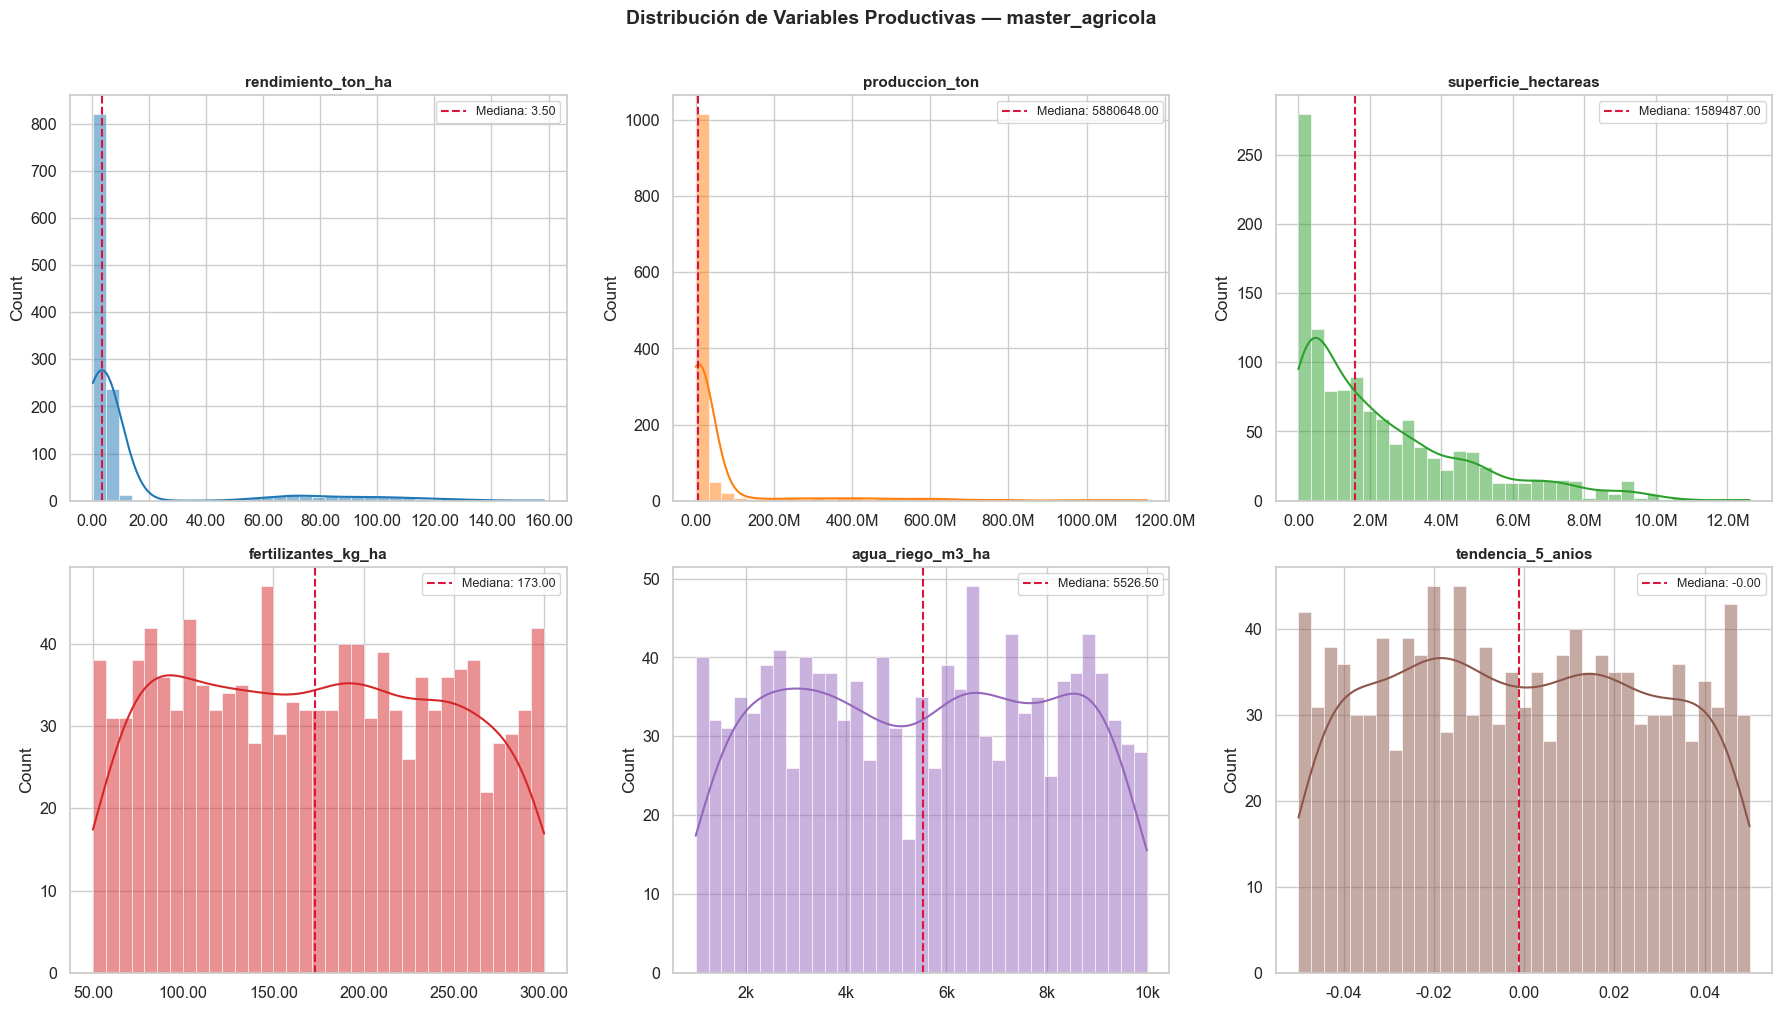

✅ Guardado: 1a_hist_productivas.png


In [5]:
cols_prod = [
    "rendimiento_ton_ha",
    "produccion_ton",
    "superficie_hectareas",
    "fertilizantes_kg_ha",
    "agua_riego_m3_ha",
    "tendencia_5_anios",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_prod):
    data = df_agr[col].dropna()
    sns.histplot(data, ax=axes[i], kde=True, bins=35,
                 color=PALETTE_CULTIVOS[i], edgecolor="white", linewidth=0.4)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if abs(x) >= 1e6
                               else f"{x/1e3:.0f}k" if abs(x) >= 1e3
                               else f"{x:.2f}")
    )
    # Línea vertical en la mediana
    axes[i].axvline(data.median(), color="crimson", linestyle="--",
                    linewidth=1.5, label=f"Mediana: {data.median():.2f}")
    axes[i].legend(fontsize=9)

fig.suptitle("Distribución de Variables Productivas — master_agricola",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../documentacion/figures/1a_hist_productivas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1a_hist_productivas.png")

#### 1.2.2. Variables climáticas

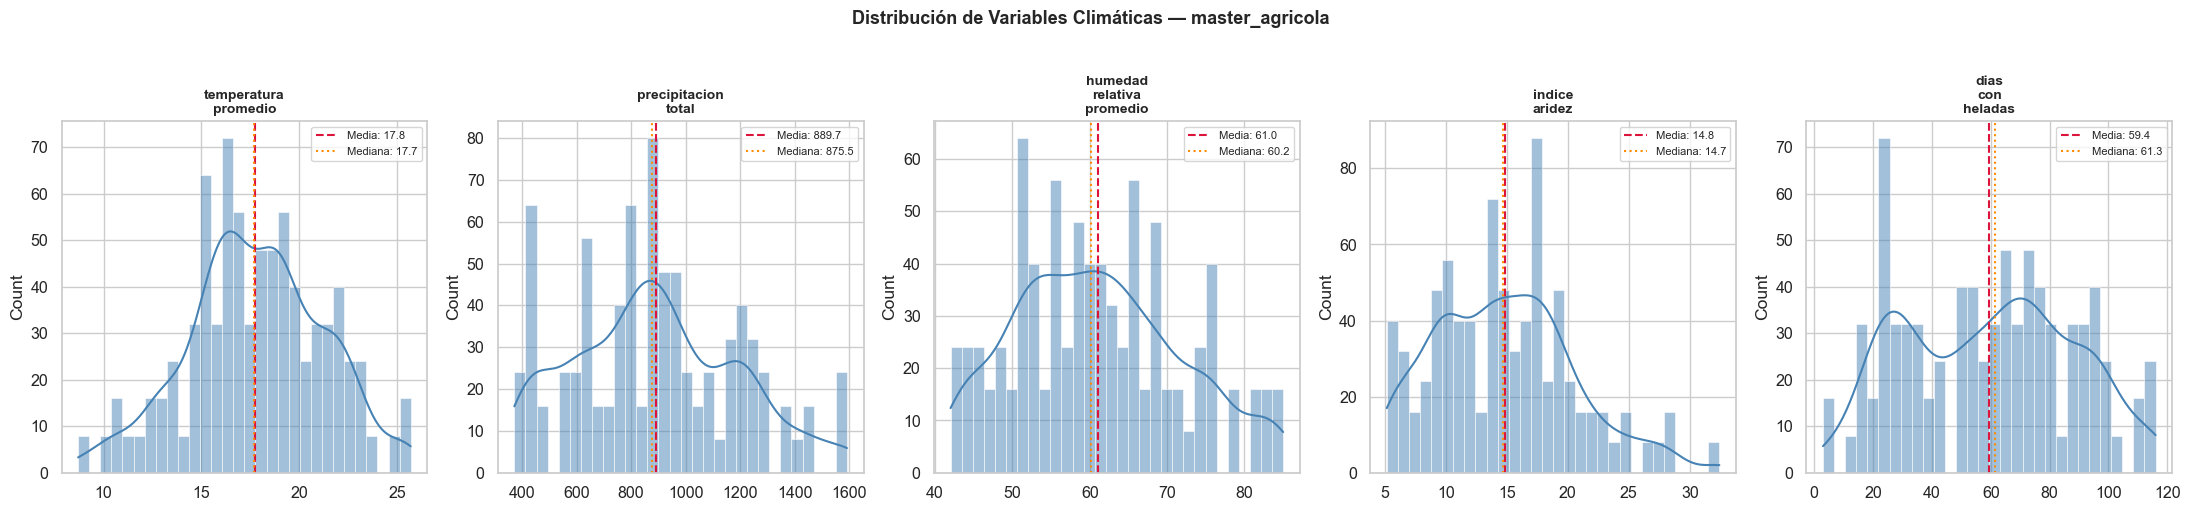

✅ Guardado: 1a_hist_climaticas.png


In [6]:
cols_clima = [
    "temperatura_promedio",
    "precipitacion_total",
    "humedad_relativa_promedio",
    "indice_aridez",
    "dias_con_heladas",
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(cols_clima):
    data = df_agr[col].dropna()
    sns.histplot(data, ax=axes[i], kde=True, bins=30,
                 color="steelblue", edgecolor="white", linewidth=0.4)
    axes[i].set_title(col.replace("_", "\n"), fontsize=10, fontweight="bold")
    axes[i].axvline(data.mean(),   color="crimson",  linestyle="--",
                    linewidth=1.5, label=f"Media: {data.mean():.1f}")
    axes[i].axvline(data.median(), color="darkorange", linestyle=":",
                    linewidth=1.5, label=f"Mediana: {data.median():.1f}")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("")

fig.suptitle("Distribución de Variables Climáticas — master_agricola",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../documentacion/figures/1a_hist_climaticas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1a_hist_climaticas.png")

#### 1.2.3. Variables rendimiento por cultivo

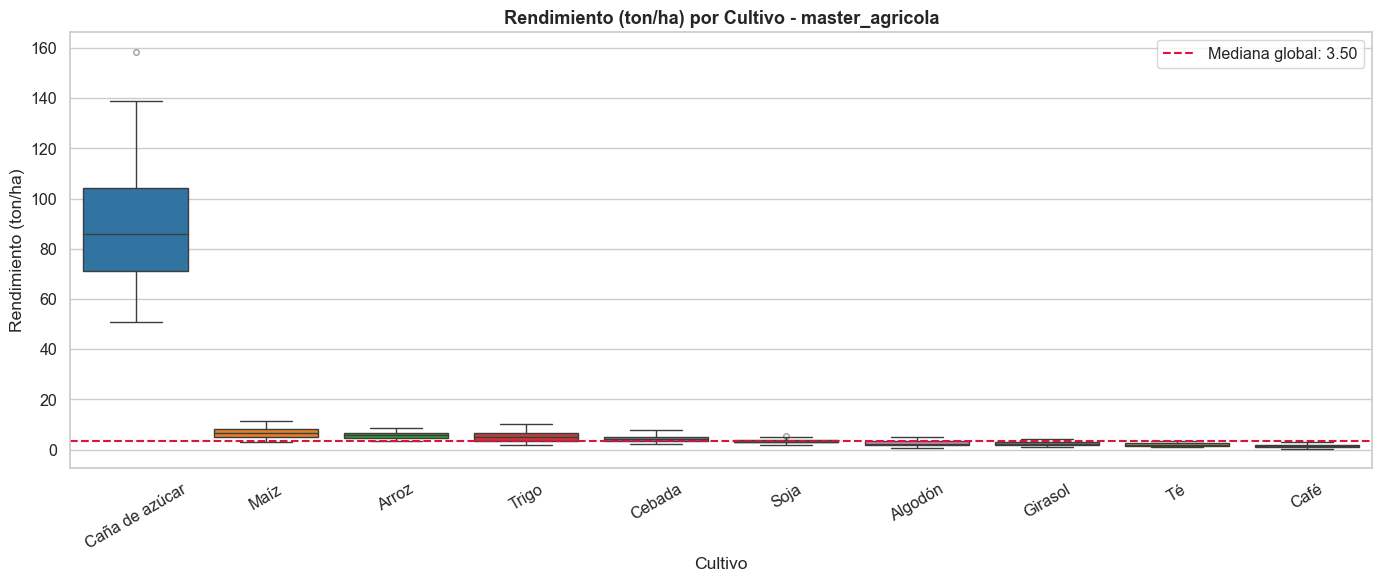

✅ Guardado: 1a_box_rendimiento_cultivo.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

orden_cultivos = (df_agr.groupby("cultivo")["rendimiento_ton_ha"]
                  .median().sort_values(ascending=False).index)

sns.boxplot(data=df_agr, x="cultivo", y="rendimiento_ton_ha",
            order=orden_cultivos, palette="tab10",
            flierprops=dict(marker="o", markersize=4, alpha=0.5),
            ax=ax)

ax.set_title("Rendimiento (ton/ha) por Cultivo - master_agricola",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Cultivo")
ax.set_ylabel("Rendimiento (ton/ha)")
ax.tick_params(axis="x", rotation=30)

# Línea de referencia: mediana global
mediana_global = df_agr["rendimiento_ton_ha"].median()
ax.axhline(mediana_global, color="crimson", linestyle="--",
           linewidth=1.5, label=f"Mediana global: {mediana_global:.2f}")
ax.legend()

plt.tight_layout()
plt.savefig("../documentacion/figures/1a_box_rendimiento_cultivo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1a_box_rendimiento_cultivo.png")

#### 1.2.4. Boxplots climáticos por cultivo

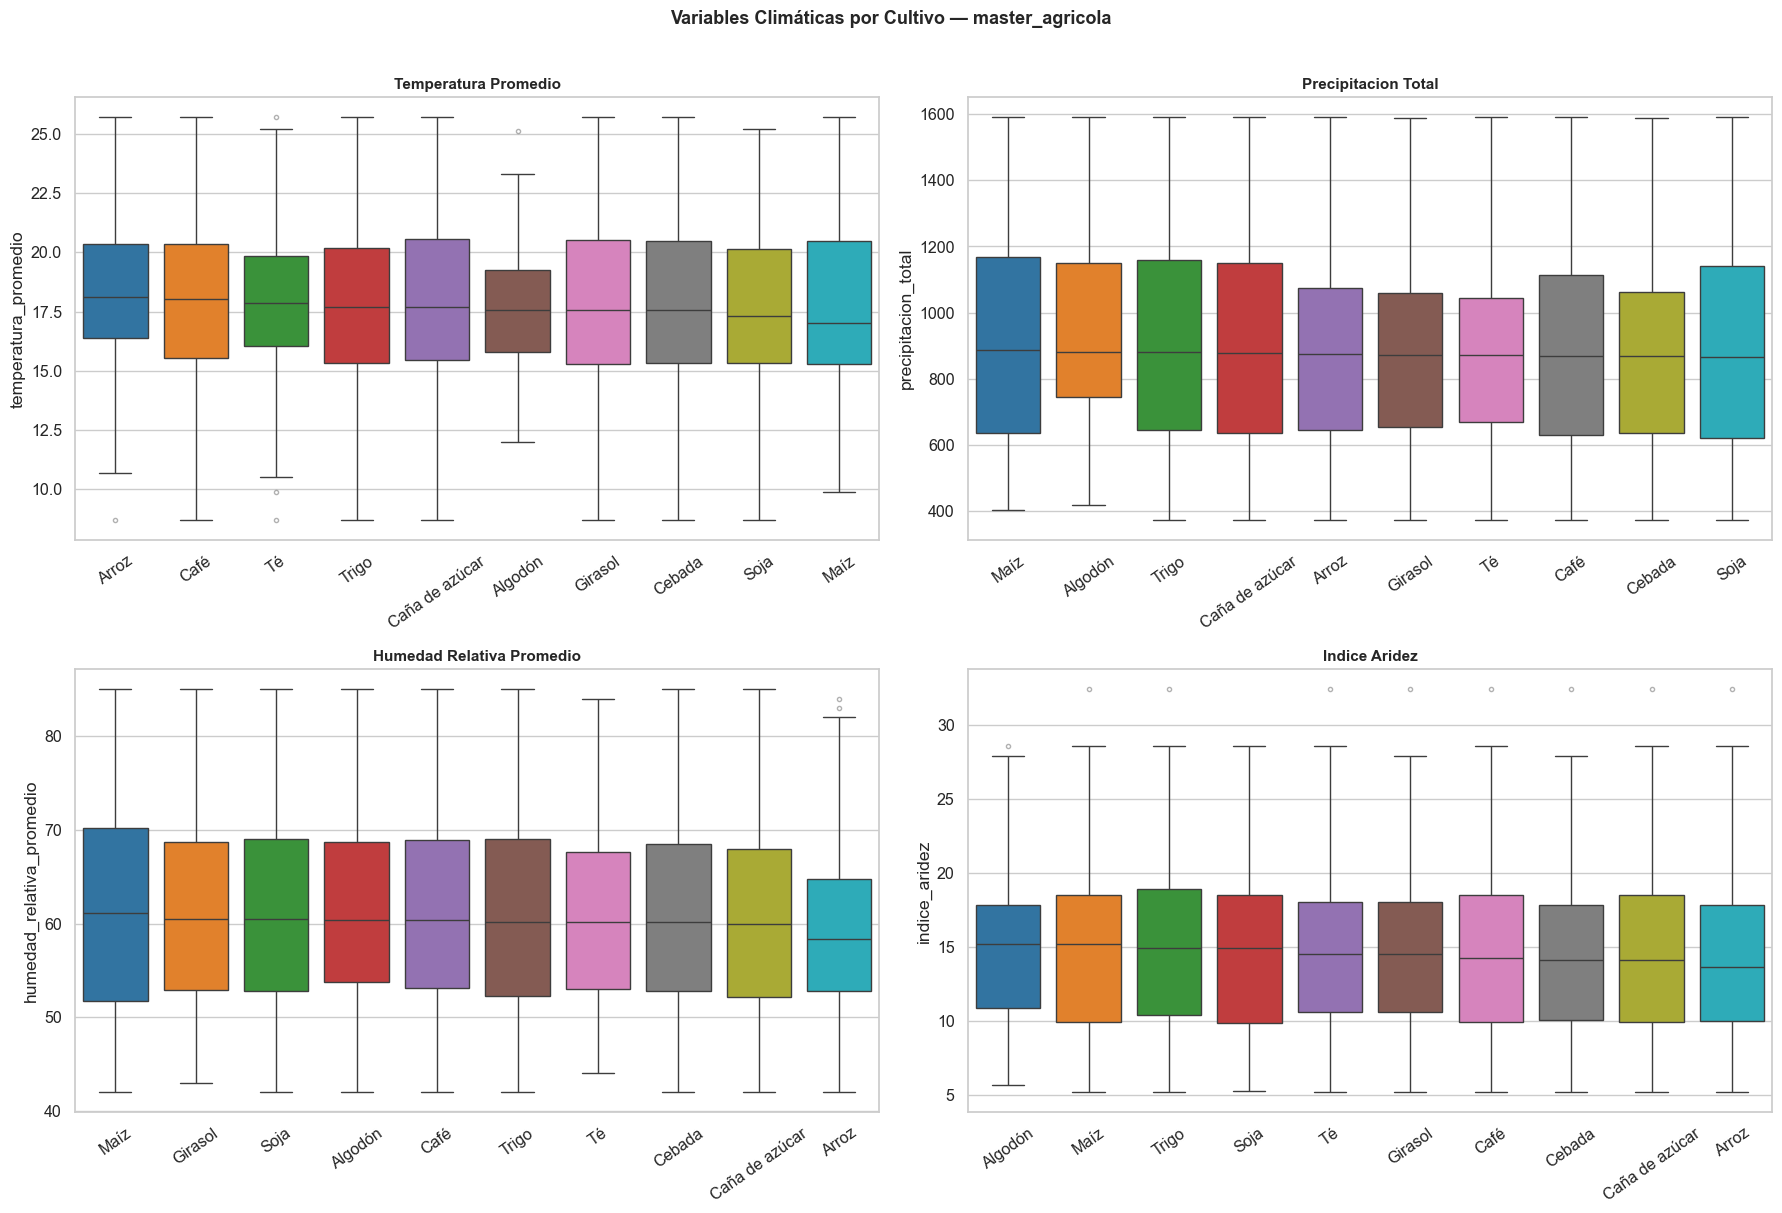

✅ Guardado: 1a_box_clima_cultivo.png


In [8]:
# Variables climáticas más relevantes agrupadas por cultivo
cols_box = ["temperatura_promedio", "precipitacion_total",
            "humedad_relativa_promedio", "indice_aridez"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_box):
    orden_c = (df_agr.groupby("cultivo")[col]
               .median().sort_values(ascending=False).index)
    sns.boxplot(data=df_agr.dropna(subset=[col]),
                x="cultivo", y=col, order=orden_c,
                palette="tab10", ax=axes[i],
                flierprops=dict(marker="o", markersize=3, alpha=0.4))
    axes[i].set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=35)

fig.suptitle("Variables Climáticas por Cultivo — master_agricola",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../documentacion/figures/1a_box_clima_cultivo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1a_box_clima_cultivo.png")

#### 1.2.5. histograma de flag por país

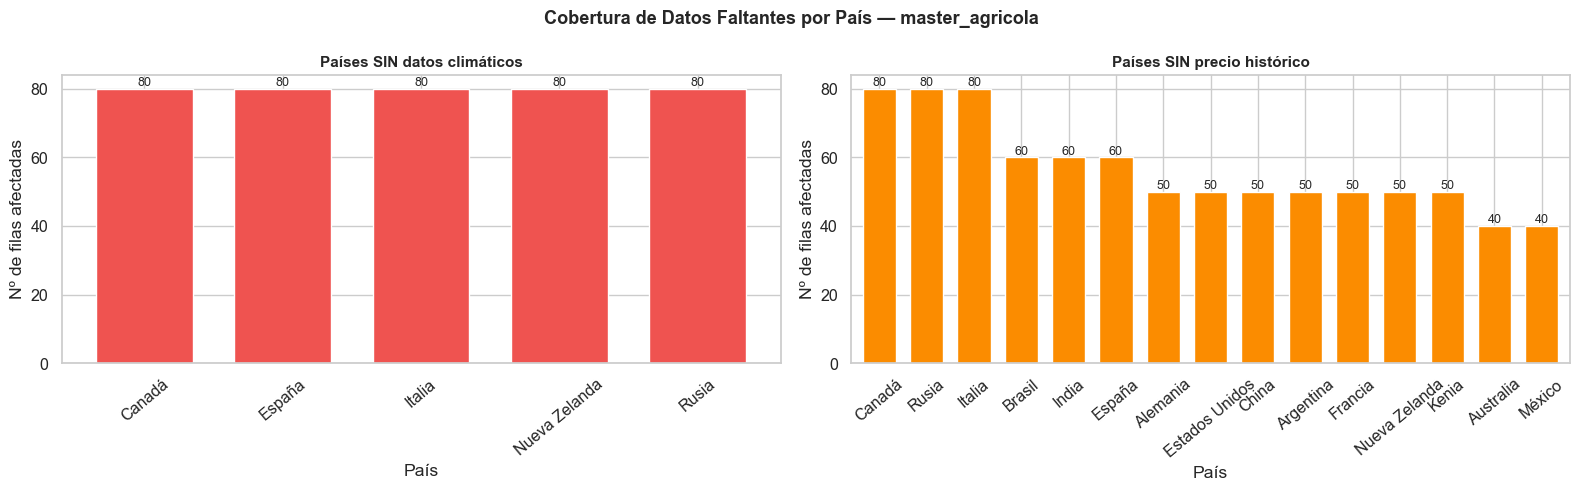

✅ Guardado: 1a_flags_pais.png


In [9]:
# Calcular flags por país (un valor por país: 0 o 1, pero tomamos el max)
flags_pais = (df_agr.groupby("pais")[["flag_sin_clima", "flag_sin_precio_historico"]]
              .max().reset_index()
              .melt(id_vars="pais", var_name="flag", value_name="valor"))
flags_pais = flags_pais[flags_pais["valor"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, flag_name, color, titulo in zip(
    axes,
    ["flag_sin_clima", "flag_sin_precio_historico"],
    ["#ef5350", "#fb8c00"],
    ["Países SIN datos climáticos", "Países SIN precio histórico"]
):
    subset = flags_pais[flags_pais["flag"] == flag_name]["pais"].tolist()
    total_paises = df_agr["pais"].nunique()
    
    # Conteo de filas nulas por país
    if flag_name == "flag_sin_clima":
        conteo = (df_agr[df_agr["flag_sin_clima"] == 1]
                  .groupby("pais").size().sort_values(ascending=False))
    else:
        conteo = (df_agr[df_agr["flag_sin_precio_historico"] == 1]
                  .groupby("pais").size().sort_values(ascending=False))
    
    conteo.plot(kind="bar", ax=ax, color=color, edgecolor="white", width=0.7)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("País")
    ax.set_ylabel("Nº de filas afectadas")
    ax.tick_params(axis="x", rotation=40)
    
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)

fig.suptitle("Cobertura de Datos Faltantes por País — master_agricola",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/1a_flags_pais.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1a_flags_pais.png")

#### Insights Bloque 1.2 — Master Agrícola

#### Variables Productivas
- `rendimiento_ton_ha`, `produccion_ton` y `superficie_hectareas` siguen distribución
  **log-normal** → aplicar `log1p()` obligatorio antes de entrenar modelos P1/P5/P6.
- `fertilizantes_kg_ha` y `agua_riego_m3_ha` muestran distribución casi uniforme,
  síntoma de generación sintética con rango fijo. **Limitación a documentar**:
  los modelos pueden obtener métricas artificialmente buenas.
- `tendencia_5_anios` centrada en 0 y simétrica → no requiere transformación.

#### Variables Climáticas
- Distribuciones gaussianas sin outliers extremos → no requieren transformación.
- `precipitacion_total` presenta **bimodalidad** (~600 mm y ~1.100 mm), indicando
  dos regímenes climáticos diferenciados. Candidata a feature binaria `zona_humeda`.
- `dias_con_heladas` muy discriminante geográficamente (0 en trópicos, >100 en
  Rusia/Canadá) → feature clave para el modelo P6 de recomendación de cultivos.

#### Rendimiento por Cultivo
- **Caña de azúcar** (~80-100 ton/ha) domina la escala por diferencia de unidad
  (biomasa fresca vs grano seco en el resto). No es comparable directamente.
  **Estrategia**: normalizar por cultivo o entrenar modelo separado para P1/P6.

#### Boxplots Climáticos por Cultivo
- Variables climáticas idénticas entre cultivos del mismo país-año (JOIN a nivel
  país sin resolución subnacional). **Limitación estructural del dataset**: el clima
  no discrimina entre cultivos, solo entre países.

#### Flags por País
- **Corrección respecto al Bloque 0**: los países sin datos climáticos son **5**
  (Canadá, España, Italia, Nueva Zelanda, Rusia), no 2 como se indicó inicialmente.
- El flag de precio histórico afecta a todos los países por igual: es un nulo
  **por cultivo** (6 cultivos sin precio), no geográfico.

### 1.3. master_ganadero.csv

#### 1.3.1. Histogramas variables ganaderas

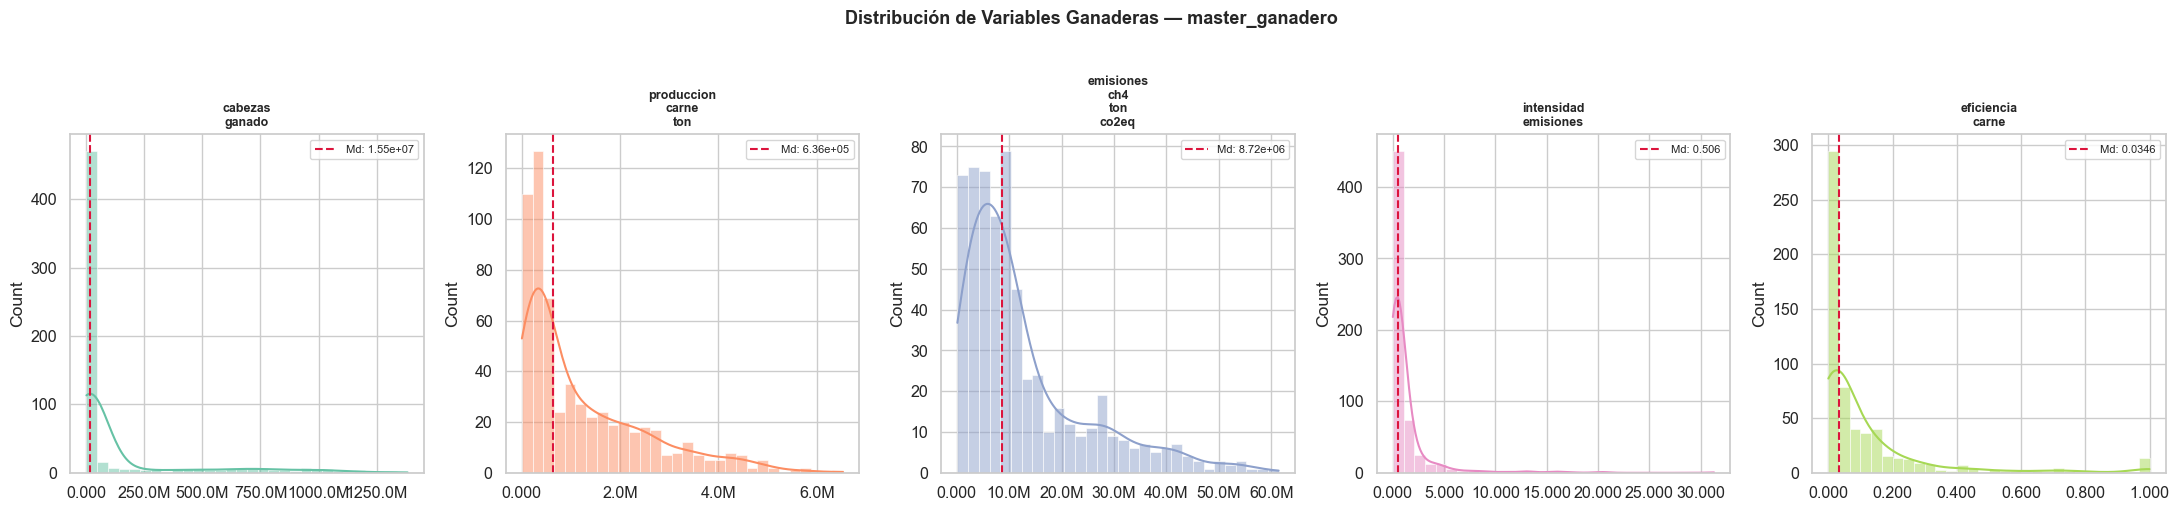

✅ Guardado: 1b_hist_ganadero.png


In [10]:
cols_gan = [
    "cabezas_ganado",
    "produccion_carne_ton",
    "emisiones_ch4_ton_co2eq",
    "intensidad_emisiones",
    "eficiencia_carne",
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(cols_gan):
    data = df_gan[col].dropna()
    sns.histplot(data, ax=axes[i], kde=True, bins=30,
                 color=PALETTE_GANADO[i], edgecolor="white", linewidth=0.4)
    axes[i].set_title(col.replace("_", "\n"), fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if abs(x) >= 1e6
                               else f"{x/1e3:.0f}k" if abs(x) >= 1e3
                               else f"{x:.3f}")
    )
    axes[i].axvline(data.median(), color="crimson", linestyle="--",
                    linewidth=1.5, label=f"Md: {data.median():.3g}")
    axes[i].legend(fontsize=8)

fig.suptitle("Distribución de Variables Ganaderas — master_ganadero",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../documentacion/figures/1b_hist_ganadero.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1b_hist_ganadero.png")

#### 1.3.2. Boxplots por tipo de ganado

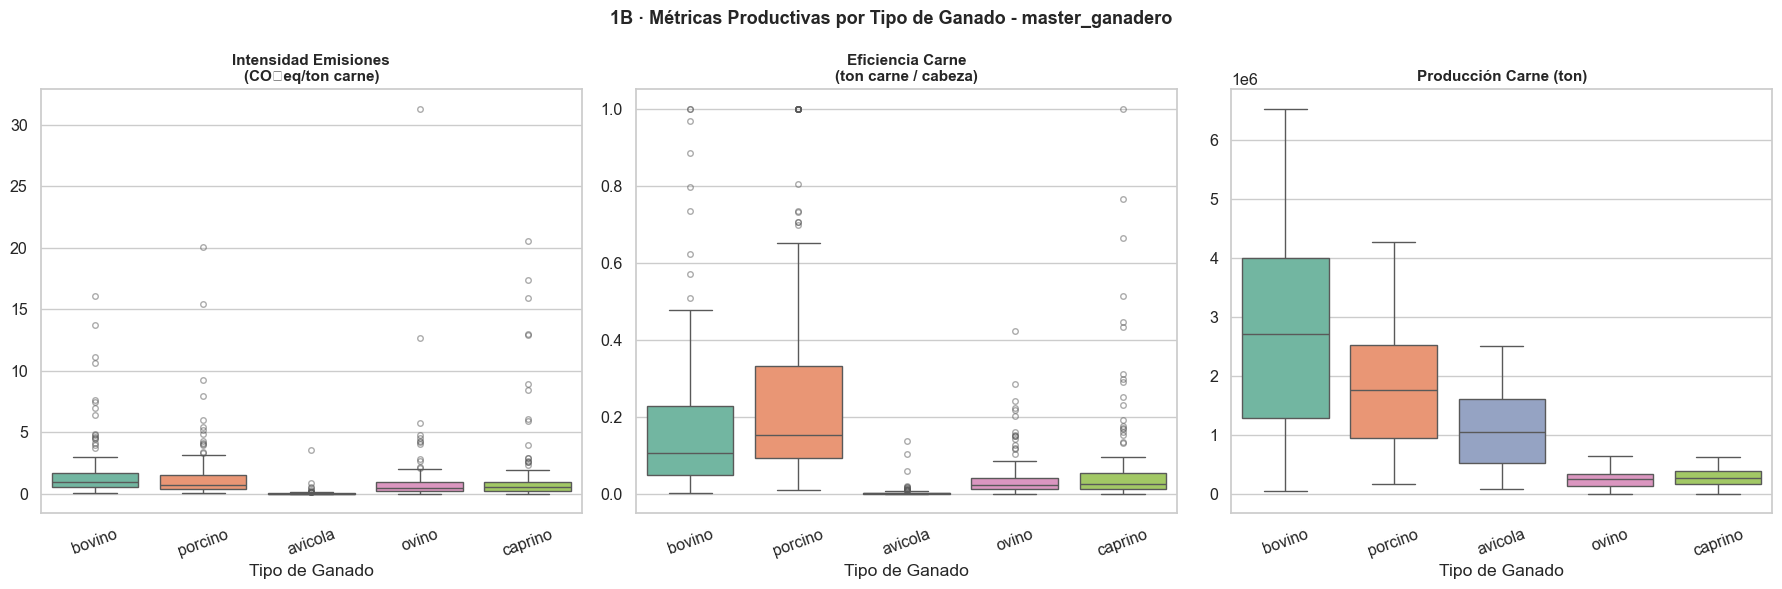

✅ Guardado: 1b_box_tipo_ganado.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, titulo in zip(
    axes,
    ["intensidad_emisiones", "eficiencia_carne", "produccion_carne_ton"],
    ["Intensidad Emisiones\n(CO₂eq/ton carne)",
     "Eficiencia Carne\n(ton carne / cabeza)",
     "Producción Carne (ton)"]
):
    sns.boxplot(data=df_gan.dropna(subset=[col]),
                x="tipo_ganado", y=col, palette="Set2", ax=ax,
                flierprops=dict(marker="o", markersize=4, alpha=0.5))
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("Tipo de Ganado")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("1B · Métricas Productivas por Tipo de Ganado - master_ganadero",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/1b_box_tipo_ganado.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1b_box_tipo_ganado.png")

#### 1.3.3. Pie Chart: Distribución de Tipo de Ganado

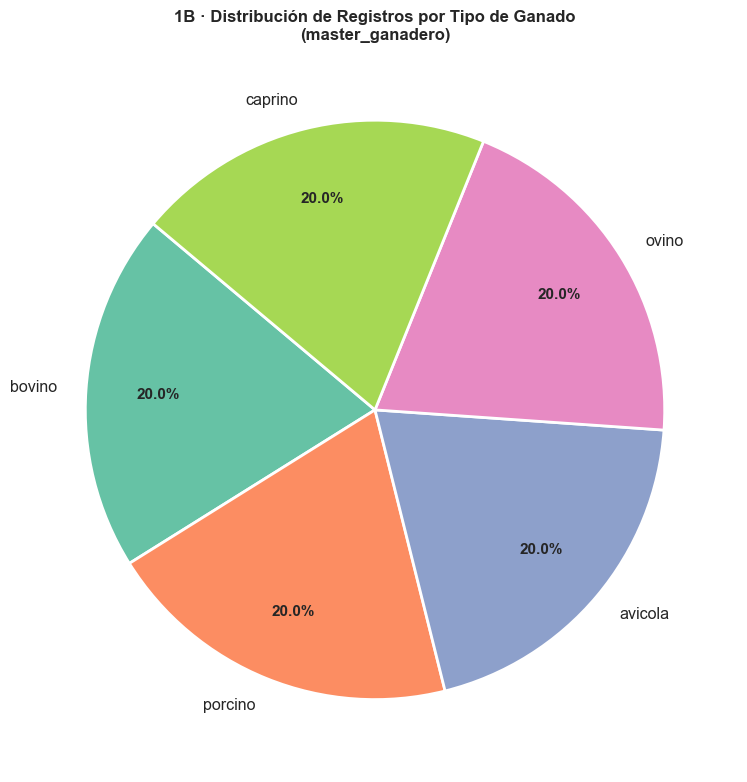

✅ Guardado: 1b_pie_tipo_ganado.png


In [12]:
dist_ganado = df_gan["tipo_ganado"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    dist_ganado.values,
    labels=dist_ganado.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2", len(dist_ganado)),
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")

ax.set_title("1B · Distribución de Registros por Tipo de Ganado\n(master_ganadero)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/1b_pie_tipo_ganado.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1b_pie_tipo_ganado.png")

#### 1.3.4. Flags de Anomalías Ganaderas

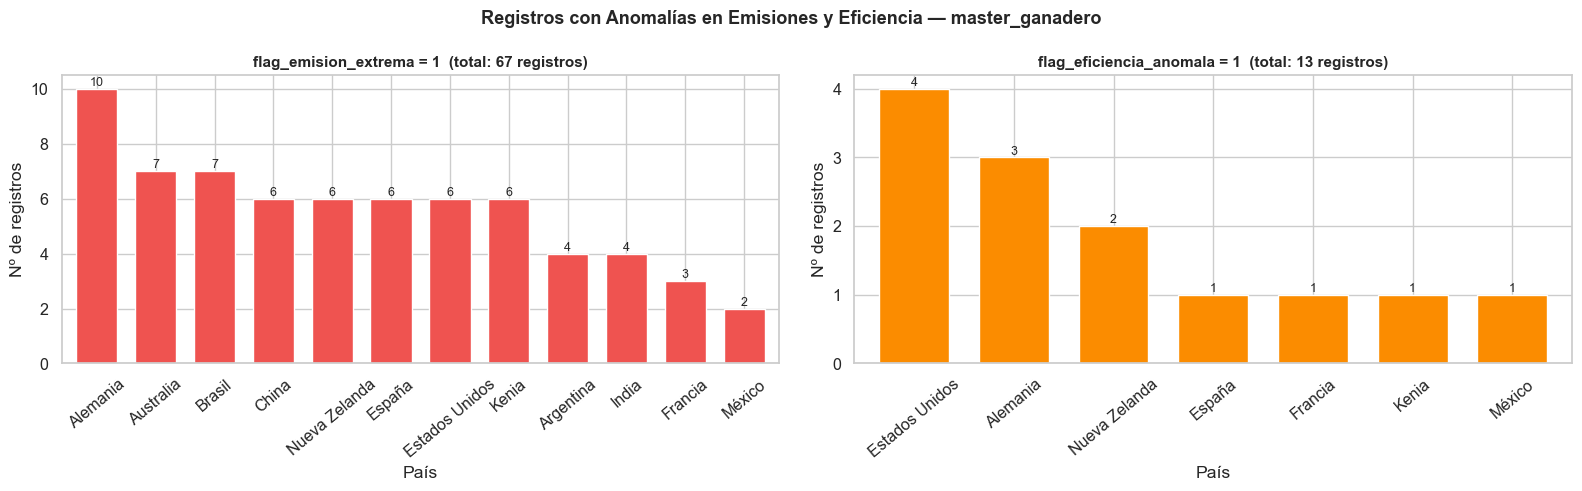


── flag_emision_extrema por país y año ──
          pais  anio tipo_ganado  n
      Alemania  2011     caprino  1
      Alemania  2011     porcino  1
      Alemania  2012     caprino  1
      Alemania  2012     porcino  1
      Alemania  2013      bovino  1
      Alemania  2016      bovino  1
      Alemania  2017     caprino  1
      Alemania  2018     caprino  1
      Alemania  2019      bovino  1
      Alemania  2020      bovino  1
     Argentina  2014      bovino  1
     Argentina  2017      bovino  1
     Argentina  2019     porcino  1
     Argentina  2020     caprino  1
     Australia  2012     caprino  1
     Australia  2013      bovino  1
     Australia  2013     caprino  1
     Australia  2013       ovino  1
     Australia  2013     porcino  1
     Australia  2015      bovino  1
     Australia  2020       ovino  1
        Brasil  2011      bovino  1
        Brasil  2012     porcino  1
        Brasil  2013      bovino  1
        Brasil  2013     caprino  1
        Brasil  2013 

In [13]:
flag_em  = df_gan[df_gan["flag_emision_extrema"]   == 1]
flag_ef  = df_gan[df_gan["flag_eficiencia_anomala"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Flag emisión extrema por país
conteo_em = flag_em.groupby("pais").size().sort_values(ascending=False)
conteo_em.plot(kind="bar", ax=axes[0], color="#ef5350", edgecolor="white", width=0.7)
axes[0].set_title(f"flag_emision_extrema = 1  (total: {len(flag_em)} registros)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("País"); axes[0].set_ylabel("Nº de registros")
axes[0].tick_params(axis="x", rotation=40)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

# Flag eficiencia anómala por país
conteo_ef = flag_ef.groupby("pais").size().sort_values(ascending=False)
conteo_ef.plot(kind="bar", ax=axes[1], color="#fb8c00", edgecolor="white", width=0.7)
axes[1].set_title(f"flag_eficiencia_anomala = 1  (total: {len(flag_ef)} registros)",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("País"); axes[1].set_ylabel("Nº de registros")
axes[1].tick_params(axis="x", rotation=40)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

fig.suptitle("Registros con Anomalías en Emisiones y Eficiencia — master_ganadero",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/1b_flags_anomalias.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla detallada de anomalías por país y año
print("\n── flag_emision_extrema por país y año ──")
print(flag_em.groupby(["pais","anio","tipo_ganado"]).size()
      .reset_index(name="n").to_string(index=False))
print("\n── flag_eficiencia_anomala por país y año ──")
print(flag_ef.groupby(["pais","anio","tipo_ganado"]).size()
      .reset_index(name="n").to_string(index=False))

#### Insights Bloque 1.3 — Master Ganadero

#### Variables Ganaderas (Histogramas)
- `cabezas_ganado`, `produccion_carne_ton` y `emisiones_ch4_ton_co2eq` siguen
  distribución **log-normal** → aplicar `log1p()` igual que en master_agricola.
- `intensidad_emisiones` y `eficiencia_carne` están fuertemente concentradas cerca
  de cero con cola derecha pronunciada → también candidatas a `log1p()`.

#### Métricas por Tipo de Ganado (Boxplots)
- La hipótesis tradicional "bovino más emisor" **no se confirma claramente** en intensidad media:
  todos los tipos tienen medianas similares (~1-2 CO₂eq/ton). Las diferencias están
  en los **outliers extremos**, dominados por bovino, porcino y caprino.
- **Avícola**: mínima intensidad de emisiones Y mínima eficiencia carne
  (kg carne/cabeza). Esto no es contradicción: los pollos pesan mucho menos
  individualmente, pero son más eficientes en conversión de pienso a carne.
  En sostenibilidad real, el avícola es el tipo de ganado **más sostenible**.
- **Porcino**: mayor eficiencia carne del dataset, coherente con que el cerdo
  tiene mayor aprovechamiento de canal (~80%) frente al bovino (~60%).
- **Bovino y porcino** lideran producción total de carne, lo que refleja fielmente
  la realidad global del consumo humano.

#### Pie Chart — Distribución de Tipo de Ganado
- Distribución perfectamente uniforme (20% cada especie) → artefacto sintético.
  En datos reales el bovino y avícola representarían proporciones muy superiores.
  **Implicación**: el modelo P3 no tendrá sesgo de clase por tipo de ganado,
  pero tampoco aprenderá patrones de frecuencia real.

#### Flags de Anomalías
- Los **67 registros con `flag_emision_extrema=1` son exclusivamente emisiones
  ALTAS** (outliers por encima del límite IQR superior). No hay ningún caso de
  emisión extremadamente baja.
- Por especie: bovino (21), porcino (20) y caprino (15) concentran el 93% de
  los outliers. Avícola tiene solo 1 caso extremo.
- La distribución geográfica de anomalías es **uniforme entre países** sin patrón
  claro de regulación o región → confirma origen sintético, no refleja diferencias
  reales de política medioambiental.
- **Estrategia**: estos 67 registros deben **conservarse** en el dataset como casos
  reales posibles, pero conviene añadir `flag_emision_extrema` como feature binaria
  en el modelo P3 para que el modelo aprenda a identificarlos.

### 1.4. precios_mercado.csv

#### 1.4.1. Histogramas de Precio por Producto

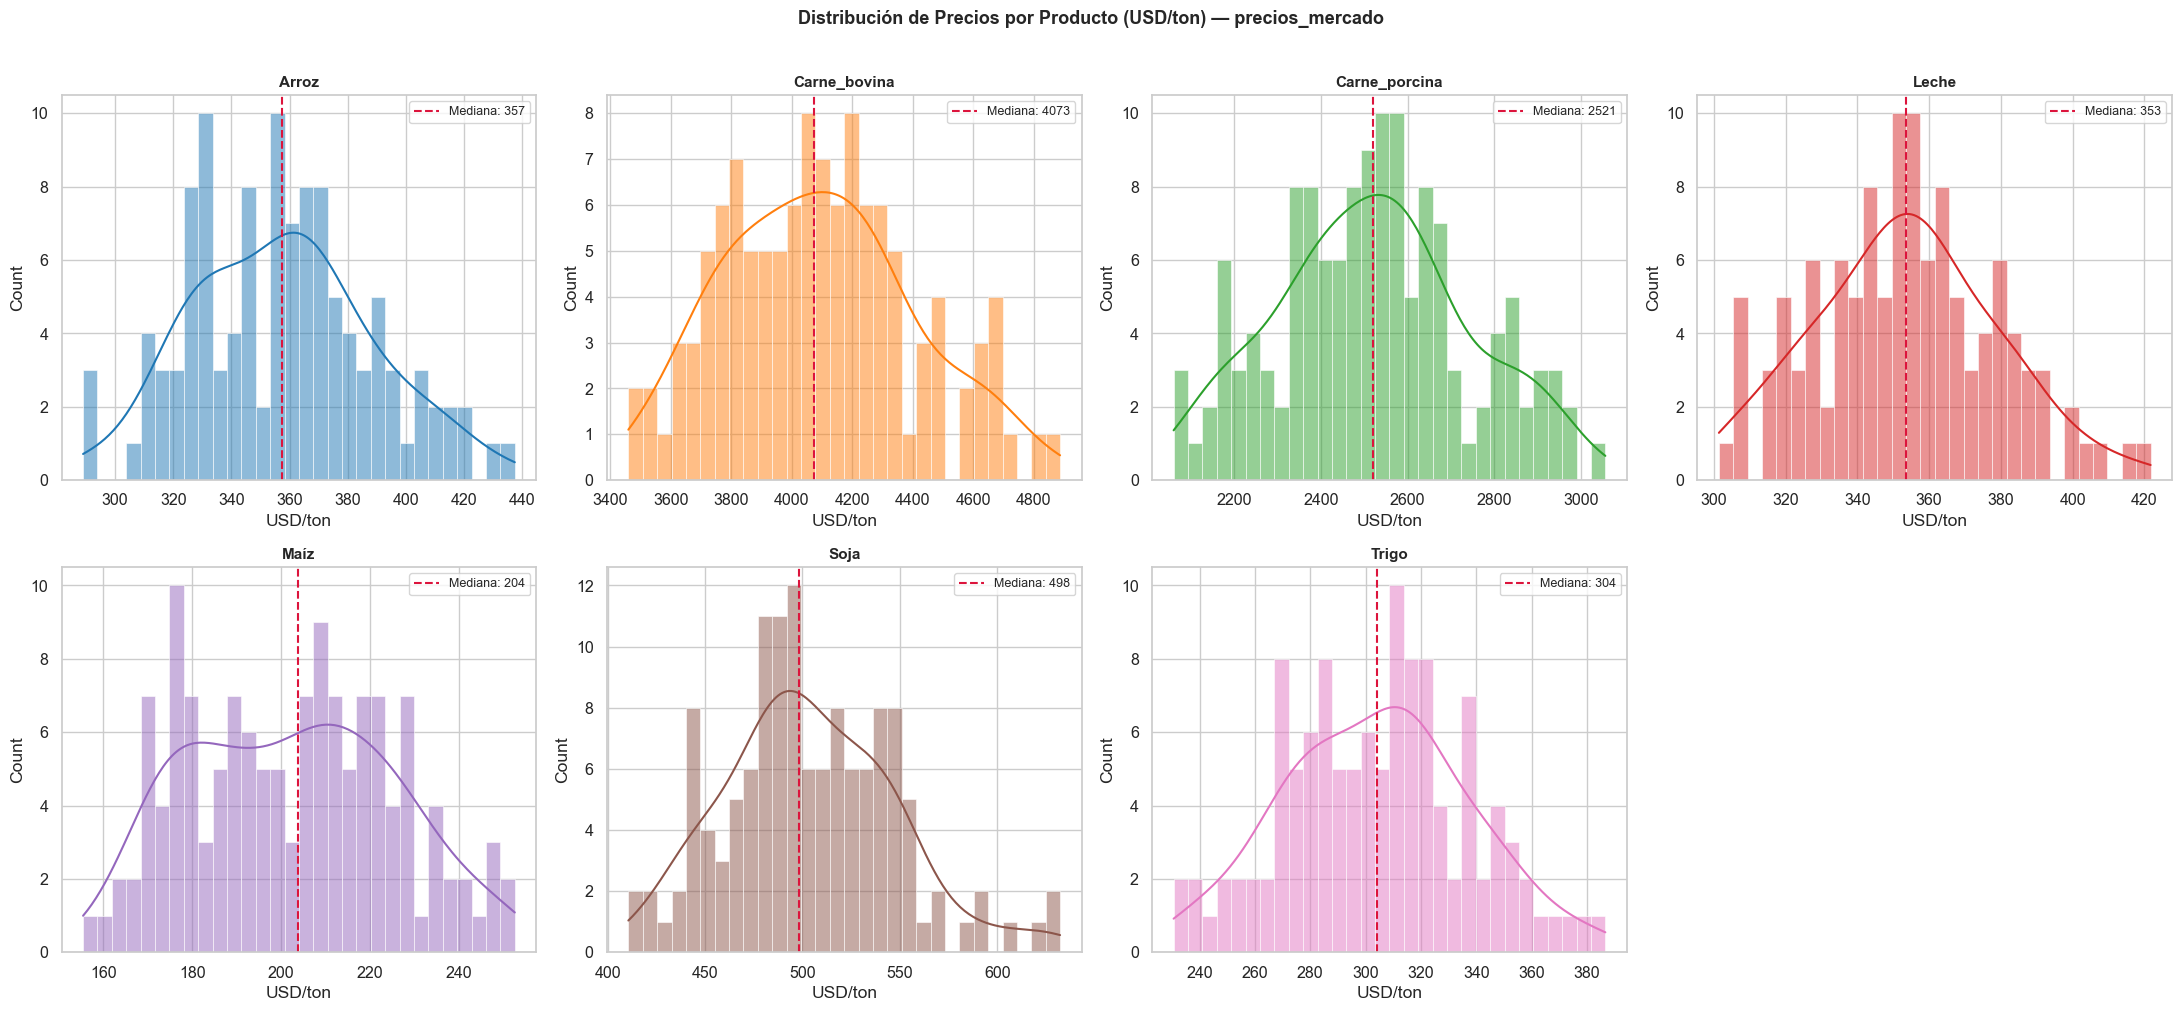

✅ Guardado: 1c_hist_precios_producto.png


In [14]:
productos = sorted(df_pre["producto"].unique())
n = len(productos)  # 7

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, prod in enumerate(productos):
    data = df_pre[df_pre["producto"] == prod]["precio_usd_ton"]
    sns.histplot(data, ax=axes[i], kde=True, bins=30,
                 color=PALETTE_PRODUCTOS[i], edgecolor="white", linewidth=0.4)
    axes[i].set_title(prod, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("USD/ton")
    med = data.median()
    axes[i].axvline(med, color="crimson", linestyle="--",
                    linewidth=1.5, label=f"Mediana: {med:.0f}")
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)  # Ocultar el 8º subplot vacío

fig.suptitle("Distribución de Precios por Producto (USD/ton) — precios_mercado",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../documentacion/figures/1c_hist_precios_producto.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1c_hist_precios_producto.png")

#### 1.4.2. boxplot de precio/producto

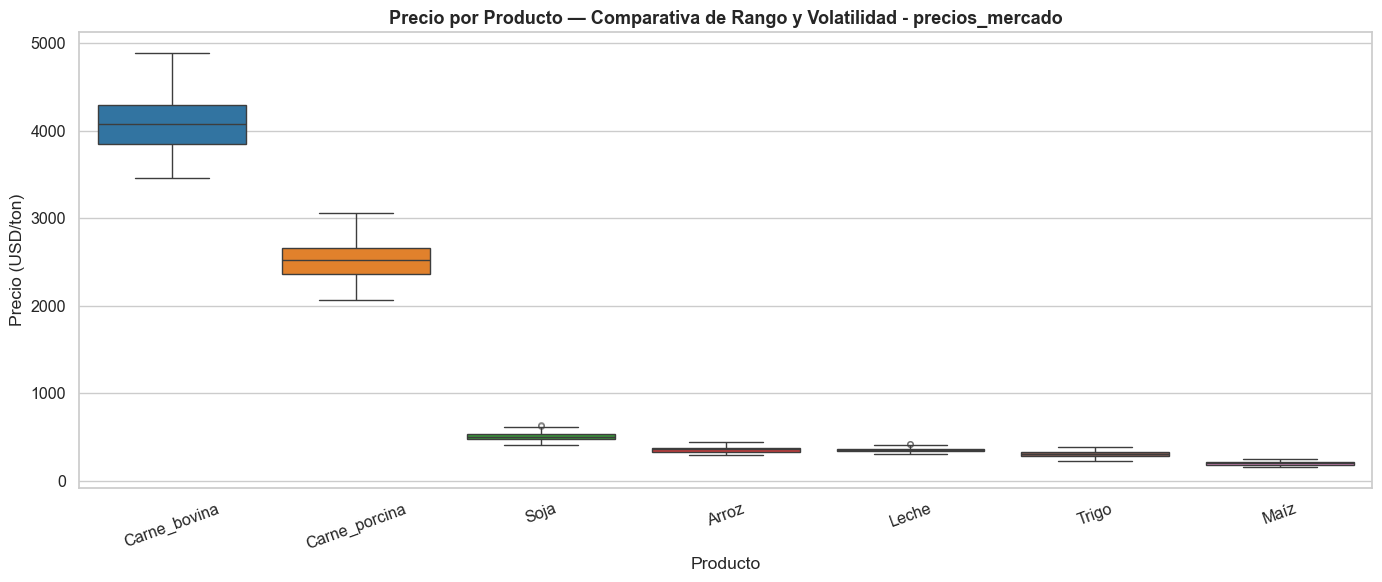

✅ Guardado: 1c_box_precio_producto.png


In [15]:
orden_prod = (df_pre.groupby("producto")["precio_usd_ton"]
              .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_pre, x="producto", y="precio_usd_ton",
            order=orden_prod, palette="tab10", ax=ax,
            flierprops=dict(marker="o", markersize=4, alpha=0.5))

ax.set_title("Precio por Producto — Comparativa de Rango y Volatilidad - precios_mercado",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Producto")
ax.set_ylabel("Precio (USD/ton)")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../documentacion/figures/1c_box_precio_producto.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1c_box_precio_producto.png")

#### 1.4.3. Tendencia precio/producto a 30 días

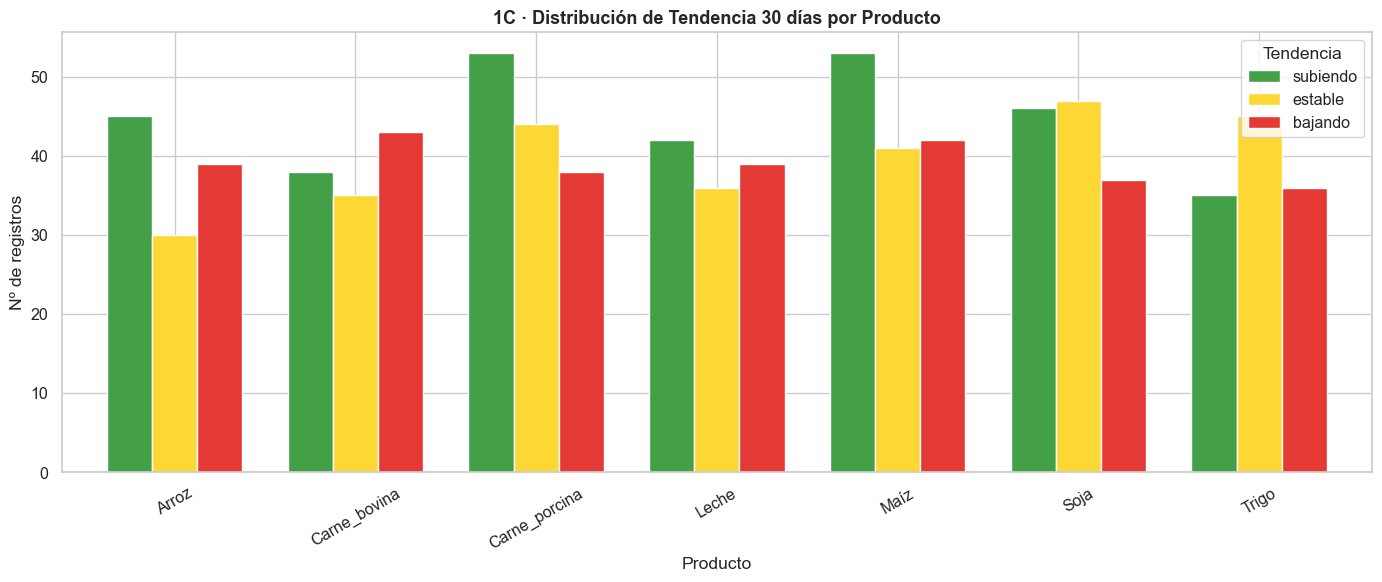

✅ Guardado: 1c_tendencia_producto.png


In [16]:
tend = (df_pre.groupby(["producto", "tendencia_30_dias"])
        .size().reset_index(name="n"))

fig, ax = plt.subplots(figsize=(14, 6))
tend_pivot = tend.pivot(index="producto", columns="tendencia_30_dias", values="n").fillna(0)
# Reordenar columnas
for col in ["subiendo", "estable", "bajando"]:
    if col not in tend_pivot.columns:
        tend_pivot[col] = 0
tend_pivot = tend_pivot[["subiendo", "estable", "bajando"]]

tend_pivot.plot(kind="bar", ax=ax, color=["#43a047","#fdd835","#e53935"],
                edgecolor="white", width=0.75)

ax.set_title("1C · Distribución de Tendencia 30 días por Producto",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Producto"); ax.set_ylabel("Nº de registros")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Tendencia", loc="upper right")

plt.tight_layout()
plt.savefig("../documentacion/figures/1c_tendencia_producto.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1c_tendencia_producto.png")

#### Insights Bloque 1.4 — Precios Mercado

#### Precio/Producto (Histogramas) y precio/producto boxplots
- Histogramas con distribución Gaussiana, tanto apoyándote en las medianas de precios de los histogramas como en la visualización de los boxplots, se observa la siguiente jerarquía de precios,  con bovino,  y porcino a la cabeza, con un buen gap entre ellos de 1500 $ aprox. y mucha distancia sobre la soja y algo más alejado después de la soja lo demás arroz, leche, etc.

#### Distribución tendencia precios
- Todo muy uniforme, no se observa un patrón claro de algún producto con una tendencia clara

### 1.5. reportes_plagas.csv

#### 1.5.1. Severidad, Tipo Agente y Agentes Más Frecuentes

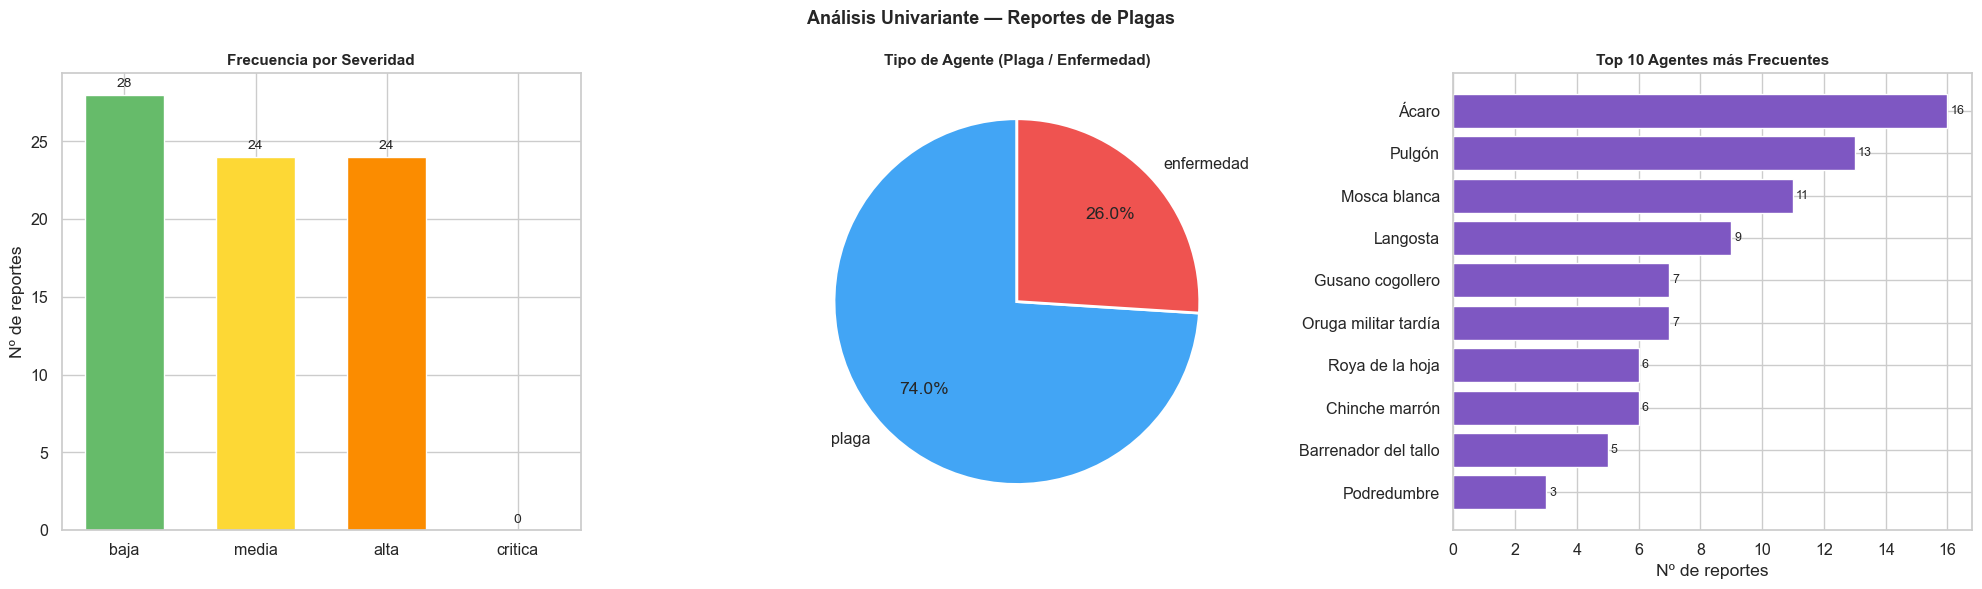

✅ Guardado: 1d_plagas_univariante.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Barplot Severidad ──
sev_count = df_pla["severidad"].value_counts().reindex(ORDEN_SEV).fillna(0)
bars = axes[0].bar(sev_count.index, sev_count.values,
                   color=["#66bb6a","#fdd835","#fb8c00","#e53935"],
                   edgecolor="white", width=0.6)
axes[0].set_title("Frecuencia por Severidad", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Nº de reportes")
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f"{int(b.get_height())}", ha="center", va="bottom", fontsize=10)

# ── Pie Tipo Agente ──
tipo = df_pla["tipo_agente"].value_counts()
axes[1].pie(tipo.values, labels=tipo.index, autopct="%1.1f%%",
            colors=["#42a5f5","#ef5350"],
            wedgeprops=dict(edgecolor="white", linewidth=2),
            startangle=90, pctdistance=0.7)
axes[1].set_title("Tipo de Agente (Plaga / Enfermedad)", fontsize=11, fontweight="bold")

# ── Top 10 Agentes ──
top_agentes = df_pla["agente"].value_counts().head(10).sort_values()
axes[2].barh(top_agentes.index, top_agentes.values,
             color="#7e57c2", edgecolor="white")
axes[2].set_title("Top 10 Agentes más Frecuentes", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Nº de reportes")
for i, v in enumerate(top_agentes.values):
    axes[2].text(v + 0.1, i, str(v), va="center", fontsize=9)

fig.suptitle("Análisis Univariante — Reportes de Plagas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/1d_plagas_univariante.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1d_plagas_univariante.png")

#### 1.5.2. Histogramas de Variables Numéricas de Plagas

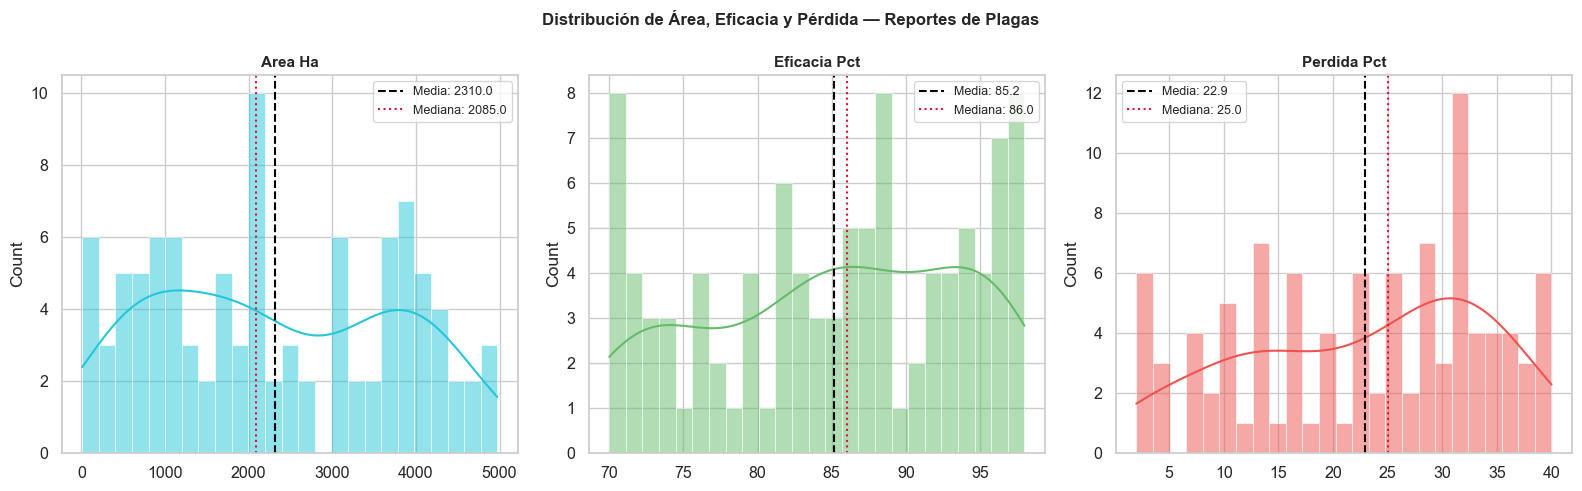

✅ Guardado: 1d_hist_plagas_num.png


In [18]:
cols_pla = ["area_ha", "eficacia_pct", "perdida_pct"]
colores   = ["#26c6da","#66bb6a","#ef5350"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, cols_pla, colores):
    data = df_pla[col].dropna()
    sns.histplot(data, ax=ax, kde=True, bins=25,
                 color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(data.mean(),   color="black",    linestyle="--",
               linewidth=1.5, label=f"Media: {data.mean():.1f}")
    ax.axvline(data.median(), color="crimson",  linestyle=":",
               linewidth=1.5, label=f"Mediana: {data.median():.1f}")
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=9)

fig.suptitle("Distribución de Área, Eficacia y Pérdida — Reportes de Plagas",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/1d_hist_plagas_num.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1d_hist_plagas_num.png")

#### Reportes de Plagas 

#### Análisis de Variables Categóricas

- Frecuencia por Severidad: Distribución casi equitativa entre niveles baja, media y alta. Existe una ausencia total de registros en la categoría crítica (0 casos).

- Insight ML: Para evitar problemas de clases minoritarias/vacías, se recomienda binarizar la variable objetivo para el Problema 2 (ej. severidad alta = 1, resto = 0).

- Tipo de Agente: Predominio claro de las plagas físicas (74%) sobre las enfermedades (26%).

- Top Agentes: El ranking está fuertemente liderado por el Ácaro (16 reportes), seguido del Pulgón (13) y la Mosca blanca (11). Estos tres agentes explican más del 40% de los incidentes de la muestra.

#### Distribución de Variables Numéricas

- Área afectada (Ha): Presenta una alta dispersión (media de 2310 Ha), abarcando desde brotes muy focalizados hasta afecciones masivas cercanas a las 4000 Ha. Esta variabilidad aportará mucho valor predictivo a los modelos.

- Eficacia del tratamiento (%): Distribución fuertemente asimétrica hacia la derecha (media 85.2%). La gran mayoría de los tratamientos aplicados son exitosos; las eficacias por debajo del 70% son inusuales.

- Pérdida de cosecha (%): A pesar de la alta eficacia de los tratamientos, el daño económico persiste (media 22.9%), con una concentración importante en el rango del 30-35%. Entender qué detona estos picos será vital para el modelo de clasificación de riesgo.

### 1.6. noticias

#### 1.6.1. Análisis Completo de Noticias

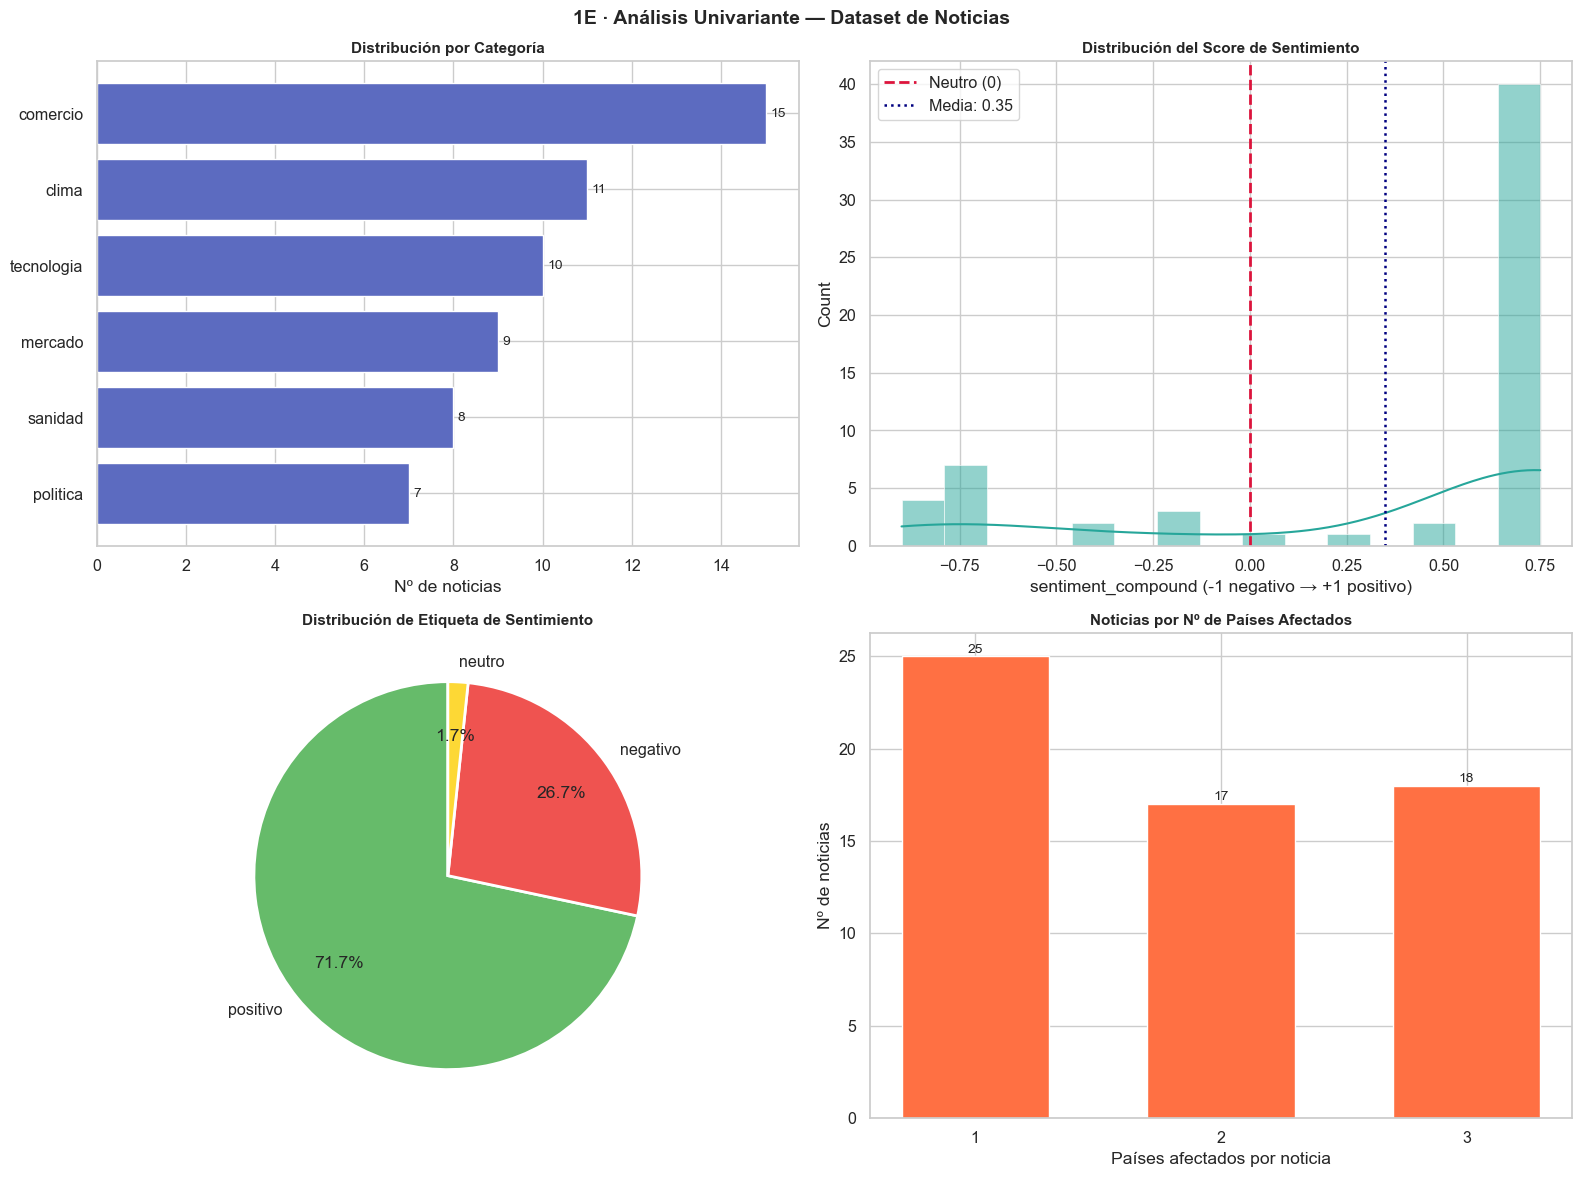

✅ Guardado: 1e_noticias_univariante.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Barplot Categoría ──
cat_count = df_not["categoria"].value_counts().sort_values()
axes[0,0].barh(cat_count.index, cat_count.values,
               color="#5c6bc0", edgecolor="white")
axes[0,0].set_title("Distribución por Categoría", fontsize=11, fontweight="bold")
axes[0,0].set_xlabel("Nº de noticias")
for i, v in enumerate(cat_count.values):
    axes[0,0].text(v + 0.1, i, str(v), va="center", fontsize=10)

# ── Histograma Sentiment Compound ──
sns.histplot(df_not["sentiment_compound"], ax=axes[0,1], bins=15,
             kde=True, color="#26a69a", edgecolor="white", linewidth=0.4)
axes[0,1].axvline(0, color="crimson", linestyle="--", linewidth=2,
                  label="Neutro (0)")
axes[0,1].axvline(df_not["sentiment_compound"].mean(), color="navy",
                  linestyle=":", linewidth=1.8,
                  label=f"Media: {df_not['sentiment_compound'].mean():.2f}")
axes[0,1].set_title("Distribución del Score de Sentimiento",
                     fontsize=11, fontweight="bold")
axes[0,1].set_xlabel("sentiment_compound (-1 negativo → +1 positivo)")
axes[0,1].legend()

# ── Pie Sentiment Label ──
sent_count = df_not["sentiment_label"].value_counts()
colors_sent = {"positivo": "#66bb6a", "negativo": "#ef5350", "neutro": "#fdd835"}
axes[1,0].pie(sent_count.values,
              labels=sent_count.index,
              autopct="%1.1f%%",
              colors=[colors_sent.get(l, "#ccc") for l in sent_count.index],
              wedgeprops=dict(edgecolor="white", linewidth=2),
              startangle=90, pctdistance=0.72)
axes[1,0].set_title("Distribución de Etiqueta de Sentimiento",
                     fontsize=11, fontweight="bold")

# ── Barplot n_paises_afectados ──
npaises = df_not["n_paises_afectados"].value_counts().sort_index()
bars = axes[1,1].bar(npaises.index.astype(str), npaises.values,
                     color="#ff7043", edgecolor="white", width=0.6)
axes[1,1].set_title("Noticias por Nº de Países Afectados",
                     fontsize=11, fontweight="bold")
axes[1,1].set_xlabel("Países afectados por noticia")
axes[1,1].set_ylabel("Nº de noticias")
for b in bars:
    axes[1,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                   f"{int(b.get_height())}", ha="center", fontsize=10)

fig.suptitle("1E · Análisis Univariante — Dataset de Noticias",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/1e_noticias_univariante.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 1e_noticias_univariante.png")

#### 1.6.2. Estadísticos de Sentimiento por Categoría (tabla)

In [20]:
sent_cat = (df_not.groupby("categoria")["sentiment_compound"]
            .agg(["count","mean","median","min","max","std"])
            .round(3)
            .sort_values("mean"))

sent_cat.columns = ["n", "media", "mediana", "min", "max", "std"]
print("── Sentimiento por Categoría de Noticia ──")
print(sent_cat.to_string())
print(f"\nTotal noticias: {len(df_not)}")
print(f"Sesgo positivo global: {round(len(df_not[df_not['sentiment_label']=='positivo'])/len(df_not)*100,1)}%")

── Sentimiento por Categoría de Noticia ──
             n  media  mediana   min   max    std
categoria                                        
clima       11 -0.805    -0.75 -0.90 -0.75  0.076
mercado      9 -0.017    -0.15 -0.45  0.45  0.347
comercio    15  0.750     0.75  0.75  0.75  0.000
politica     7  0.750     0.75  0.75  0.75  0.000
sanidad      8  0.750     0.75  0.75  0.75  0.000
tecnologia  10  0.750     0.75  0.75  0.75  0.000

Total noticias: 60
Sesgo positivo global: 71.7%


#### Insights Bloque 1.6 — Noticicas

#### Análisis completo de noticias
- En un total de 60 noticias lideran las categorías `comercio`, `clima` y `tecnología` totalmente normal en el sector agrícola. Vemos que las noticias pueden incluso incluir varios países dentro de la misma, y por tanto, afectar varios países de una manera u otra diferentemente entre ellos. También podemos observar que en este dataset abundan las noticias positivas sobre las negativas ya que tanto en el gráfico de tarta (71.7% positivas) como en la distribución del score de sentimiento (0.35), 

## 2. Análisis bivariable y multivariable.

### 2.0. Configuración inicial

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

PALETTE_CULTIVOS  = "tab10"
PALETTE_GANADO    = "Set2"
PALETTE_PRODUCTOS = "tab10"
ORDEN_SEV = ["baja", "media", "alta", "critica"]

### 2.1. master_agricola

#### 2.1.1. heatmap correlación

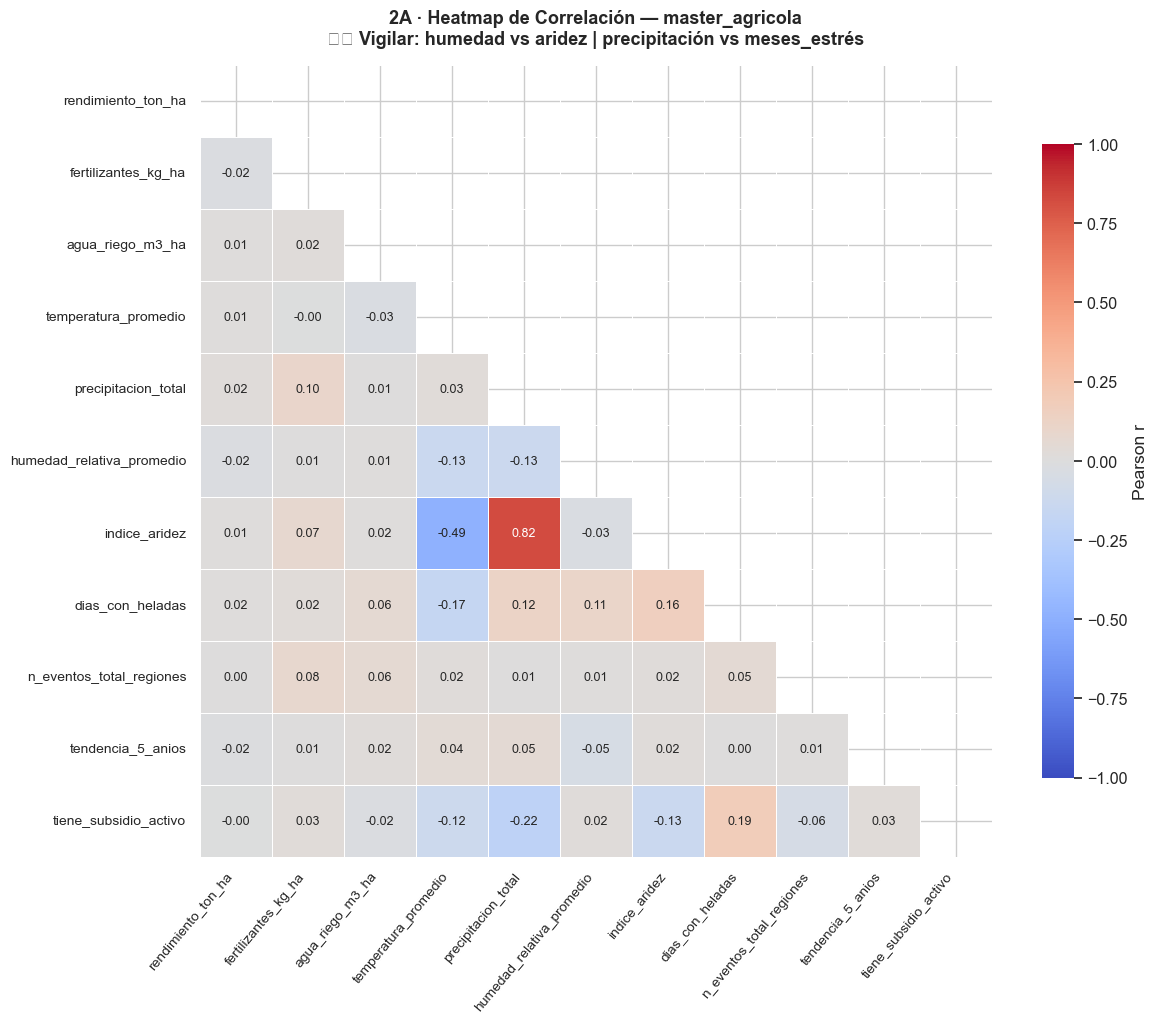


⚠️  Pares con correlación alta (|r| > 0.40):
         var1                 var2        r
indice_aridez  precipitacion_total  0.82199
indice_aridez temperatura_promedio -0.48976

✅ Guardado: 2a_heatmap_correlacion_agr.png


In [ ]:
cols_corr_agr = [
    "rendimiento_ton_ha", "fertilizantes_kg_ha", "agua_riego_m3_ha",
    "temperatura_promedio", "precipitacion_total", "humedad_relativa_promedio",
    "indice_aridez", "dias_con_heladas", "n_eventos_total_regiones",
    "tendencia_5_anios", "tiene_subsidio_activo"
]

corr_agr = df_agr[cols_corr_agr].corr(method="pearson")
mask = np.triu(np.ones_like(corr_agr, dtype=bool))

# ── CAMBIO 1: figura más alta para dar espacio al eje X ──
fig, ax = plt.subplots(figsize=(13, 12))

sns.heatmap(
    corr_agr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax, square=True,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    # ── CAMBIO 2: fuente de anotaciones más pequeña ──
    annot_kws={"size": 9}
)
ax.set_title("Heatmap de Correlación — master_agricola\n"
             "⚠️ Vigilar: humedad vs aridez | precipitación vs meses_estrés",
             fontsize=13, fontweight="bold", pad=15)

# ── CAMBIO 3: rotación 50° + alineación derecha para que no se solapen ──
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=50,
    ha="right",
    fontsize=10
)
ax.tick_params(axis="y", rotation=0, labelsize=10)

# ── CAMBIO 4: margen inferior ampliado para que no se corten las etiquetas ──
plt.subplots_adjust(bottom=0.22)

plt.savefig("../documentacion/figures/2a_heatmap_correlacion_agr.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Imprimir pares con |r| > 0.40
print("\n⚠️  Pares con correlación alta (|r| > 0.40):")
corr_pairs = (corr_agr.where(np.tril(np.ones(corr_agr.shape), k=-1).astype(bool))
              .stack().reset_index())
corr_pairs.columns = ["var1", "var2", "r"]
alta_corr = corr_pairs[abs(corr_pairs["r"]) > 0.40].sort_values("r", ascending=False)
if len(alta_corr):
    print(alta_corr.to_string(index=False))
else:
    print("  → Ningún par supera el umbral de 0.40")
print(f"\n✅ Guardado: 2a_heatmap_correlacion_agr.png")

#### 2.1.2. Scatter Matrix 2×2 (Rendimiento vs Factores)

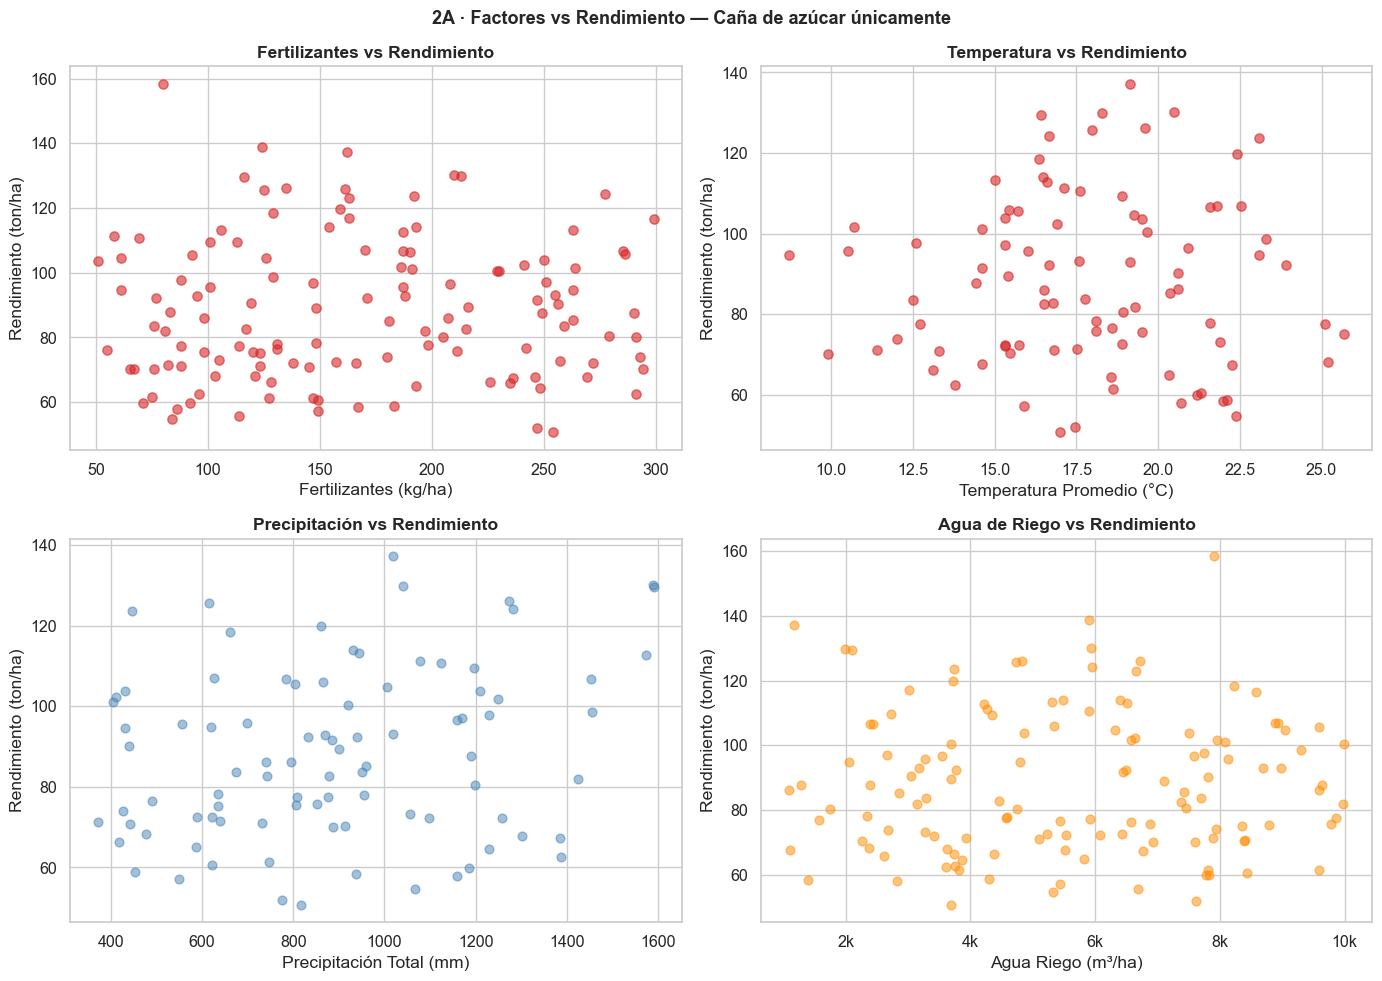

✅ Guardado: 2a_scatter_rendimiento_cana.png


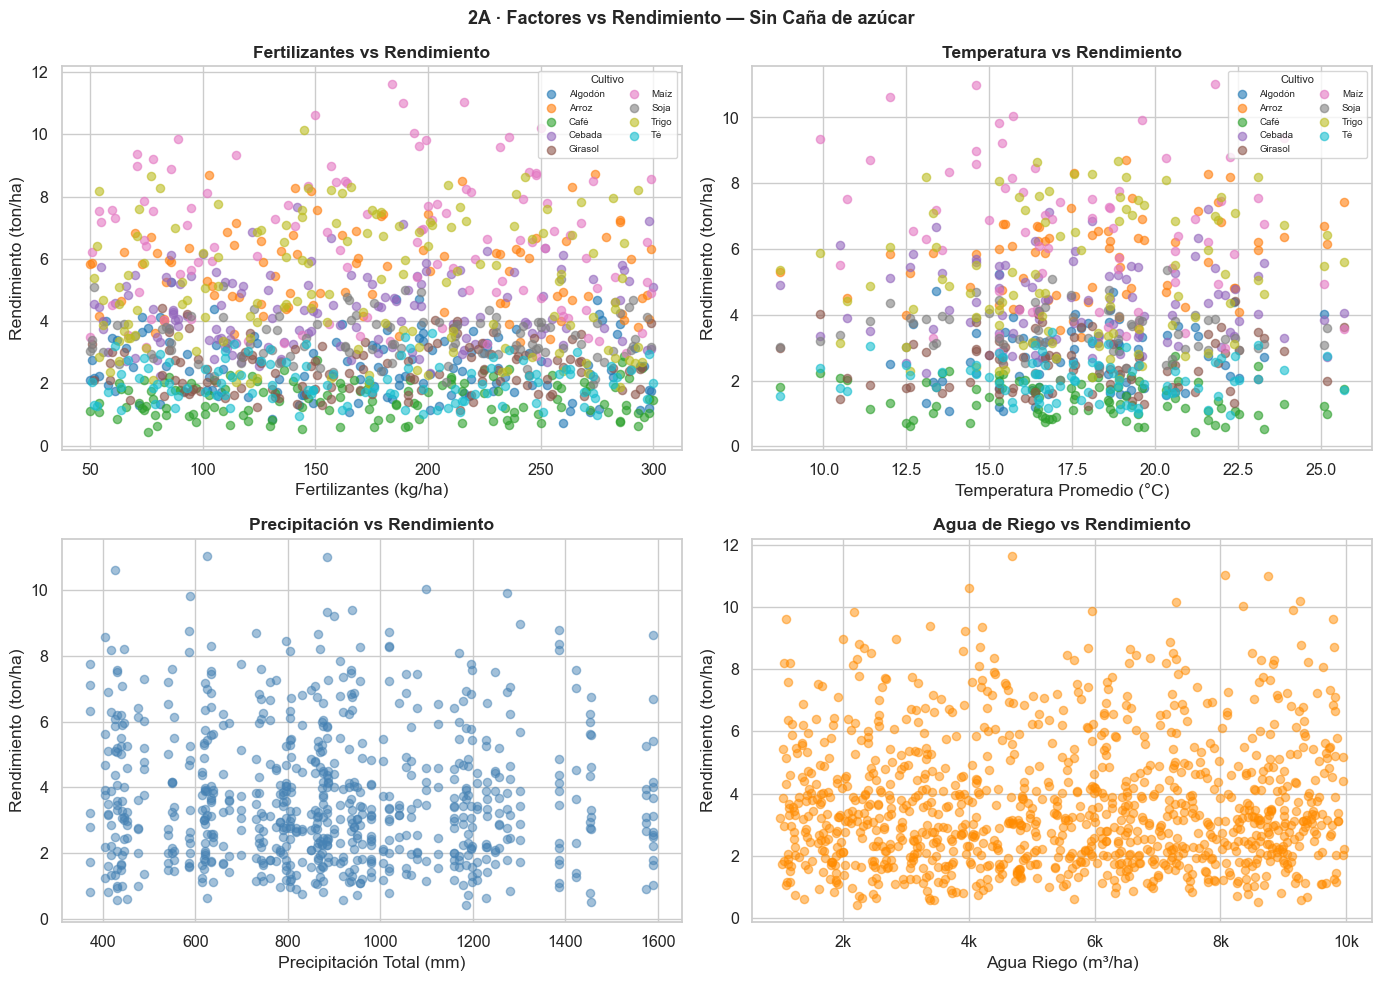

✅ Guardado: 2a_scatter_rendimiento_resto.png


In [ ]:
import matplotlib.ticker as mticker

# ── Subsets ──────────────────────────────────────────────────────────────
df_cana   = df_agr[df_agr["cultivo"] == "Caña de azúcar"].copy()
df_resto  = df_agr[df_agr["cultivo"] != "Caña de azúcar"].copy()
# Para los scatter sin hue (precipitación/agua), mantener dropna
df_r_prec = df_resto.dropna(subset=["precipitacion_total"])

# Paleta idéntica a la del Bloque 1 para coherencia visual
import matplotlib.cm as cm
cultivos_ordenados = sorted(df_agr["cultivo"].unique())
colores = {c: cm.tab10.colors[i] for i, c in enumerate(cultivos_ordenados)}

# ── Helper para formatear eje X ──────────────────────────────────────────
fmt_k = mticker.FuncFormatter(
    lambda x, _: f"{x/1e3:.0f}k" if abs(x) >= 1e3 else f"{x:.0f}"
)

# ════════════════════════════════════════════════════════════════════════
# DASHBOARD 1 — Solo Caña de azúcar
# ════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle("Factores vs Rendimiento — Caña de azúcar únicamente",
              fontsize=13, fontweight="bold")

# [0,0] Fertilizantes
axes1[0,0].scatter(df_cana["fertilizantes_kg_ha"], df_cana["rendimiento_ton_ha"],
                   color=colores["Caña de azúcar"], alpha=0.6, s=45)
axes1[0,0].set_title("Fertilizantes vs Rendimiento", fontweight="bold")
axes1[0,0].set_xlabel("Fertilizantes (kg/ha)")
axes1[0,0].set_ylabel("Rendimiento (ton/ha)")

# [0,1] Temperatura
axes1[0,1].scatter(df_cana["temperatura_promedio"], df_cana["rendimiento_ton_ha"],
                   color=colores["Caña de azúcar"], alpha=0.6, s=45)
axes1[0,1].set_title("Temperatura vs Rendimiento", fontweight="bold")
axes1[0,1].set_xlabel("Temperatura Promedio (°C)")
axes1[0,1].set_ylabel("Rendimiento (ton/ha)")

# [1,0] Precipitación
df_cana_prec = df_cana.dropna(subset=["precipitacion_total"])
axes1[1,0].scatter(df_cana_prec["precipitacion_total"], df_cana_prec["rendimiento_ton_ha"],
                   color="steelblue", alpha=0.5, s=40)
axes1[1,0].set_title("Precipitación vs Rendimiento", fontweight="bold")
axes1[1,0].set_xlabel("Precipitación Total (mm)")
axes1[1,0].set_ylabel("Rendimiento (ton/ha)")

# [1,1] Agua riego
axes1[1,1].scatter(df_cana["agua_riego_m3_ha"], df_cana["rendimiento_ton_ha"],
                   color="darkorange", alpha=0.5, s=40)
axes1[1,1].set_title("Agua de Riego vs Rendimiento", fontweight="bold")
axes1[1,1].set_xlabel("Agua Riego (m³/ha)")
axes1[1,1].set_ylabel("Rendimiento (ton/ha)")
axes1[1,1].xaxis.set_major_formatter(fmt_k)

plt.tight_layout()
plt.savefig("../documentacion/figures/2a_scatter_rendimiento_cana.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 2a_scatter_rendimiento_cana.png")


# ════════════════════════════════════════════════════════════════════════
# DASHBOARD 2 — Resto de cultivos (sin Caña de azúcar)
# ════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle("Factores vs Rendimiento — Sin Caña de azúcar",
              fontsize=13, fontweight="bold")

# [0,0] Fertilizantes — hue por cultivo
for cultivo, grupo in df_resto.groupby("cultivo"):
    axes2[0,0].scatter(grupo["fertilizantes_kg_ha"], grupo["rendimiento_ton_ha"],
                       color=colores[cultivo], label=cultivo, alpha=0.6, s=35)
axes2[0,0].set_title("Fertilizantes vs Rendimiento", fontweight="bold")
axes2[0,0].set_xlabel("Fertilizantes (kg/ha)")
axes2[0,0].set_ylabel("Rendimiento (ton/ha)")
axes2[0,0].legend(title="Cultivo", fontsize=7, title_fontsize=8,
                  loc="upper right", ncol=2)

# [0,1] Temperatura — hue por cultivo
for cultivo, grupo in df_resto.groupby("cultivo"):
    axes2[0,1].scatter(grupo["temperatura_promedio"], grupo["rendimiento_ton_ha"],
                       color=colores[cultivo], label=cultivo, alpha=0.6, s=35)
axes2[0,1].set_title("Temperatura vs Rendimiento", fontweight="bold")
axes2[0,1].set_xlabel("Temperatura Promedio (°C)")
axes2[0,1].set_ylabel("Rendimiento (ton/ha)")
axes2[0,1].legend(title="Cultivo", fontsize=7, title_fontsize=8,
                  loc="upper right", ncol=2)

# [1,0] Precipitación — color sólido
axes2[1,0].scatter(df_r_prec["precipitacion_total"], df_r_prec["rendimiento_ton_ha"],
                   color="steelblue", alpha=0.5, s=35)
axes2[1,0].set_title("Precipitación vs Rendimiento", fontweight="bold")
axes2[1,0].set_xlabel("Precipitación Total (mm)")
axes2[1,0].set_ylabel("Rendimiento (ton/ha)")

# [1,1] Agua riego — color sólido
axes2[1,1].scatter(df_resto["agua_riego_m3_ha"], df_resto["rendimiento_ton_ha"],
                   color="darkorange", alpha=0.5, s=35)
axes2[1,1].set_title("Agua de Riego vs Rendimiento", fontweight="bold")
axes2[1,1].set_xlabel("Agua Riego (m³/ha)")
axes2[1,1].set_ylabel("Rendimiento (ton/ha)")
axes2[1,1].xaxis.set_major_formatter(fmt_k)

plt.tight_layout()
plt.savefig("../documentacion/figures/2a_scatter_rendimiento_resto.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 2a_scatter_rendimiento_resto.png")

#### Insights Bloque 2.1 — master_agricola

#### Heatmap correlaciones
- El heatmap muestra una fuerte correlación positiva (0.82) entre el indice_aridez y la precipitacion_total. Además, observamos una correlación negativa (-0.49) entre el indice_aridez y la temperatura_promedio. Normalmente, un mayor índice de aridez debería asociarse con menor precipitación y mayor temperatura. Sin embargo, aquí vemos lo contrario.

#### Scatters factores vs rendimiento

##### Factores vs Rendimiento — Caña de azúcar únicamente:

- Dispersión Total: Al aislar el cultivo con mayor rendimiento, vemos que la dispersión se mantiene. No hay un patrón claro donde un factor específico (ni fertilizantes, ni lluvia, ni temperatura, ni riego) dispare el rendimiento de la caña de azúcar de 60 a 140 toneladas.

- Conclusión para ML: Predecir el rendimiento con precisión usando solo estos factores será un reto. Es probable que otros factores no incluidos (tipo de suelo, variedad genética de la semilla, etc.) sean los verdaderos responsables de estas variaciones.

##### Factores vs Rendimiento — Sin Caña de azúcar

- El impacto del Cultivo: Los gráficos superiores (Fertilizantes y Temperatura) revelan bandas horizontales de colores, de manera uniforme. Esto confirma que el principal determinante del rendimiento es la naturaleza del cultivo en sí (por ejemplo, el maíz y el arroz siempre rinden más por hectárea que el algodón o el café, independientemente del fertilizante o la temperatura).

- Ausencia de Tendencias Lineales: Si miramos dentro de un mismo color (un mismo cultivo), los puntos están dispersos sin formar líneas diagonales claras. Esto indica que añadir más fertilizante o tener más lluvia no se traduce en un aumento lineal del rendimiento.

- Conclusión para ML: Los modelos de Regresión Lineal básicos del Problema 1 tendrán un desempeño muy pobre si se aplican a todo el dataset junto. La variable categórica cultivo debe ser la división primaria de cualquier modelo, y las variables continuas tendrán un papel secundario o no lineal.  

### 2.2. master_ganadero

#### 2.2.1. Heatmap correlacion

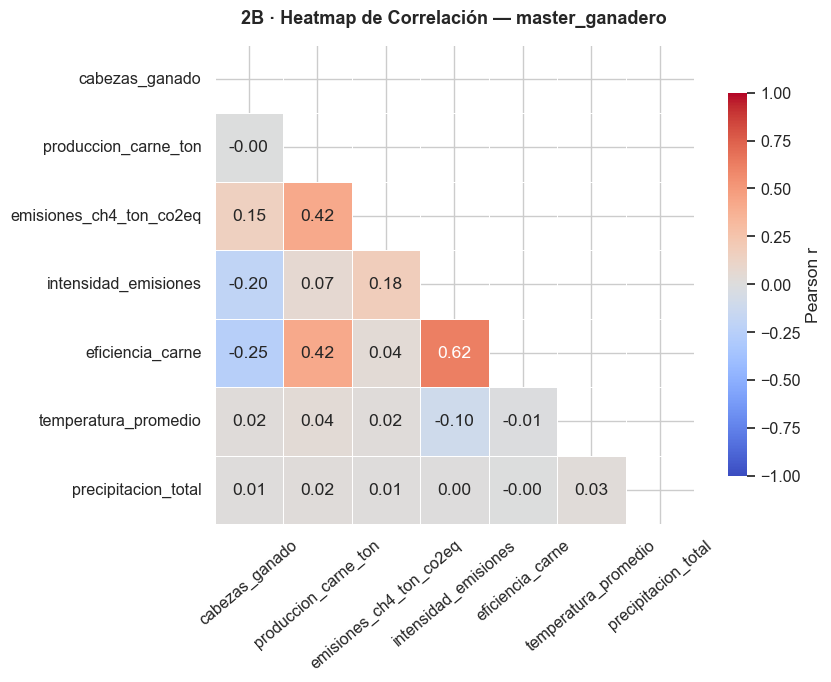


⚠️  Pares con correlación alta (|r| > 0.70):
  → Ningún par supera 0.70

✅ Guardado: 2b_heatmap_correlacion_gan.png


In [24]:
cols_corr_gan = [
    "cabezas_ganado", "produccion_carne_ton", "emisiones_ch4_ton_co2eq",
    "intensidad_emisiones", "eficiencia_carne",
    "temperatura_promedio", "precipitacion_total"
]

corr_gan = df_gan[cols_corr_gan].dropna().corr(method="pearson")
mask_gan = np.triu(np.ones_like(corr_gan, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_gan, mask=mask_gan, annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax, square=True,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
ax.set_title("2B · Heatmap de Correlación — master_ganadero",
             fontsize=13, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=40)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../documentacion/figures/2b_heatmap_correlacion_gan.png", dpi=150, bbox_inches="tight")
plt.show()

# Pares con alta correlación
corr_pairs_gan = (corr_gan.where(np.tril(np.ones(corr_gan.shape), k=-1).astype(bool))
                  .stack().reset_index())
corr_pairs_gan.columns = ["var1", "var2", "r"]
alta_gan = corr_pairs_gan[abs(corr_pairs_gan["r"]) > 0.70].sort_values("r", ascending=False)
print("\n⚠️  Pares con correlación alta (|r| > 0.70):")
print(alta_gan.to_string(index=False) if len(alta_gan) else "  → Ningún par supera 0.70")
print("\n✅ Guardado: 2b_heatmap_correlacion_gan.png")

#### 2.2.2.  Scatter: Eficiencia vs Intensidad por Tipo de Ganado

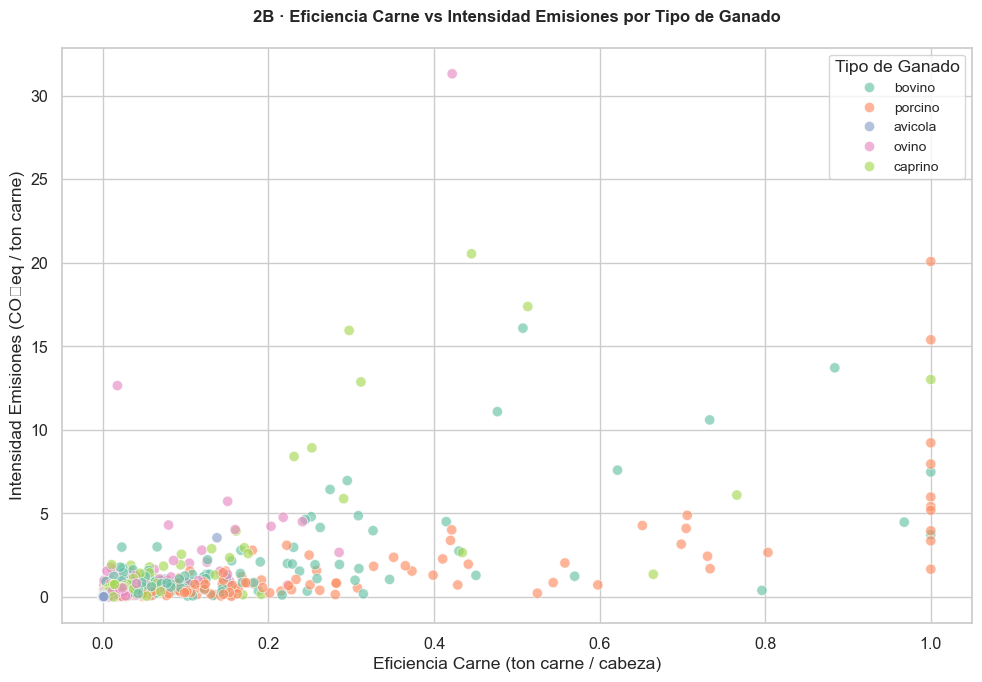

✅ Guardado: 2b_scatter_eficiencia_emisiones.png


In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=df_gan.dropna(subset=["eficiencia_carne","intensidad_emisiones"]),
    x="eficiencia_carne", y="intensidad_emisiones",
    hue="tipo_ganado", palette=PALETTE_GANADO,
    alpha=0.65, s=55, ax=ax
)

ax.set_title("2B · Eficiencia Carne vs Intensidad Emisiones por Tipo de Ganado\n",
            # ¿Bovino: baja eficiencia + alta intensidad? ¿Avícola: lo contrario?,
             fontsize=12, fontweight="bold")
ax.set_xlabel("Eficiencia Carne (ton carne / cabeza)")
ax.set_ylabel("Intensidad Emisiones (CO₂eq / ton carne)")
ax.legend(title="Tipo de Ganado", fontsize=10)

plt.tight_layout()
plt.savefig("../documentacion/figures/2b_scatter_eficiencia_emisiones.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 2b_scatter_eficiencia_emisiones.png")

#### 2.2.3. Boxplots: Intensidad Emisiones por Tipo y País

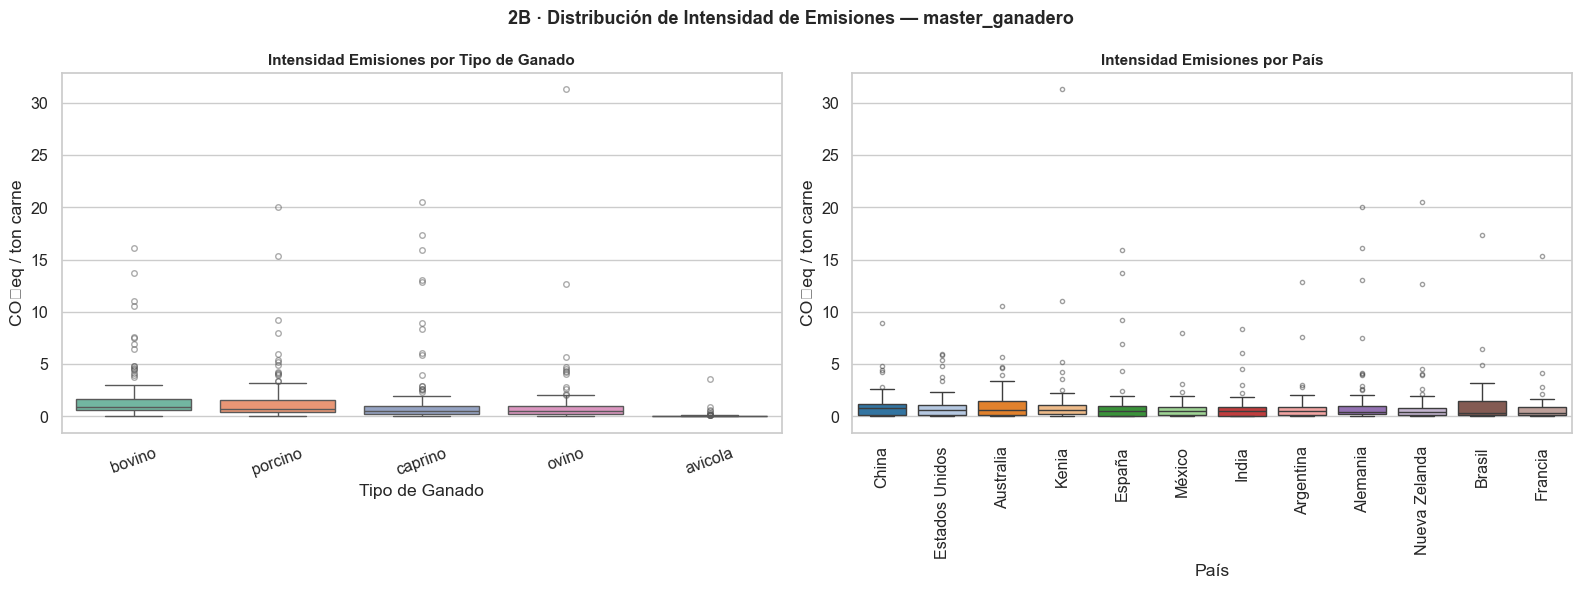

✅ Guardado: 2b_box_emisiones.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: por tipo_ganado
orden_tipo = (df_gan.groupby("tipo_ganado")["intensidad_emisiones"]
              .median().sort_values(ascending=False).index)
sns.boxplot(data=df_gan, x="tipo_ganado", y="intensidad_emisiones",
            order=orden_tipo, palette=PALETTE_GANADO,
            flierprops=dict(marker="o", markersize=4, alpha=0.5),
            ax=axes[0])
axes[0].set_title("Intensidad Emisiones por Tipo de Ganado",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Tipo de Ganado")
axes[0].set_ylabel("CO₂eq / ton carne")
axes[0].tick_params(axis="x", rotation=20)

# Panel derecho: por país
orden_pais = (df_gan.groupby("pais")["intensidad_emisiones"]
              .median().sort_values(ascending=False).index)
sns.boxplot(data=df_gan, x="pais", y="intensidad_emisiones",
            order=orden_pais, palette="tab20",
            flierprops=dict(marker="o", markersize=3, alpha=0.5),
            ax=axes[1])
axes[1].set_title("Intensidad Emisiones por País",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("País")
axes[1].set_ylabel("CO₂eq / ton carne")
axes[1].tick_params(axis="x", rotation=90)

fig.suptitle("2B · Distribución de Intensidad de Emisiones — master_ganadero",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/2b_box_emisiones.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 2b_box_emisiones.png")

#### Insights Bloque 2.2 — Correlaciones y Factores Ganaderos
##### Relaciones de Eficiencia y Emisiones (Heatmap y Scatter)
- Paradoja Productiva: Se observa una correlación positiva fuerte (0.42) entre la producción total de carne y las emisiones totales de $CO_{2}eq$. Sin embargo, la correlación entre eficiencia_carne (toneladas por cabeza) e intensidad_emisiones ($CO_{2}eq$ por tonelada producida) también es alta (0.62). Esto sugiere que, a medida que los animales ganan más peso o se aprovecha mejor su canal, su huella de carbono proporcional tiende a dispararse, concentrándose en valores atípicos severos.

- El impacto de la Escala: Existe una correlación inversa (-0.25) entre cabezas_ganado y eficiencia_carne, lo que es totalmente coherente con la realidad biológica: los animales que se crían en rebaños masivos suelen ser más pequeños (ej. aves) que aquellos criados en menor número pero con mayor peso individual (ej. bovinos).
##### Perfiles por Tipo de Ganado (Boxplots y Scatter)
- Aves vs. Rumiantes: El scatter plot y los boxplots confirman que la avicultura es, con diferencia, el sector más sostenible. Las aves presentan una intensidad de emisiones residual (media de ~0.08 $CO_{2}eq$/ton) y una baja eficiencia por cabeza, lo cual es lógico dado su bajo peso corporal, pero compensan con ciclos de crecimiento rápidos y una excelente conversión alimenticia.

- El peso de los Outliers: Al observar la distribución de la intensidad_emisiones por tipo de ganado, las medianas de rumiantes (bovinos, ovinos, caprinos) y cerdos rondan niveles similares (entre 1 y 2 $CO_{2}eq$/ton). No obstante, los bovinos, porcinos y caprinos dominan absolutamente la presencia de outliers extremos (valores que superan los 5 e incluso llegan a los 30 $CO_{2}eq$/ton). Estos picos de contaminación son los que disparan la huella de carbono de estas especies.  
##### Distribución Geográfica (Boxplots por País)
- Homogeneidad Artificial: Al analizar la intensidad_emisiones por país, las medianas son sorprendentemente similares a nivel global. Salvo un ligero aumento en la dispersión de los datos en Brasil o Australia (y algunos outliers en Estados Unidos o Francia), no se aprecia un país que sea inherentemente "sucio" o "limpio" en su producción.

- Implicación para ML: Esta falta de un patrón geográfico claro para las emisiones sugiere que las diferencias productivas reales (tecnología, regulaciones locales, dietas del ganado) no están siendo capturadas en este dataset. Modelos de segmentación (K-Means o DBSCAN, Problema 3) tendrán dificultades para agrupar países basándose solo en su desempeño ambiental, y dependerán más de la composición de su cabaña ganadera.

### 2.3. precios_mercado

#### 2.3.1.  Heatmap de Correlación de Precios

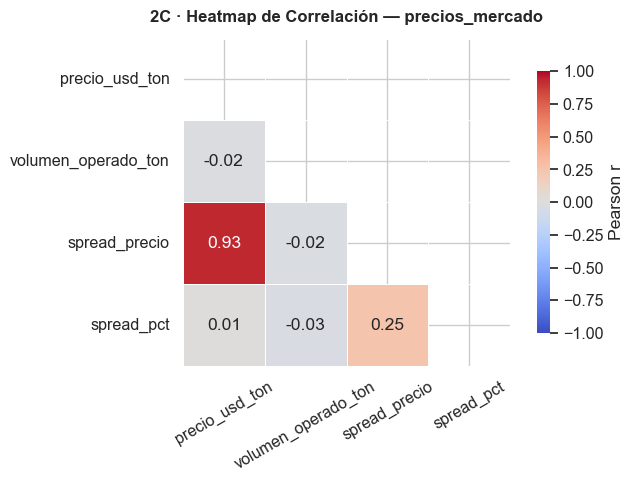

✅ Guardado: 2c_heatmap_correlacion_pre.png


In [27]:
cols_corr_pre = ["precio_usd_ton", "volumen_operado_ton", "spread_precio", "spread_pct"]

corr_pre = df_pre[cols_corr_pre].corr(method="pearson")
mask_pre = np.triu(np.ones_like(corr_pre, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_pre, mask=mask_pre, annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax, square=True,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
ax.set_title("2C · Heatmap de Correlación — precios_mercado",
             fontsize=12, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../documentacion/figures/2c_heatmap_correlacion_pre.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 2c_heatmap_correlacion_pre.png")

#### 2.3.2. Scatter: Volumen vs Precio por Producto

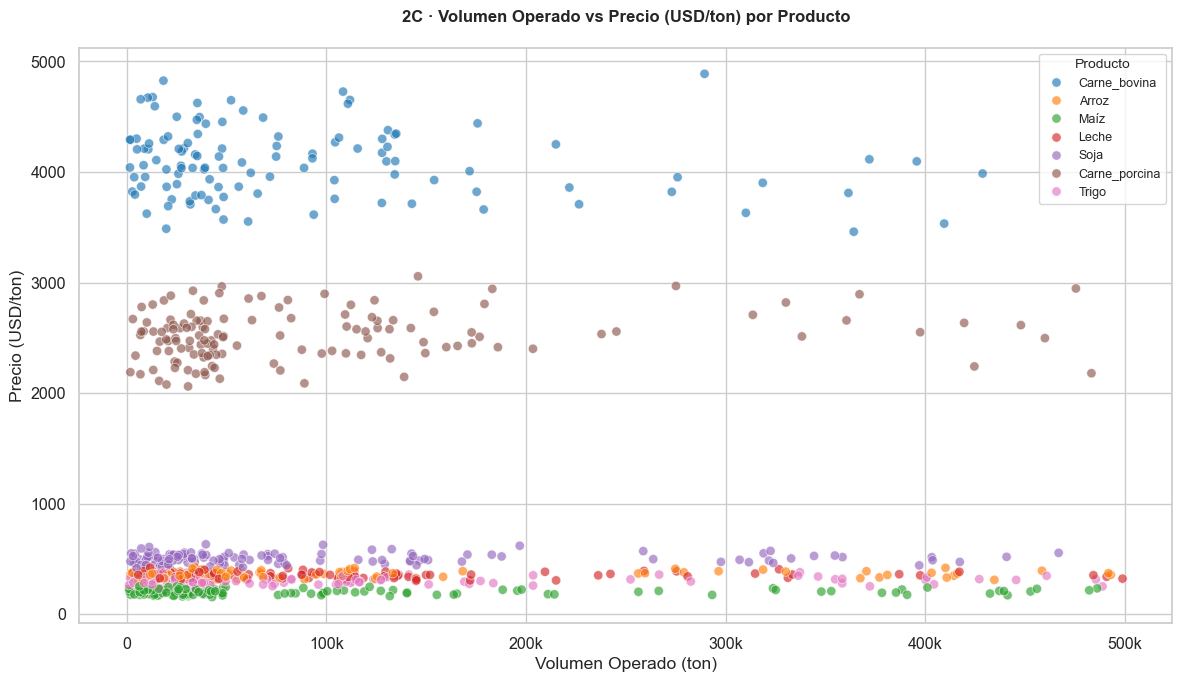

✅ Guardado: 2c_scatter_volumen_precio.png


In [28]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df_pre, x="volumen_operado_ton", y="precio_usd_ton",
    hue="producto", palette=PALETTE_PRODUCTOS,
    alpha=0.65, s=45, ax=ax
)

ax.set_title("2C · Volumen Operado vs Precio (USD/ton) por Producto\n",
             #"¿A mayor oferta, menor precio?",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Volumen Operado (ton)")
ax.set_ylabel("Precio (USD/ton)")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if abs(x) >= 1e6
                           else f"{x/1e3:.0f}k" if abs(x) >= 1e3
                           else f"{x:.0f}")
)
ax.legend(title="Producto", fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.savefig("../documentacion/figures/2c_scatter_volumen_precio.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 2c_scatter_volumen_precio.png")

#### Insights Bloque 2.3 — Precios de Mercado
##### Correlaciones Financieras (Heatmap)
- La ilusión del volumen: El mapa de calor muestra una correlación de casi cero (-0.02) entre el volumen_operado_ton y el precio_usd_ton. En este conjunto de datos, una mayor oferta o demanda (volumen) no se traduce en un cambio predecible en el precio base.

- Métricas de volatilidad: La altísima correlación (0.93) entre spread_precio (la diferencia absoluta entre máximo y mínimo mensual) y el precio_usd_ton es un artefacto esperado: los productos más caros tienen rangos absolutos más amplios. Sin embargo, el spread_pct (la variación porcentual) tiene una correlación mucho más limpia y baja (0.25).

- NOTA para ML (Problema 4): Para predecir la tendencia del mercado, el modelo debe alimentarse con el spread_pct como indicador de volatilidad, ya que el spread absoluto introduciría sesgo hacia los productos más caros.

##### Agrupaciones Naturales (Scatter Plot Volumen vs Precio)
- Segmentación por producto: El gráfico de dispersión revela clústeres horizontales perfectos. Cada producto opera en su propia "banda de precio" independientemente del volumen tranzado. La Carne bovina domina la parte alta (>3500 USD), seguida de la Carne porcina, mientras que los cultivos masivos (Trigo, Soja, Maíz, Leche) se comprimen en la parte inferior (<1000 USD).

- Implicación: La variable categórica producto es el factor de mayor peso para determinar el rango de precios.

### 2.4. reportes_plaga

### 2.4.1. Boxplots: Pérdida por Severidad y Eficacia por Tratamiento

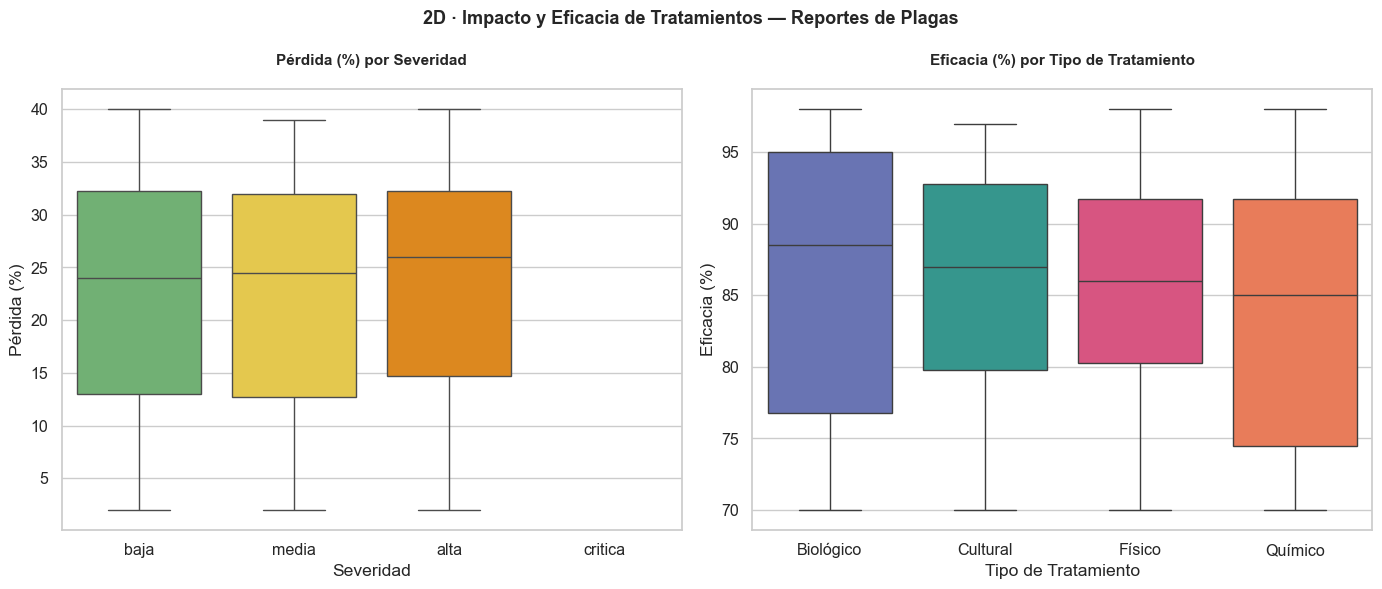

✅ Guardado: 2d_box_plagas_impacto.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: perdida_pct por severidad (orden forzado)
sns.boxplot(data=df_pla, x="severidad", y="perdida_pct",
            order=ORDEN_SEV,
            palette=["#66bb6a","#fdd835","#fb8c00","#e53935"],
            flierprops=dict(marker="o", markersize=5, alpha=0.6),
            ax=axes[0])
axes[0].set_title("Pérdida (%) por Severidad\n",
                 # "¿La severidad crítica implica mayor pérdida?",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Severidad")
axes[0].set_ylabel("Pérdida (%)")

# Panel derecho: eficacia_pct por tipo_tratamiento
orden_trat = (df_pla.groupby("tipo_tratamiento")["eficacia_pct"]
              .median().sort_values(ascending=False).index)
sns.boxplot(data=df_pla, x="tipo_tratamiento", y="eficacia_pct",
            order=orden_trat,
            palette=["#5c6bc0","#26a69a","#ec407a","#ff7043"],
            flierprops=dict(marker="o", markersize=5, alpha=0.6),
            ax=axes[1])
axes[1].set_title("Eficacia (%) por Tipo de Tratamiento\n",
                  # "¿Químico más efectivo que Biológico?",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Tipo de Tratamiento")
axes[1].set_ylabel("Eficacia (%)")

fig.suptitle("2D · Impacto y Eficacia de Tratamientos — Reportes de Plagas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/2d_box_plagas_impacto.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 2d_box_plagas_impacto.png")

#### 2.4.2. Pivot Heatmap: País × Cultivo (Frecuencia de Brotes)

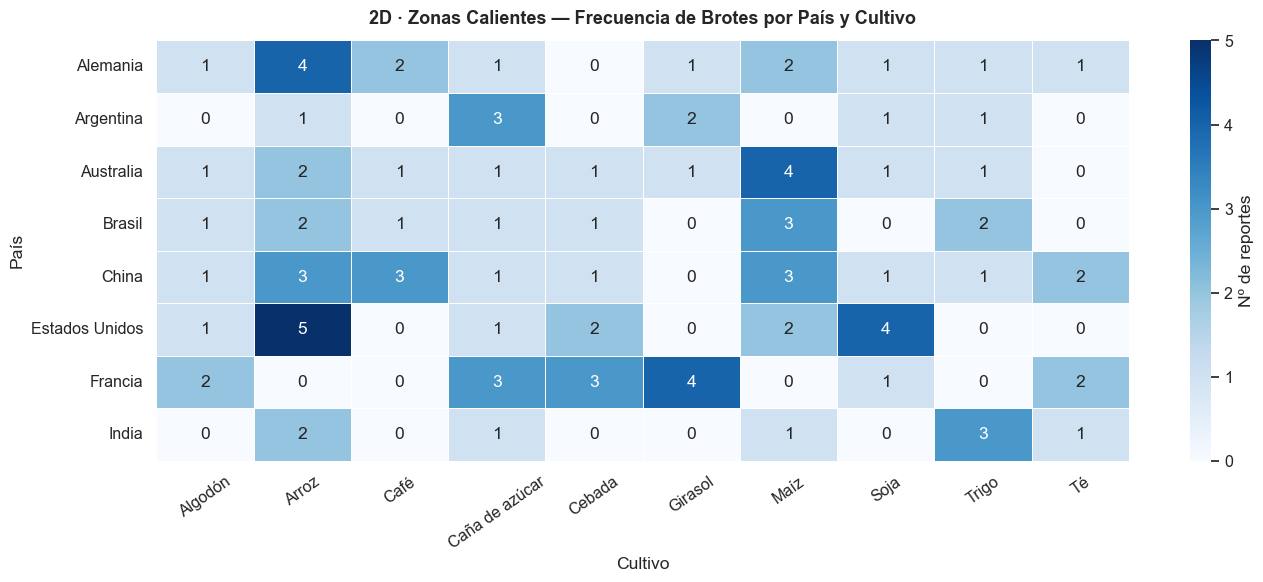

✅ Guardado: 2d_heatmap_pais_cultivo.png


In [30]:
# Tabla pivote: frecuencia de reportes por país × cultivo
pivot_pla = (df_pla.groupby(["pais", "cultivo"])
             .size()
             .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_pla, annot=True, fmt="d",
    cmap="Blues", linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Nº de reportes"}
)
ax.set_title("2D · Zonas Calientes — Frecuencia de Brotes por País y Cultivo",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Cultivo")
ax.set_ylabel("País")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../documentacion/figures/2d_heatmap_pais_cultivo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 2d_heatmap_pais_cultivo.png")

#### 2.4.3. Print: Combinaciones más frecuentes de brotes

In [31]:
top_brotes = (df_pla.groupby(["pais", "cultivo", "agente"])
              .size()
              .reset_index(name="n")
              .sort_values("n", ascending=False)
              .head(15))

print("── Top 15 combinaciones País × Cultivo × Agente ──")
print(top_brotes.to_string(index=False))

print("\n── Resumen: países con más brotes totales ──")
print(df_pla["pais"].value_counts().to_string())

print("\n── Resumen: cultivos con más brotes totales ──")
print(df_pla["cultivo"].value_counts().to_string())

── Top 15 combinaciones País × Cultivo × Agente ──
     pais cultivo          agente  n
Australia    Maíz           Ácaro  2
  Francia  Cebada           Ácaro  2
    India   Trigo           Ácaro  2
    China      Té  Chinche marrón  2
 Alemania   Arroz           Ácaro  1
 Alemania Algodón        Fusarium  1
 Alemania   Arroz    Mosca blanca  1
 Alemania   Arroz  Chinche marrón  1
 Alemania Girasol    Mosca blanca  1
 Alemania    Maíz    Mosca blanca  1
 Alemania    Maíz          Pulgón  1
 Alemania    Soja     Podredumbre  1
 Alemania   Trigo    Mosca blanca  1
 Alemania    Café           Oídio  1
 Alemania    Café Roya de la hoja  1

── Resumen: países con más brotes totales ──
pais
China             16
Francia           15
Estados Unidos    15
Alemania          14
Australia         13
Brasil            11
Argentina          8
India              8

── Resumen: cultivos con más brotes totales ──
cultivo
Arroz             19
Maíz              15
Caña de azúcar    12
Soja               

#### Insights Bloque 2.4 — Reportes de Plagas
##### Impacto y Tratamientos (Boxplots)
- Severidad vs. Pérdida: Aunque la mediana del porcentaje de pérdida (perdida_pct) aumenta ligeramente al pasar de severidad baja a alta (de ~24% a ~26%), la superposición de las cajas es enorme. Esto significa que un brote "bajo" puede causar un 30% de pérdidas y uno "alto" solo un 15%. La clasificación inicial de severidad no es un predictor perfecto del daño económico final. (Recordatorio: la clase critica sigue vacía).

- Eficacia de Tratamientos: Los cuatro tipos de tratamiento (Biológico, Cultural, Físico, Químico) muestran medianas de eficacia muy similares, rondando entre el 85% y el 88%. El tratamiento Físico parece tener la caja más compacta, indicando resultados más consistentes, mientras que el Químico muestra una "cola" larga hacia abajo, sugiriendo que a veces su eficacia cae por debajo del 75%. En general, no hay una "bala de plata" evidente.

##### Zonas Calientes de Riesgo (Heatmap País x Cultivo y Top 15)
- Frecuencia no significa vulnerabilidad: El mapa de calor y el ranking de países/cultivos muestran que el Arroz (19 brotes) y el Maíz (15) son los más atacados, y que China (16) y Estados Unidos (15) lideran la lista geográfica.

- Artefacto Estadístico: Es altamente probable que estas combinaciones (ej. Arroz en Estados Unidos, con 5 reportes) aparezcan con más frecuencia simplemente porque se cultiva más de eso en esos lugares, o porque esos países tienen mejores sistemas de reporte. No significa que el Arroz en EE. UU. sea inherentemente más débil que en la India.

- Estrategia para el Problema 2: Para evitar que el modelo de clasificación de riesgo asuma que "Arroz en EE. UU. = Brote Seguro", sería ideal ponderar estas frecuencias con la superficie cultivada real (superficie_hectareas del dataset agrícola) si se llegaran a cruzar en el futuro. Por ahora, el modelo aprenderá las frecuencias base de la muestra.

## 3. Análisis espacial (mapas)

### 3.0. Descarga del GeoJSON

In [36]:
# Ejecutar solo la primera vez para descargar el shapefile
import urllib.request, os

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
dest = "../data/raw/world_110m.geojson"

if not os.path.exists(dest):
    urllib.request.urlretrieve(url, dest)
    print(f"✅ Descargado en {dest}")
else:
    print("✅ Ya existe, se omite la descarga")

✅ Descargado en ../data/raw/world_110m.geojson


### 3.1. Set-up y datos

GeoPandas es una extensión de pandas que añade soporte nativo para datos geoespaciales. 

En este proyecto lo usamos exclusivamente para pintar los mapas coropléticos del Bloque 3D: cargamos el GeoJSON del mundo, hacemos un merge con nuestros datos (rendimiento, emisiones, plagas) usando el código ISO-3 como clave, y Matplotlib/GeoPandas se encarga de colorear cada país según su valor.

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import pandas as pd
import numpy as np

world = gpd.read_file("../data/raw/world_110m.geojson")
# La columna ISO en este archivo es 'ADM0_A3'
# Verificar: print(world.columns.tolist())

iso3 = {
    "Argentina": "ARG", "Australia": "AUS", "Alemania": "DEU",
    "Brasil": "BRA", "Canadá": "CAN", "China": "CHN",
    "España": "ESP", "Estados Unidos": "USA", "Francia": "FRA",
    "India": "IND", "Italia": "ITA", "Kenia": "KEN",
    "México": "MEX", "Nueva Zelanda": "NZL", "Rusia": "RUS"
}

# Datasets resumidos
rend = df_agr.groupby("pais")["rendimiento_ton_ha"].mean().reset_index()
rend["iso"] = rend["pais"].map(iso3)

emis = df_gan.groupby("pais")["intensidad_emisiones"].mean().reset_index()
emis["iso"] = emis["pais"].map(iso3)

plagas_c = df_pla["pais"].value_counts().reset_index()
plagas_c.columns = ["pais", "n_reportes"]
plagas_c["iso"] = plagas_c["pais"].map(iso3)

### 3.2. Helper coroplético

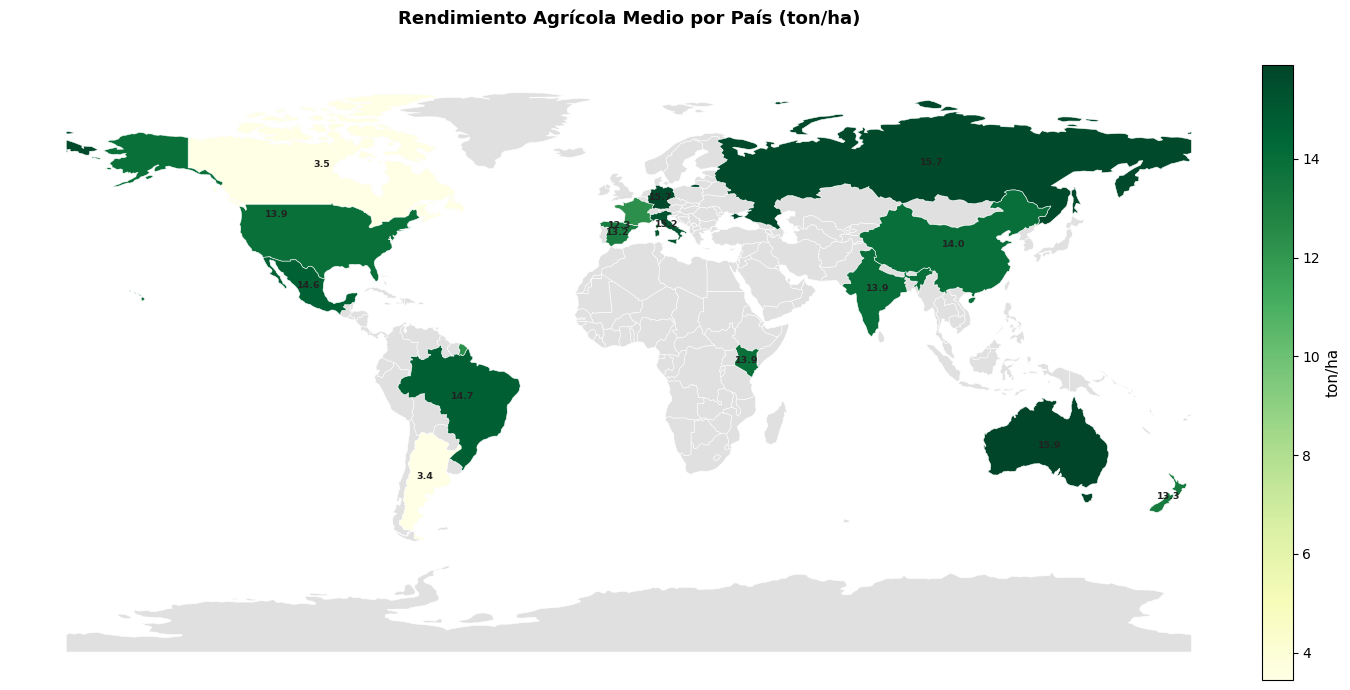

✅ 3d_mapa_rendimiento.png


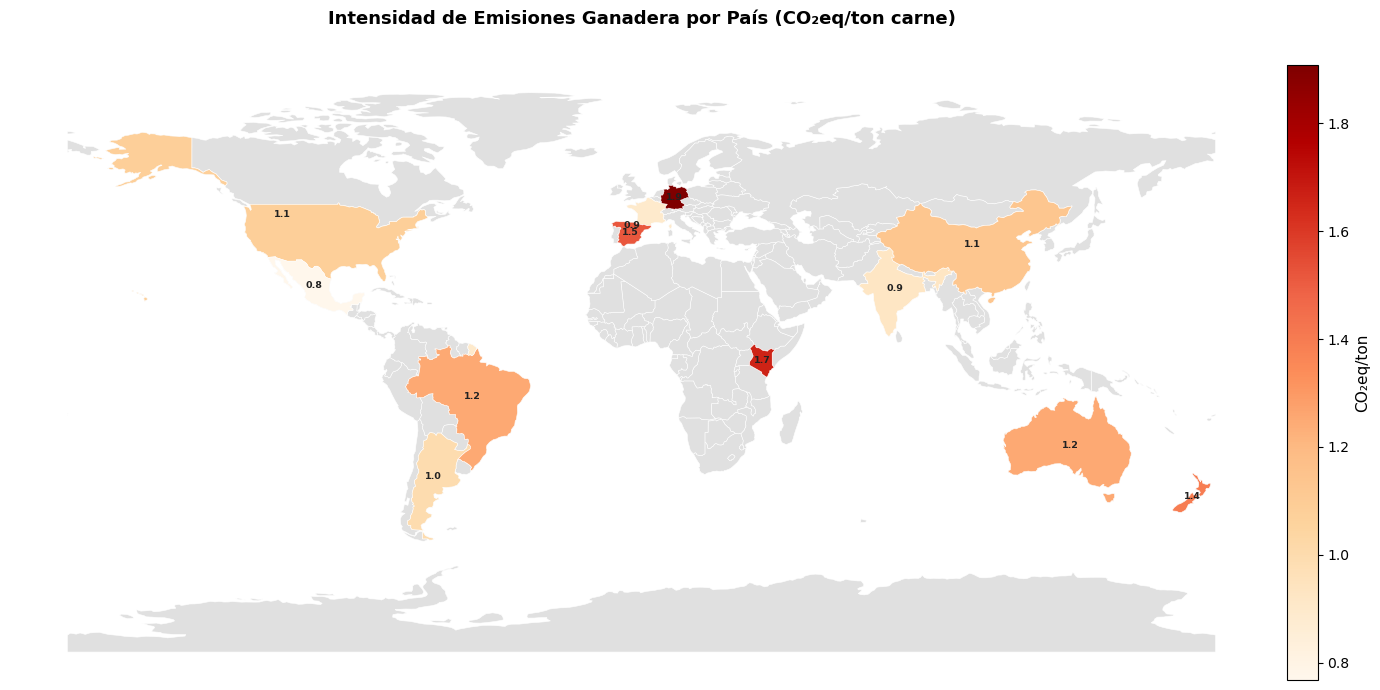

✅ 3d_mapa_emisiones.png


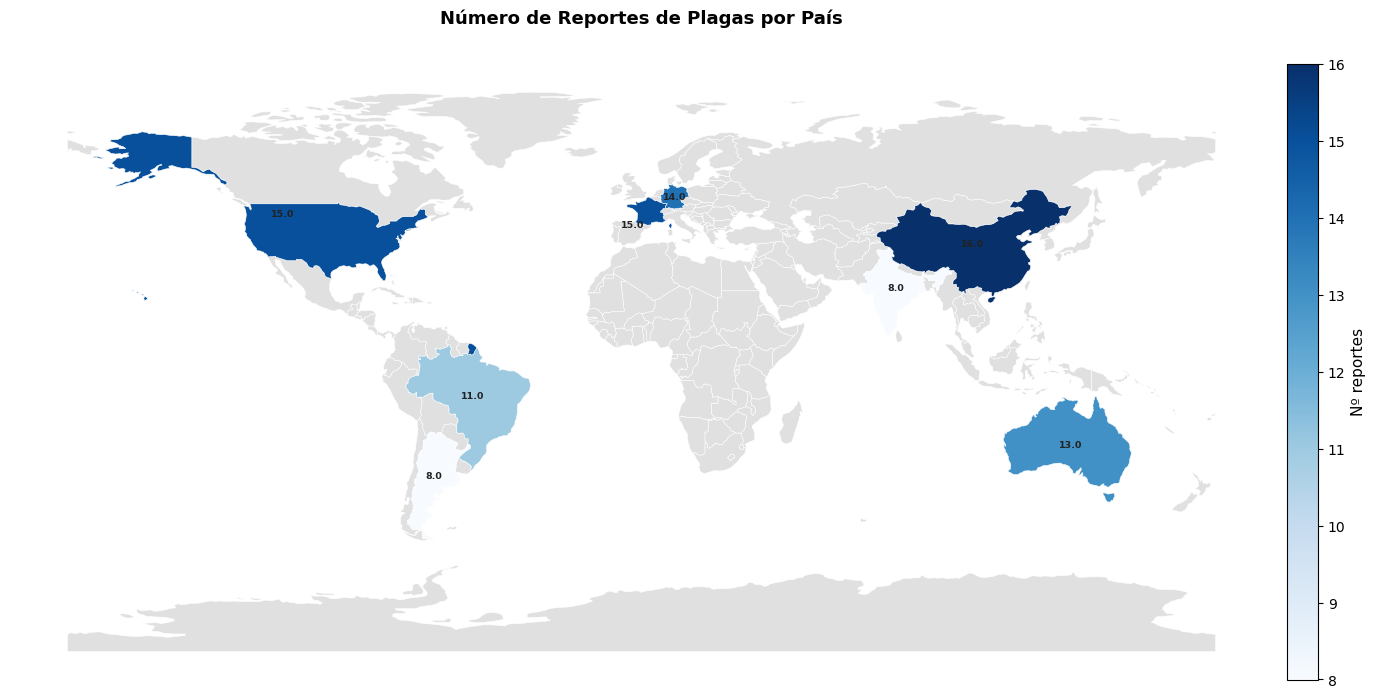

✅ 3d_mapa_plagas.png


In [5]:
def make_choropleth(world, data_df, iso_col, val_col,
                    cmap, title, cbar_label, fname, caption):

    iso_field = "ADM0_A3"  # ajustar si tu GeoJSON usa otra columna
    merged = world.merge(
        data_df[[iso_col, val_col]],
        left_on=iso_field, right_on=iso_col, how="left"
    )

    fig, ax = plt.subplots(figsize=(15, 7))
    # Fondo gris para países sin datos
    world.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=0.4)
    # Países con datos coloreados
    merged[~merged[val_col].isna()].plot(
        ax=ax, column=val_col, cmap=cmap,
        edgecolor="white", linewidth=0.4, legend=False
    )
    # Colorbar
    vmin, vmax = merged[val_col].min(), merged[val_col].max()
    sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.022, pad=0.01)
    cbar.set_label(cbar_label, fontsize=11)

    # Etiquetas de valor sobre cada país
    for _, row in merged[~merged[val_col].isna()].iterrows():
        try:
            cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
            ax.annotate(f"{row[val_col]:.1f}", xy=(cx, cy),
                        ha="center", va="center", fontsize=6.8,
                        fontweight="bold", color="#222")
        except Exception:
            pass

    ax.set_axis_off()
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    plt.tight_layout()
    plt.savefig(f"../documentacion/figures/{fname}",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ {fname}")


# ── Mapa 1: Rendimiento Agrícola ──────────────────────────────────────────
make_choropleth(
    world, rend, "iso", "rendimiento_ton_ha", "YlGn",
    "Rendimiento Agrícola Medio por País (ton/ha)\n",
    # Hipótesis: "Australia y Alemania lideran — Canadá y Argentina presentan valores muy bajos",
    "ton/ha", "3d_mapa_rendimiento.png",
    "Rendimiento agrícola medio por país"
)

# ── Mapa 2: Intensidad de Emisiones Ganadera ──────────────────────────────
make_choropleth(
    world, emis, "iso", "intensidad_emisiones", "OrRd",
    "Intensidad de Emisiones Ganadera por País (CO₂eq/ton carne)\n",
    # Hipotesis: "Alemania y Kenia con mayor huella — México e India con menor intensidad",
    "CO₂eq/ton", "3d_mapa_emisiones.png",
    "Intensidad de emisiones ganadera media por país"
)

# ── Mapa 3: Reportes de Plagas ────────────────────────────────────────────
make_choropleth(
    world, plagas_c, "iso", "n_reportes", "Blues",
    "Número de Reportes de Plagas por País\n",
    # Hipotesis: "China, Francia y EE.UU. concentran el mayor número de brotes",
    "Nº reportes", "3d_mapa_plagas.png",
    "Número total de reportes de plagas por país"
)

### 3.3. Barplot: Precio Histórico por Cultivo y País

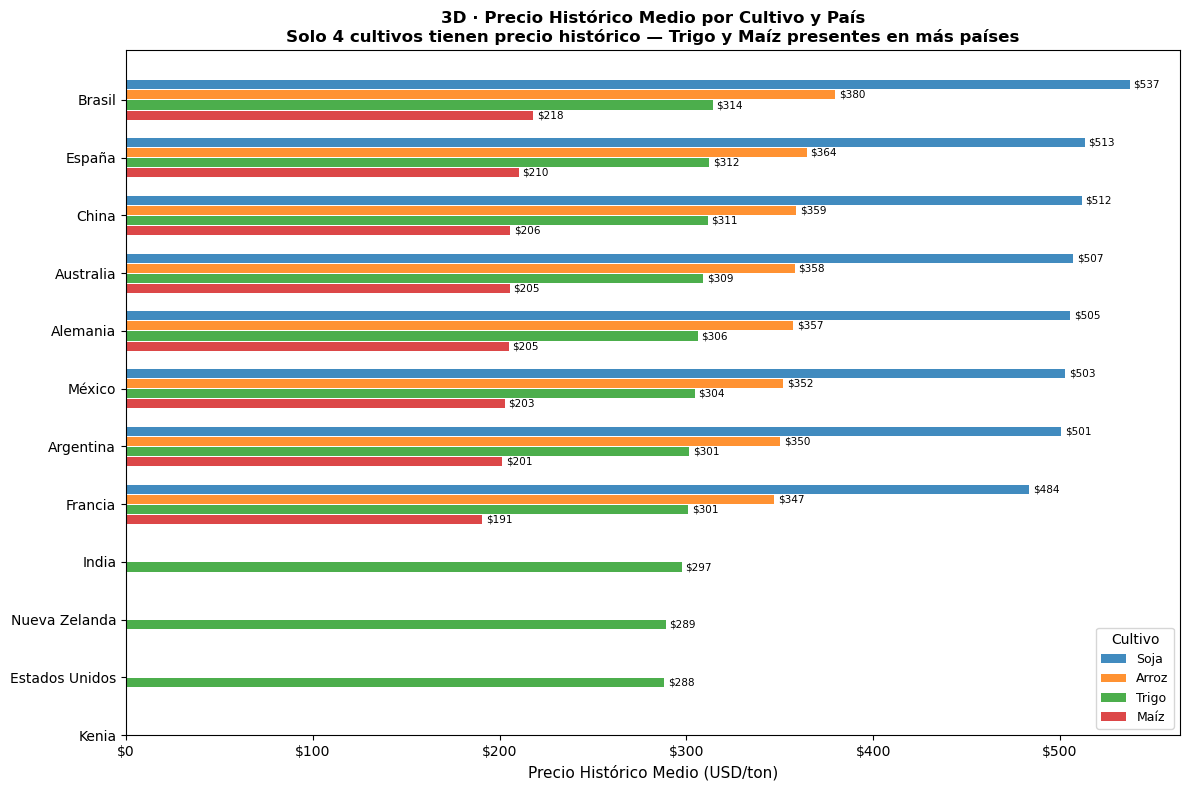

✅ Guardado: 3d_barplot_precios.png


In [ ]:
df_precio = df_agr[["pais", "cultivo", "precio_hist_medio_usd"]].dropna()

# Orden de cultivos por precio medio global descendente
orden_cultivos = (df_precio.groupby("cultivo")["precio_hist_medio_usd"]
                  .mean().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(12, 8))

palette = plt.cm.tab10.colors
cultivos_unicos = orden_cultivos
bar_height = 0.7 / len(cultivos_unicos)

for i, cultivo in enumerate(cultivos_unicos):
    sub = (df_precio[df_precio["cultivo"] == cultivo]
           .groupby("pais")["precio_hist_medio_usd"].mean()
           .sort_values(ascending=False))
    y_pos = np.arange(len(sub)) + i * bar_height
    ax.barh(y_pos, sub.values,
            height=bar_height * 0.9,
            color=palette[i], label=cultivo, alpha=0.85)
    # Etiqueta de valor
    for yp, val in zip(y_pos, sub.values):
        ax.text(val + 2, yp, f"${val:.0f}", va="center", fontsize=7.5)

# Ticks centrados en el grupo de barras por país
paises_orden = (df_precio.groupby("pais")["precio_hist_medio_usd"]
                .mean().sort_values(ascending=False).index.tolist())
mid = (len(cultivos_unicos) - 1) * bar_height / 2
ax.set_yticks([i + mid for i in range(len(paises_orden))])
ax.set_yticklabels(paises_orden, fontsize=10)

ax.set_xlabel("Precio Histórico Medio (USD/ton)", fontsize=11)
ax.set_title("Precio Histórico Medio por Cultivo y País\n"
             "Solo 4 cultivos tienen precio histórico — Trigo presente en más países",
             fontsize=12, fontweight="bold")
ax.legend(title="Cultivo", fontsize=9, title_fontsize=10,
          loc="lower right")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../documentacion/figures/3d_barplot_precios.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: 3d_barplot_precios.png")

Insights Bloque 3 — Análisis Espacial (Mapas)

**1. Rendimiento Agrícola Medio por País**

- Distribución Global: El mapa de "Rendimiento Agrícola Medio por País" muestra una distribución del rendimiento bastante variada a lo largo del globo.

- Líderes en Rendimiento: Destacan países como Australia (15.9 ton/ha), Rusia (15.7 ton/ha), y varios países europeos (Francia, Alemania, Italia) con rendimientos consistentemente altos (por encima de 13 ton/ha). Brasil y Estados Unidos también muestran cifras sólidas.

- Zonas de Menor Rendimiento: Sorprende ver a Canadá (3.5 ton/ha) y Argentina (3.4 ton/ha) con promedios significativamente más bajos en comparación con los líderes. Esto podría deberse a la combinación específica de cultivos que predominan en esos países dentro del dataset (por ejemplo, si producen mayoritariamente cultivos de bajo rendimiento histórico como el algodón o el café en lugar de caña de azúcar).

- Insight para ML: La variable pais aporta una señal geográfica fuerte sobre el rendimiento esperado, lo que será útil para el Problema 1.

**2. Intensidad de Emisiones Ganaderas por País**

- Visión General: El mapa "Intensidad de Emisiones Ganadera por País" ilustra las emisiones de $CO_{2}eq$ por tonelada de carne producida.

- Los Más Emisores (Media): Alemania resalta como el país con la mayor intensidad media de emisiones (1.8 $CO_{2}eq$/ton), seguido por Kenia (1.7) y España (1.5).

- Los Más Eficientes (Media): En contraste, países como México (0.8), India (0.9) y Francia (0.9) presentan las medias más bajas de intensidad de emisiones.

- Contraste con el Análisis Previo: Es importante recordar el análisis del Bloque 2B. Allí vimos que los outliers de emisiones estaban distribuidos de manera uniforme entre los países. Este mapa nos muestra las medias, indicando que aunque todos los países tienen picos extremos de contaminación, el "día a día" productivo sí varía geográficamente. Alemania, a pesar de su tecnología, promedia emisiones más altas en este dataset sintético, quizás por una alta proporción de ganado bovino en su mix total.

- Insight para ML: Esta variación en la intensidad media será un factor discriminante clave para el algoritmo de segmentación en el Problema 3, ayudando a agrupar a los países en clústeres de "alta" y "baja" intensidad relativa.

**3. Frecuencia de Reportes de Plagas**

- Focos de Reporte: El mapa "Número de Reportes de Plagas por País" muestra claramente dónde se originan los datos. China (16.0) y Estados Unidos (15.0) lideran, seguidos por Francia (14.0) y Alemania (15.0).

- Zonas de Menor Reporte: Países como India (8.0) y Argentina (8.0) presentan la menor cantidad de reportes en esta muestra.

- Refuerzo de la Hipótesis: Como comentamos en el bloque anterior, esta distribución geográfica tan desigual en los reportes probablemente refleje la disponibilidad de datos o la escala de la producción, más que una vulnerabilidad biológica intrínseca. El modelo de Problema 2 deberá ser entrenado con precaución para no sesgar las predicciones basándose únicamente en la nacionalidad.

**4. Precio Histórico Medio por Cultivo y País**

- Escasez de Datos Históricos: El gráfico de barras confirma visualmente lo que detectamos en el análisis de nulos (Bloque 0): solo 4 cultivos (Trigo, Maíz, Arroz, Soja) cuentan con datos de precio histórico en el dataset master_agricola.

- Presencia Geográfica: El Trigo es el cultivo con precio histórico en más países analizados.

- Bandas de Precio: Se observan diferencias notables de precio para un mismo cultivo dependiendo del país. Por ejemplo, la Soja promedia más de $500 USD/ton en países como Brasil, España y Australia, mientras que en Francia se sitúa por debajo de los $490 USD/ton. Se puede observar cómo los precios de todos los productos aumentan o disminuyen en conjunto dependiendo del país, nos da el indicativo de que el precio se mueve aparte de por la idiosincrcia del propio producto, dependiendo del país dónde se comercie.

- Insight para ML: Dado que la variable precio histórico tiene un 70.8% de nulos estructurales (porque 6 de los 10 cultivos no tienen este dato), no se debe utilizar para predecir el rendimiento (Problema 1). Su inclusión forzaría a imputar una cantidad inmensa de datos o a descartar a más de la mitad de los cultivos, arruinando el modelo.

## 4. Análisis NLP Sentimiento vs mundo físico

### 4.0. Set-up

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

df_not = pd.read_csv("../data/processed/noticias_processed.csv",        parse_dates=["fecha"])
df_pre = pd.read_csv("../data/processed/precios_mercado_processed.csv", parse_dates=["fecha"])
df_pla = pd.read_csv("../data/processed/reportes_plagas_processed.csv", parse_dates=["fecha"])

# Columna periodo mensual
for df in [df_not, df_pre, df_pla]:
    df["anio_mes"] = df["fecha"].dt.to_period("M")

# Colores fijos de sentimiento
COL_POS = "#43a047"
COL_NEG = "#e53935"
COL_NEU = "#90a4ae"

### 4.1. Sentimiento mensual por categoría

#### 4.1.1.  Barplot: Sentimiento Compound Mensual

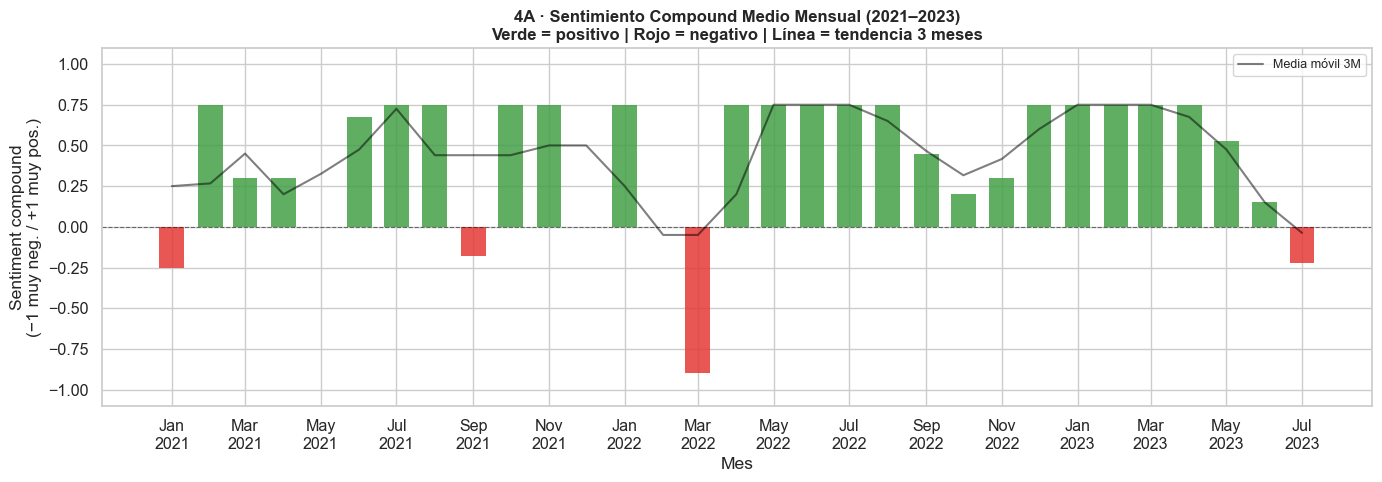

✅ 4a_sentimiento_mensual.png


In [ ]:
import matplotlib.dates as mdates

sent_mensual = (df_not.groupby("anio_mes")["sentiment_compound"]
                .mean().reset_index())
sent_mensual["fecha_dt"] = sent_mensual["anio_mes"].dt.to_timestamp()
sent_mensual["color"] = sent_mensual["sentiment_compound"].apply(
    lambda x: COL_POS if x > 0 else COL_NEG if x < 0 else COL_NEU
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(sent_mensual["fecha_dt"], sent_mensual["sentiment_compound"],
       color=sent_mensual["color"], width=20, alpha=0.85, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# Línea de tendencia suavizada (rolling 3M)
ax.plot(sent_mensual["fecha_dt"],
        sent_mensual["sentiment_compound"].rolling(3, center=True, min_periods=1).mean(),
        color="black", linewidth=1.5, linestyle="-", alpha=0.5, label="Media móvil 3M")

ax.set_title("Sentimiento Compound Medio Mensual (2021–2023)\n"
             "Verde = positivo | Rojo = negativo | Línea = tendencia 3 meses",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Sentiment compound\n(−1 muy neg. / +1 muy pos.)")
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.tight_layout()
plt.savefig("../documentacion/figures/4a_sentimiento_mensual.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ 4a_sentimiento_mensual.png")

#### 4.1.2. Barplot Apilado: Sentimiento por Categoría

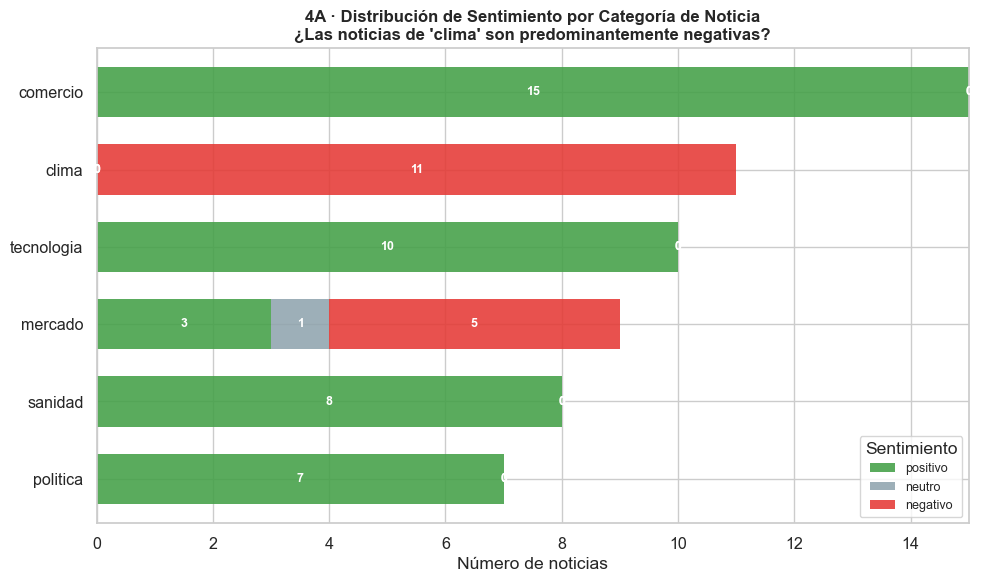

✅ 4a_sentimiento_categoria.png


In [9]:
# Tabla pivot: categoría × label → conteo
cat_sent = (df_not.groupby(["categoria", "sentiment_label"])
            .size().unstack(fill_value=0)
            .reindex(columns=["positivo", "neutro", "negativo"], fill_value=0))

# Ordenar por total de noticias desc
cat_sent["_total"] = cat_sent.sum(axis=1)
cat_sent = cat_sent.sort_values("_total", ascending=True).drop(columns="_total")

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COL_POS, COL_NEU, COL_NEG]
cat_sent.plot(kind="barh", stacked=True, ax=ax,
              color=colors, alpha=0.88, edgecolor="none", width=0.65)

# Etiquetas de valor dentro de las barras
for bars in ax.containers:
    ax.bar_label(bars, label_type="center", fmt="%d",
                 fontsize=9, fontweight="bold", color="white",
                 padding=0)

ax.set_title("4A · Distribución de Sentimiento por Categoría de Noticia\n"
             "¿Las noticias de 'clima' son predominantemente negativas?",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Número de noticias")
ax.set_ylabel("")
ax.legend(title="Sentimiento", loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("../documentacion/figures/4a_sentimiento_categoria.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ 4a_sentimiento_categoria.png")

#### 4.2. Sentimiento vs Precio de Mercado

#### 4.2.1. Doble eje: Sentimiento vs Precio por Producto

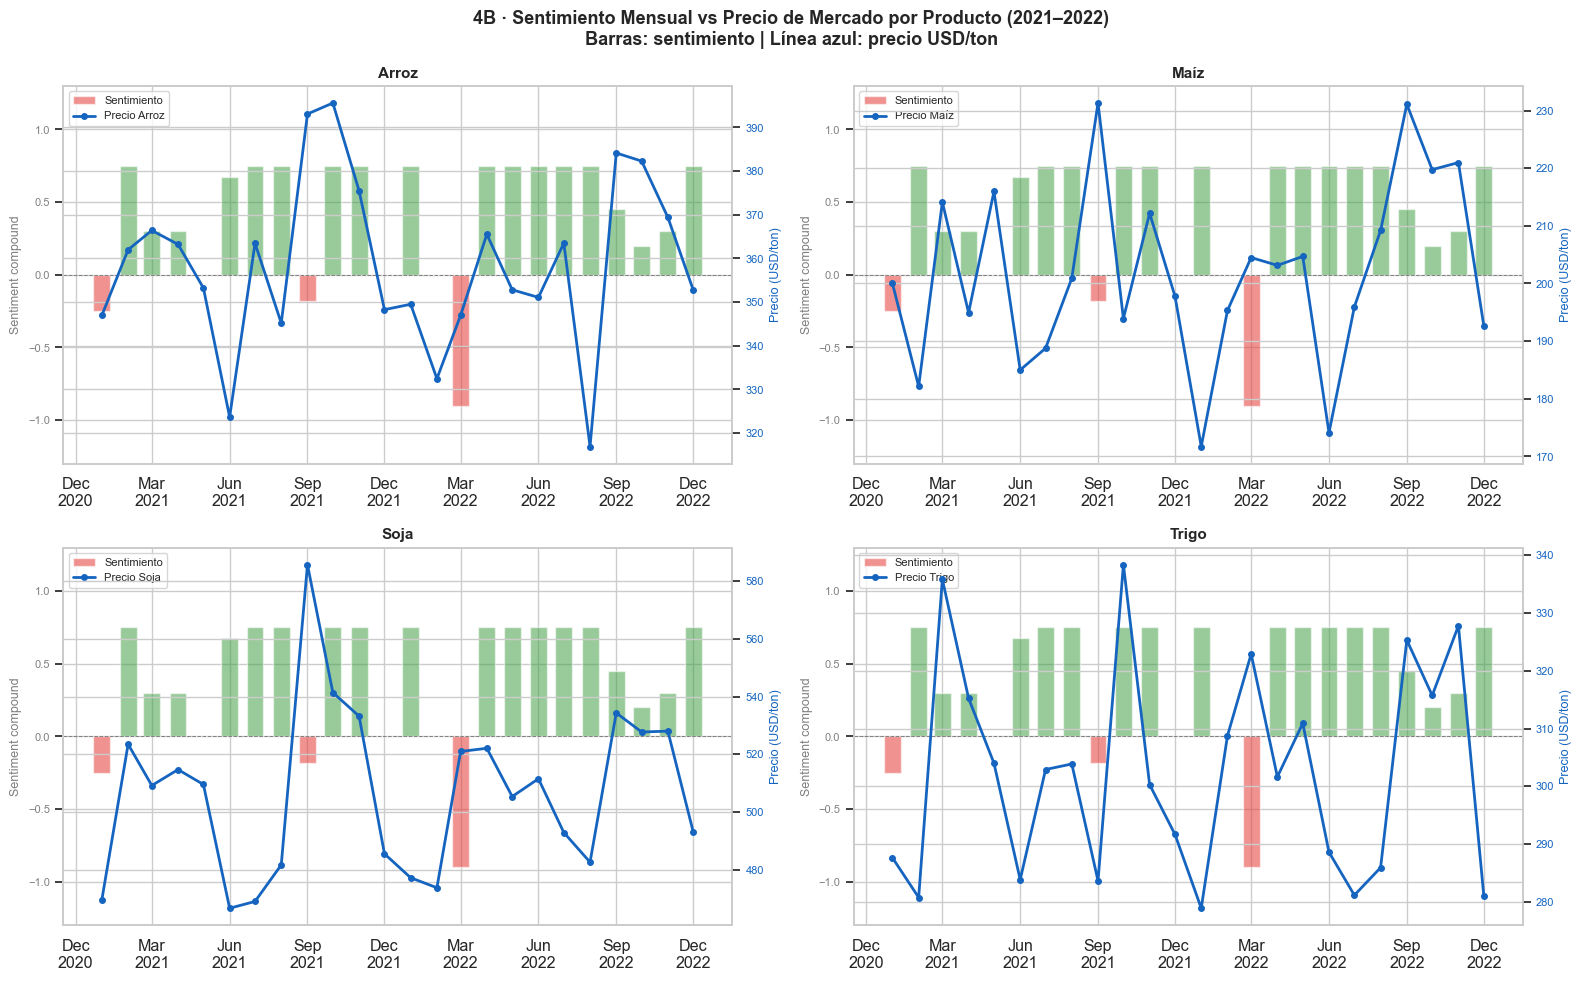

✅ 4b_sent_vs_precio.png


In [10]:
import matplotlib.dates as mdates

# Sentimiento mensual medio global
sent_m = (df_not.groupby("anio_mes")["sentiment_compound"]
          .mean().reset_index())
sent_m["fecha_dt"] = sent_m["anio_mes"].dt.to_timestamp()

# Productos a cruzar (mapeados desde impacto_cultivos_str)
productos_plot = ["Arroz", "Maíz", "Soja", "Trigo"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, producto in enumerate(productos_plot):
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Precio mensual del producto
    precio_m = (df_pre[df_pre["producto"] == producto]
                .groupby("anio_mes")["precio_usd_ton"].mean().reset_index())
    precio_m["fecha_dt"] = precio_m["anio_mes"].dt.to_timestamp()

    # Solo rango de solapamiento (2021–2022)
    s_sub = sent_m[sent_m["anio_mes"] <= "2022-12"]
    p_sub = precio_m[precio_m["anio_mes"] <= "2022-12"]

    # Barras sentimiento (eje izq)
    ax1.bar(s_sub["fecha_dt"], s_sub["sentiment_compound"],
            width=20, color=s_sub["sentiment_compound"].apply(
                lambda x: COL_POS if x > 0 else COL_NEG if x < 0 else COL_NEU),
            alpha=0.55, label="Sentimiento")
    ax1.axhline(0, color="grey", linewidth=0.7, linestyle="--")
    ax1.set_ylabel("Sentiment compound", color="grey", fontsize=9)
    ax1.set_ylim(-1.3, 1.3)
    ax1.tick_params(axis="y", labelcolor="grey", labelsize=8)

    # Línea precio (eje der)
    ax2.plot(p_sub["fecha_dt"], p_sub["precio_usd_ton"],
             color="#1565c0", linewidth=2, marker="o", markersize=4,
             label=f"Precio {producto}")
    ax2.set_ylabel("Precio (USD/ton)", color="#1565c0", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#1565c0", labelsize=8)

    ax1.set_title(f"{producto}", fontweight="bold", fontsize=11)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

    # Leyenda combinada
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

fig.suptitle("4B · Sentimiento Mensual vs Precio de Mercado por Producto (2021–2022)\n"
             "Barras: sentimiento | Línea azul: precio USD/ton",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/4b_sent_vs_precio.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ 4b_sent_vs_precio.png")

#### 4.2.2. Análisis de Lag (0–4 meses)


📊 Correlaciones Sentimiento (t) vs Precio (t+lag):
producto  lag_meses  pearson_r  p_valor significativo
   Arroz          0      0.004    0.985             –
   Arroz          1     -0.075    0.734             –
   Arroz          2      0.092    0.685             –
   Arroz          3      0.271    0.234             –
   Arroz          4     -0.108    0.651             –
    Maíz          0     -0.386    0.063             –
    Maíz          1      0.272    0.210             –
    Maíz          2     -0.040    0.858             –
    Maíz          3      0.456    0.038             ✅
    Maíz          4      0.216    0.361             –
    Soja          0     -0.181    0.398             –
    Soja          1     -0.123    0.575             –
    Soja          2      0.155    0.492             –
    Soja          3      0.187    0.417             –
    Soja          4      0.005    0.983             –
   Trigo          0     -0.237    0.264             –
   Trigo          1     -0.024

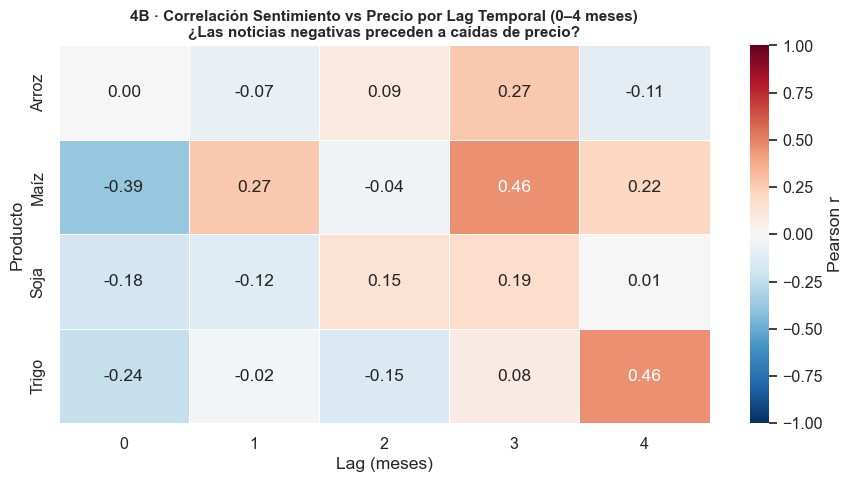

✅ 4b_heatmap_lag.png


In [11]:
from scipy.stats import pearsonr

resultados_lag = []

for producto in productos_plot:
    precio_m = (df_pre[df_pre["producto"] == producto]
                .groupby("anio_mes")["precio_usd_ton"].mean().reset_index())

    merged = sent_m.merge(precio_m, on="anio_mes", how="inner")
    merged = merged.sort_values("anio_mes").reset_index(drop=True)

    for lag in range(0, 5):
        # Sentimiento en t, precio en t+lag
        sent_vals  = merged["sentiment_compound"].iloc[:len(merged) - lag].values
        precio_vals = merged["precio_usd_ton"].iloc[lag:].values
        if len(sent_vals) > 5:
            r, p = pearsonr(sent_vals, precio_vals)
            resultados_lag.append({
                "producto": producto, "lag_meses": lag,
                "pearson_r": round(r, 3), "p_valor": round(p, 3),
                "significativo": "✅" if p < 0.05 else "–"
            })

df_lag = pd.DataFrame(resultados_lag)
print("\n📊 Correlaciones Sentimiento (t) vs Precio (t+lag):")
print(df_lag.to_string(index=False))

# Heatmap de r por producto y lag
pivot_lag = df_lag.pivot(index="producto", columns="lag_meses", values="pearson_r")

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_lag, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("4B · Correlación Sentimiento vs Precio por Lag Temporal (0–4 meses)\n"
             "¿Las noticias negativas preceden a caídas de precio?",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Lag (meses)")
ax.set_ylabel("Producto")

plt.tight_layout()
plt.savefig("../documentacion/figures/4b_heatmap_lag.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ 4b_heatmap_lag.png")

### 4.3. Sentimiento vs Reportes de plagas

#### 4.3.1. Doble eje: Noticias Negativas vs Brotes de Plagas

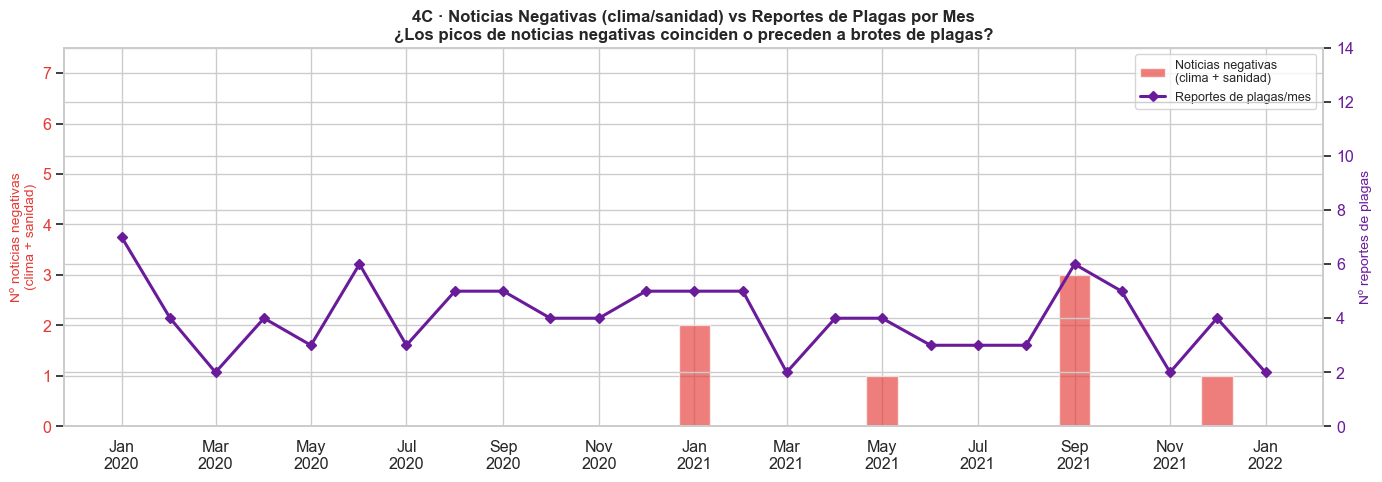

✅ 4c_sent_vs_plagas.png


In [12]:
# Noticias negativas clima/sanidad por mes
not_neg = (df_not[
    (df_not["sentiment_label"] == "negativo") &
    (df_not["categoria"].isin(["clima", "sanidad"]))
].groupby("anio_mes").size().reset_index(name="n_noticias_neg"))
not_neg["fecha_dt"] = not_neg["anio_mes"].dt.to_timestamp()

# Reportes de plagas por mes
pla_m = (df_pla.groupby("anio_mes").size().reset_index(name="n_plagas"))
pla_m["fecha_dt"] = pla_m["anio_mes"].dt.to_timestamp()

# Solapamiento: ambos datasets tienen datos hasta 2022-01
rango_comun = "2022-01"
not_sub = not_neg[not_neg["anio_mes"] <= rango_comun]
pla_sub = pla_m[pla_m["anio_mes"] <= rango_comun]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Barras noticias negativas (eje izq)
ax1.bar(not_sub["fecha_dt"], not_sub["n_noticias_neg"],
        width=20, color=COL_NEG, alpha=0.65, label="Noticias negativas\n(clima + sanidad)")
ax1.set_ylabel("Nº noticias negativas\n(clima + sanidad)", color=COL_NEG, fontsize=10)
ax1.tick_params(axis="y", labelcolor=COL_NEG)
ax1.set_ylim(0, not_sub["n_noticias_neg"].max() * 2.5)

# Línea plagas (eje der)
ax2.plot(pla_sub["fecha_dt"], pla_sub["n_plagas"],
         color="#6a1b9a", linewidth=2.2, marker="D", markersize=5,
         label="Reportes de plagas/mes")
ax2.set_ylabel("Nº reportes de plagas", color="#6a1b9a", fontsize=10)
ax2.tick_params(axis="y", labelcolor="#6a1b9a")
ax2.set_ylim(0, pla_sub["n_plagas"].max() * 2)

ax1.set_title("4C · Noticias Negativas (clima/sanidad) vs Reportes de Plagas por Mes\n"
              "¿Los picos de noticias negativas coinciden o preceden a brotes de plagas?",
              fontsize=12, fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("../documentacion/figures/4c_sent_vs_plagas.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ 4c_sent_vs_plagas.png")

#### 4.3.2. Correlación Sentimiento vs Plagas con Lag

In [13]:
# Merge sentimiento mensual global + plagas
merged_sp = sent_m.merge(pla_m, on="anio_mes", how="inner").sort_values("anio_mes")

print("📊 Correlación Sentimiento vs Plagas con Lag (0–4 meses):")
print(f"{'Lag':>5}  {'Pearson r':>10}  {'p-valor':>9}  {'Sig.':>6}")
print("─" * 38)
for lag in range(0, 5):
    s = merged_sp["sentiment_compound"].iloc[:len(merged_sp)-lag].values
    p = merged_sp["n_plagas"].iloc[lag:].values
    if len(s) > 4:
        r, pv = pearsonr(s, p)
        sig = "✅ p<0.05" if pv < 0.05 else "–"
        print(f"{lag:>5}  {r:>10.3f}  {pv:>9.3f}  {sig:>6}")

📊 Correlación Sentimiento vs Plagas con Lag (0–4 meses):
  Lag   Pearson r    p-valor    Sig.
──────────────────────────────────────
    0      -0.515      0.072       –
    1      -0.248      0.437       –
    2       0.603      0.050  ✅ p<0.05
    3       0.008      0.982       –
    4      -0.100      0.798       –


#### Insights Bloque 4 — NLP: Sentimiento vs Mundo Físico

##### 4.1. Sentimiento mensual por categoría

##### 4.1.1. Distribución de Sentimiento por Categoría

- Visión General: El gráfico de barras horizontales nos muestra la polaridad de las noticias (positivo, negativo, neutro) agrupadas por su temática.

- Clima: La intuición nos dice que las noticias sobre "clima" en agricultura suelen ser sobre desastres (sequías, heladas). El dataset de entimiento lo confirma ya que las 11 noticias sobre ello se categorizan como negativas.

- Noticias Negativas: Curiosamente, las otras  noticias con sentimiento negativo a parte del clima corresponden a la categoría de "mercado" (5 noticias negativas frente a 3 positivas y 1 neutra). Las categorías "comercio", "tecnología", "sanidad" y "política" son exclusivamente positivas.

- Insight Analítico: Este patrón es algo inusual ya que resulta extraño que todas las noticias políticas concretamente sean exclusivamente positivas, pero puede ser que se haya tratado de unos años de legislación favorable en el sector. 

##### 4.1.2. Sentimiento Compound Medio Mensual
- Fluctuaciones: Este gráfico de barras confirma el sesgo positivo: vemos muchos meses verdes (sentimiento positivo) y muy pocos rojos (negativo).

- Tendencia: La línea de media móvil a 3 meses (gris) muestra que el sentimiento general se mantiene positivo la mayor parte del tiempo, con caídas puntuales (ej. principios de 2021, marzo de 2022, y julio de 2023).

##### 4.2. Sentimiento vs Precio de Mercado
- El Gráfico de Líneas (Paneles 2x2): Este gráfico intenta superponer el sentimiento mensual (barras) con el precio promedio mensual (línea azul) para cuatro cultivos clave.

- Observación: A simple vista, parece ser que cuando tenemos fuertes noticias negativas el precio si parece corregir algo a la baja. Sin embargo, en ocasiones, por ejemplo, en el panel del 'Trigo', un mes con fuerte sentimiento negativo (ej. alrededor de Sep 2021) no parece coincidir inmediatamente con una caída del precio; de hecho, el precio parece tener un pico poco después.

- La Correlación con Lag (Heatmap): Aquí es donde la cosa se pone interesante. Este heatmap mide si el sentimiento de hoy afecta el precio hoy (Lag 0), el mes que viene (Lag 1), etc.

- Maíz y Trigo: Notamos correlaciones positivas moderadas en Lag 3 para el Maíz (0.46) y Lag 4 para el Trigo (0.46). Esto sugeriría que un sentimiento positivo hoy se correlaciona con un precio más alto 3 o 4 meses después (o viceversa, un sentimiento negativo precede a un precio bajo).

- Interpretación con Cautela: Aunque matemáticamente hay una correlación,  la muestra de noticias es muy pequeña (solo 60 noticias en total para cruzar con meses enteros de precios). Estas correlaciones (0.46) podrían ser "ruido" estadístico más que una señal causal fuerte.  

##### 4.3. Noticias Negativas vs Reportes de Plagas

- ¿Se anticipan los brotes?: Este gráfico intenta ver si un pico en noticias negativas sobre "clima" o "sanidad" (barras rojas) precede a un aumento en los reportes de plagas (línea morada).

- Conclusión Visual y Tabla de Lag: La línea de plagas fluctúa constantemente. Hay un pico notable de noticias negativas alrededor de septiembre de 2021, que coincide exactamente con un pico en los reportes de plagas (Lag 0).

- Análisis de la Tabla de Lag: La tabla que adjuntaste confirma esto parcialmente. La correlación más fuerte es en el Lag 2 (0.603) con un p-valor de 0.05, lo que la hace estadísticamente significativa. Esto significa que las noticias negativas en un mes dado están fuertemente correlacionadas con un aumento en los reportes de plagas dos meses después.

- Insight para el Problema 2: Las pocas noticias clasificadas como negativas parecen actuar como una alerta temprana efectiva (con 2 meses de antelación) para los brotes de plagas. Integrar esta señal retardada (lag_2) en el modelo de Riesgo de Plagas podría mejorar sustancialmente su capacidad predictiva.


En conclusión: El análisis de sentimiento es una herramienta poderosa, pero en este caso nos muestra las limitaciones de un procesamiento manual básico (sesgo positivo). Sin embargo, el análisis de lag ha desenterrado una relación valiosa: Las noticias negativas actúan como indicadores tempranos de plagas.

## 5. Imágenes satélites

### 5.0. Set-up

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

df_ima = pd.read_csv("../data/processed/imagenes_metadata_processed.csv",
                     parse_dates=["fecha"])

### 5.1. Bandas + Flags de Calidad (figura 1×3)

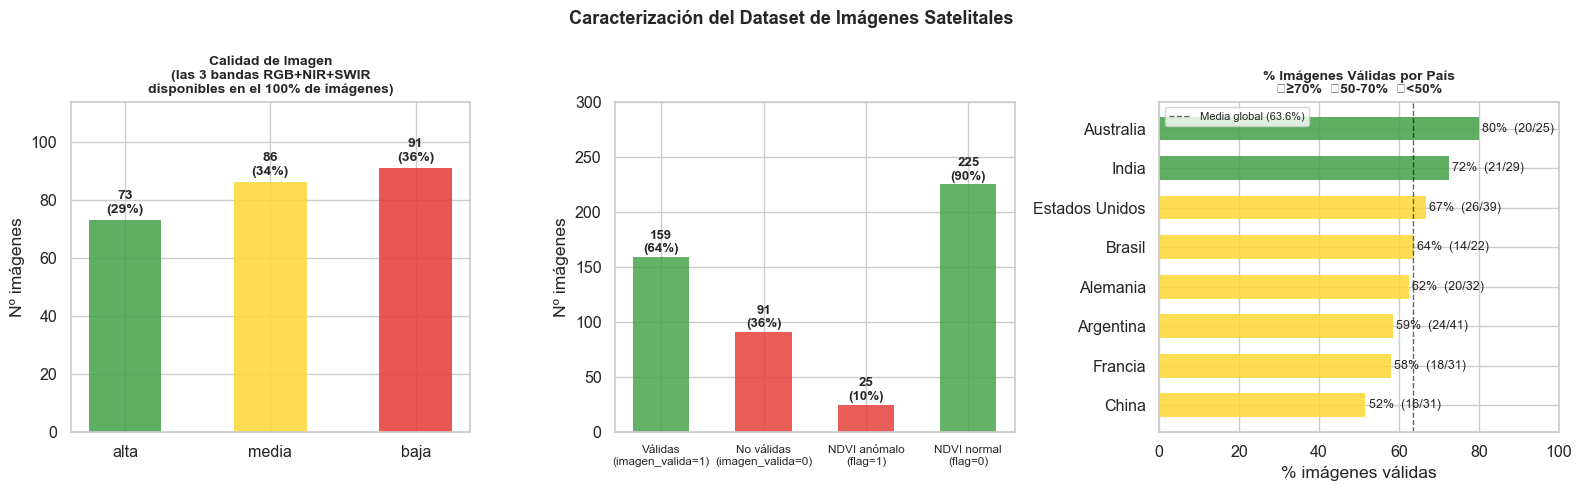

✅ 5_bandas_flags.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Disponibilidad de bandas ────────────────────────────────────
# Todas las imágenes tienen las 3 bandas (100%), pero mostramos
# también calidad_imagen para dar contexto real de uso
cal_counts = df_ima["calidad_imagen"].value_counts().reindex(["alta","media","baja"])
colors_cal = ["#43a047", "#fdd835", "#e53935"]
axes[0].bar(cal_counts.index, cal_counts.values,
            color=colors_cal, alpha=0.85, edgecolor="none", width=0.5)
for i, (cat, val) in enumerate(cal_counts.items()):
    axes[0].text(i, val + 1.5, f"{val}\n({val/len(df_ima)*100:.0f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("Calidad de Imagen\n(las 3 bandas RGB+NIR+SWIR\ndisponibles en el 100% de imágenes)",
                  fontsize=10, fontweight="bold")
axes[0].set_ylabel("Nº imágenes")
axes[0].set_ylim(0, cal_counts.max() * 1.25)

# ── Panel 2: flag_ndvi_anomalo + imagen_valida ───────────────────────────
flags = {
    "Válidas\n(imagen_valida=1)":      df_ima["imagen_valida"].sum(),
    "No válidas\n(imagen_valida=0)":   (df_ima["imagen_valida"] == 0).sum(),
    "NDVI anómalo\n(flag=1)":          df_ima["flag_ndvi_anomalo"].sum(),
    "NDVI normal\n(flag=0)":           (df_ima["flag_ndvi_anomalo"] == 0).sum(),
}
flag_colors = ["#43a047","#e53935","#e53935","#43a047"]
bars = axes[1].bar(list(flags.keys()), list(flags.values()),
                   color=flag_colors, alpha=0.82, edgecolor="none", width=0.55)
for bar, val in zip(bars, flags.values()):
    pct = val / len(df_ima) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                 f"{val}\n({pct:.0f}%)", ha="center", va="bottom",
                 fontsize=9.5, fontweight="bold")
axes[1].set_ylabel("Nº imágenes")
axes[1].set_ylim(0, 250 * 1.2)
axes[1].tick_params(axis="x", labelsize=8.5)

# ── Panel 3: Cobertura válida por país (% imágenes válidas) ──────────────
cob_pais = (df_ima.groupby("pais")["imagen_valida"]
            .agg(["sum","count"])
            .assign(pct=lambda x: x["sum"]/x["count"]*100)
            .sort_values("pct", ascending=True))
color_cob = ["#e53935" if v < 50 else "#fdd835" if v < 70 else "#43a047"
             for v in cob_pais["pct"]]
axes[2].barh(cob_pais.index, cob_pais["pct"],
             color=color_cob, alpha=0.85, edgecolor="none", height=0.6)
axes[2].axvline(63.6, color="black", linewidth=1, linestyle="--",
                alpha=0.6, label=f"Media global (63.6%)")
for i, (pais, row) in enumerate(cob_pais.iterrows()):
    axes[2].text(row["pct"] + 0.8, i,
                 f"{row['pct']:.0f}%  ({int(row['sum'])}/{int(row['count'])})",
                 va="center", fontsize=9)
axes[2].set_xlim(0, 100)
axes[2].set_title("% Imágenes Válidas por País\n🟢≥70%  🟡50-70%  🔴<50%",
                  fontsize=10, fontweight="bold")
axes[2].set_xlabel("% imágenes válidas")
axes[2].legend(fontsize=8)

fig.suptitle("Caracterización del Dataset de Imágenes Satelitales",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../documentacion/figures/5_bandas_flags.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ 5_bandas_flags.png")

### 5.2. Boxplot NDVI por País

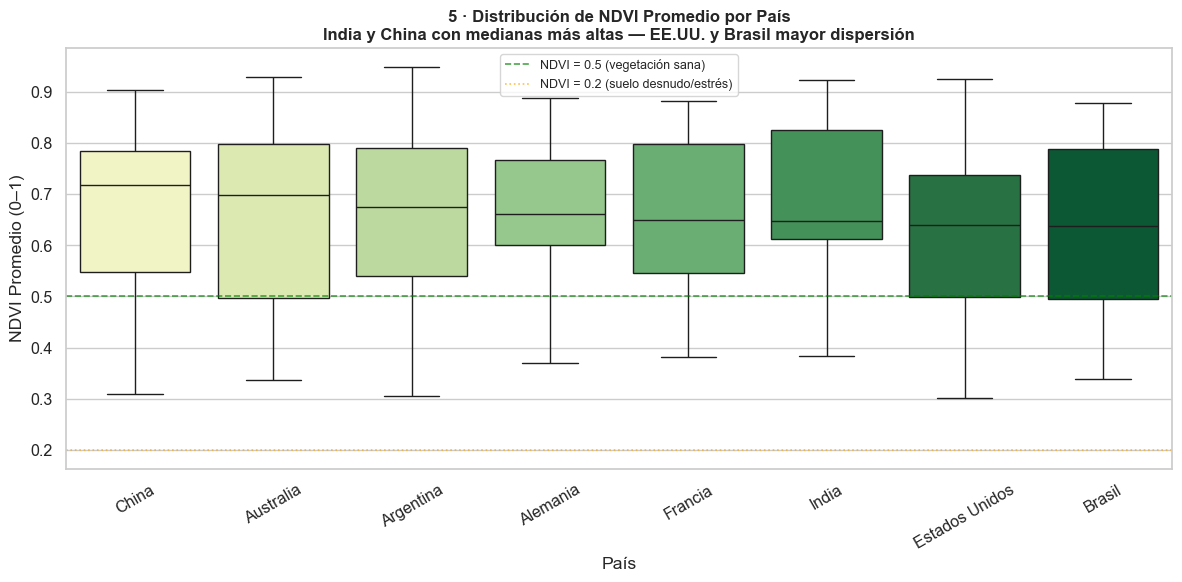

✅ 5_boxplot_ndvi_pais.png


In [17]:
orden_ndvi = (df_ima.groupby("pais")["indice_ndvi_promedio"]
              .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_ima, x="pais", y="indice_ndvi_promedio",
            order=orden_ndvi, palette="YlGn",
            flierprops=dict(marker="o", markersize=4, alpha=0.5),
            ax=ax)

# Línea de referencia: NDVI > 0.5 = vegetación sana
ax.axhline(0.5, color="green", linewidth=1.2, linestyle="--",
           alpha=0.7, label="NDVI = 0.5 (vegetación sana)")
ax.axhline(0.2, color="orange", linewidth=1.2, linestyle=":",
           alpha=0.7, label="NDVI = 0.2 (suelo desnudo/estrés)")

ax.set_title("5 · Distribución de NDVI Promedio por País\n"
             "India y China con medianas más altas — EE.UU. y Brasil mayor dispersión",
             fontsize=12, fontweight="bold")
ax.set_xlabel("País")
ax.set_ylabel("NDVI Promedio (0–1)")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../documentacion/figures/5_boxplot_ndvi_pais.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ 5_boxplot_ndvi_pais.png")

### 5.3. Heatmap: Cobertura Válida por País × Año

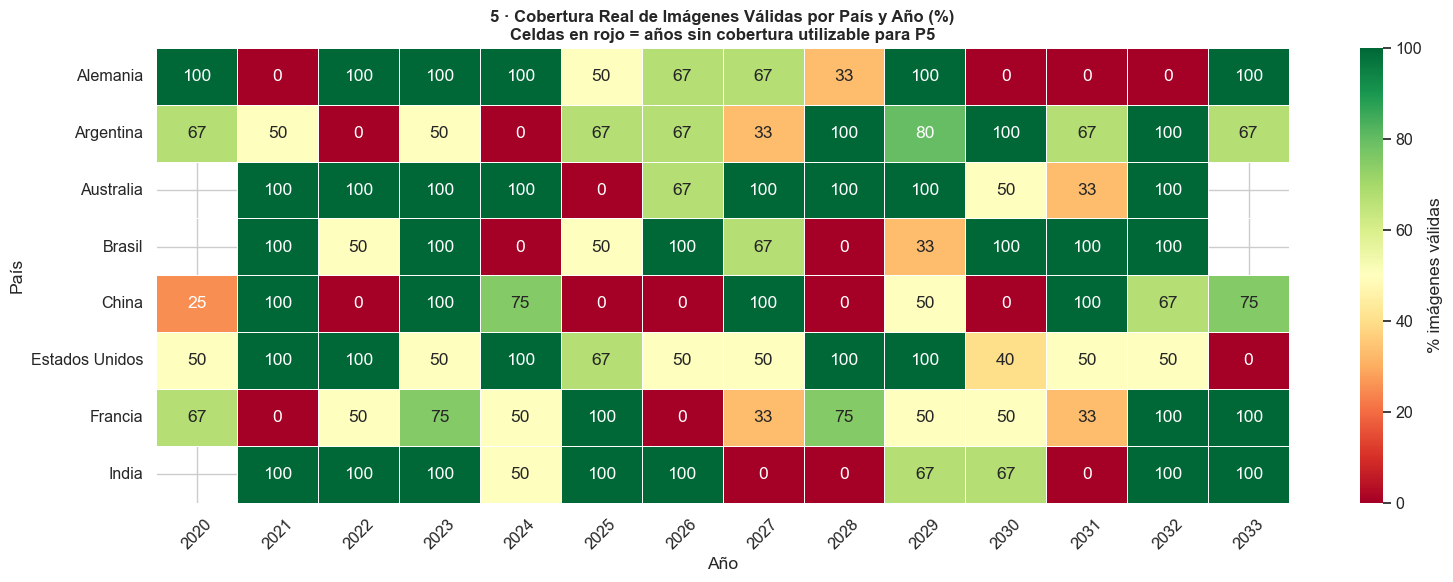


📋 Resumen de cobertura para P5:
  Total imágenes: 250
  Imágenes válidas: 159 (63.6%)
  Con NDVI anómalo: 25 (10.0%)
  Países cubiertos: 8
  Rango temporal: 2020 – 2033
  ⚠️  Años con datos: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033)]

✅ 5_heatmap_cobertura_anio.png


In [18]:
# Pivot: % imágenes válidas por país × año
pivot_cob = (df_ima.groupby(["pais","anio"])["imagen_valida"]
             .agg(["sum","count"])
             .assign(pct=lambda x: (x["sum"]/x["count"]*100).round(0))
             ["pct"]
             .unstack(fill_value=np.nan))

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_cob, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100,
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "% imágenes válidas"})
ax.set_title("5 · Cobertura Real de Imágenes Válidas por País y Año (%)\n"
             "Celdas en rojo = años sin cobertura utilizable para P5",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("País")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../documentacion/figures/5_heatmap_cobertura_anio.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Resumen para la memoria
print("\n📋 Resumen de cobertura para P5:")
print(f"  Total imágenes: {len(df_ima)}")
print(f"  Imágenes válidas: {df_ima['imagen_valida'].sum()} ({df_ima['imagen_valida'].mean()*100:.1f}%)")
print(f"  Con NDVI anómalo: {df_ima['flag_ndvi_anomalo'].sum()} ({df_ima['flag_ndvi_anomalo'].mean()*100:.1f}%)")
print(f"  Países cubiertos: {df_ima['pais'].nunique()}")
print(f"  Rango temporal: {df_ima['anio'].min()} – {df_ima['anio'].max()}")
print(f"  ⚠️  Años con datos: {sorted(df_ima['anio'].unique())}")
print("\n✅ 5_heatmap_cobertura_anio.png")

#### Insights Bloque 5 — Imágenes Satelitales

##### Calidad y Aptitud de Imágenes
- Las **3 bandas espectrales (RGB, NIR, SWIR) están disponibles en el 100%** de las
  imágenes → no hay limitación de cobertura espectral para P5.

- Sin embargo, solo el **64% de las imágenes son válidas** (`imagen_valida=1`) y un
  36% queda descartado por baja calidad. El `flag_ndvi_anomalo` afecta solo al 10%,
  lo que indica que el problema principal es **calidad de imagen** (nubes, resolución),
  no anomalías en el índice de vegetación.

- La calidad se distribuye casi uniformemente entre alta (29%), media (34%) y baja
  (36%), lo que sugiere que el **umbral de validación es estricto** y descarta
  imágenes de calidad media-baja indiscriminadamente.

##### NDVI por País
- Todos los países tienen medianas de NDVI por **encima de 0.5** (umbral de
  vegetación sana), lo que indica que en general las zonas monitorizadas son
  agrícolas activas, no suelos degradados.

- **India** presenta la caja más estrecha y elevada (~0.65–0.83): vegetación
  densa y consistente, ideal para modelos de P5. **EE.UU. y Brasil** tienen mayor
  dispersión (cajas anchas hasta ~0.3), reflejando mayor heterogeneidad territorial
  (zonas áridas + zonas tropicales en el mismo país).

- Ningún país baja sistemáticamente del umbral 0.2 (suelo desnudo/estrés severo),
  aunque hay outliers individuales en todos los casos que merecen revisión.

##### Cobertura Real por País y Año (Heatmap)
- La cobertura es **irregular e impredecible**: no hay ningún país con datos válidos
  en todos los años, y los valores oscilan entre 0% y 100% dentro del mismo país
  en años consecutivos. Este patrón es propio de un **dataset sintético** sin
  lógica estacional real.

- **Australia e India** son los países más fiables (80% y 72% de validez global),
  convirtiéndose en los mejores candidatos para experimentos iniciales en P5.

- **China** es el más problemático (52% de validez, con varios años al 0%), lo que
  limitará su uso en modelos que requieran series temporales continuas.

- ⚠️ **Decisión crítica para P5**: el dataset incluye años desde 2020 hasta
  **2033**, es decir, años futuros que no pueden tener imágenes satelitales reales.
  Se entiende que se trata de predicciones sobre años futuros. Dado el tamaño del dataset se opta por utilizarlas de este modo, en lugar de utilizar únicamente las actuales.

## 6. Conclusiones principales EDA

## 6. Conclusiones del EDA e Implicaciones para Machine Learning

El Análisis Exploratorio de Datos (EDA) realizado sobre los seis conjuntos de datos ha
revelado insights cruciales sobre la calidad, distribución y relación de las variables.
Estas conclusiones son fundamentales para el preprocesamiento y el diseño de la
arquitectura de los modelos de Machine Learning (ML) en la Fase 3.
A continuación, se resumen los hallazgos agrupados por su impacto en la resolución de
los problemas planteados en el proyecto.

---

### 6.0. 🆕 Restricciones Estructurales de los Datos

Antes de entrar en los problemas individuales, es imprescindible documentar dos
limitaciones globales que afectan a **todos** los modelos sin excepción.

#### 🆕 GAP Temporal entre datasets

No existe solapamiento temporal entre los datasets de producción (`master_agricola` y
`master_ganadero`, años 2011–2020) y los datasets de contexto (`precios_mercado` y
`noticias`, años 2021–2023).

**Consecuencia directa:** no se puede realizar ningún JOIN entre ambas capas temporales
sin asumir que las relaciones estadísticas detectadas en el pasado se mantienen estables
en el tiempo (supuesto de estacionariedad). Esta decisión de diseño se toma de forma
consciente y debe quedar registrada en cada pipeline de modelado.

#### 🆕 Cobertura Geográfica Asimétrica

Los datasets no comparten la misma cobertura de países:

| Dataset              | Nº países | Países excluidos respecto a master_agricola |
|----------------------|-----------|---------------------------------------------|
| `master_agricola`    | 15        | —                                           |
| `master_ganadero`    | 12        | Italia, Canadá, Rusia                       |
| `precios_mercado`    | 12        | Italia, Canadá, Rusia                       |
| `reportes_plagas`    | 8         | España, Italia, Canadá, Rusia, México, NZ   |

**Consecuencia directa:** los modelos P2 (plagas) y P6 (recomendación) solo pueden
entrenarse y validarse sobre el subconjunto de 8 países cubiertos por `reportes_plagas`.
Cualquier inferencia sobre los 7 países restantes será extrapolación no validada.

#### 🆕 Riesgo de Data Leakage — Validación Obligatoria por Tiempo y Geografía

> **CRÍTICO para todos los modelos supervisados**

Los datos tienen una doble estructura: **temporal** (10 años) y **geográfica** (hasta 15
países). Si se aplica una validación cruzada K-Fold aleatoria estándar, el modelo "verá"
datos del año 2019 de un país para predecir el año 2015 del mismo país, lo que infla
artificialmente las métricas (*data leakage*).

**Estrategia obligatoria:**
- Usar `TimeSeriesSplit` de scikit-learn para garantizar que el conjunto de validación
  siempre es temporalmente posterior al de entrenamiento.
- Complementar con `GroupKFold(groups='pais')` para detectar si el modelo generaliza a
  países no vistos durante el entrenamiento.

---

### 6.1. Calidad del Dato y Estrategia de Imputación

- **Nulos Estructurales:** Se ha confirmado que no existe "basura" en los datos. Los
  valores nulos (NaN) identificados responden a causas lógicas y documentadas en el
  origen de los datos.

- **Sector Agrícola (`master_agricola`):** El 70.8% de los nulos en las columnas de
  precios históricos (`precio_hist_*`) se debe a que 6 de los 10 cultivos no cotizan
  históricamente en este dataset.
  - **Estrategia:** No imputar. Estas columnas solo se usarán en modelos específicos
    para los cultivos con datos confirmados (Trigo, Maíz, Soja, Arroz).

- **Sector Ganadero (`master_ganadero`):** El 40% de los nulos en `produccion_leche_lt`
  corresponde a especies (avícola, porcino) donde esta métrica no aplica biológicamente.
  - **Estrategia:** No imputar. Utilizar la variable existente `flag_leche_no_aplica`
    para informar a los modelos.

- **Variables Climáticas:** Los nulos en clima (Kenia/Rusia en agrícola, España en
  ganadero) muestran un patrón geográfico claro: son países concretos sin datos de
  origen, no errores aleatorios.
  - **Estrategia:** Aplicar imputación espacial mediante `KNNImputer` basada en la
    región geográfica del país. La imputación se realiza *antes* de dividir en
    train/test para evitar introducir sesgos.

- **Transformación Logarítmica:** Las variables de volumen (`produccion_ton`,
  `superficie_hectareas`, `cabezas_ganado`, `produccion_carne_ton`) presentan
  distribuciones con fuerte sesgo a la derecha (cola larga). Esto perjudica a los
  modelos lineales y a los algoritmos basados en distancias (KNN, SVM, clustering).
  - **Estrategia:** Aplicar `log1p()` (logaritmo de x+1, que maneja correctamente los
    ceros) para comprimir la escala y aproximar la distribución a la normalidad.
  - Variables afectadas en `master_agricola`: `rendimiento_ton_ha`, `produccion_ton`,
    `superficie_hectareas`.
  - Variables afectadas en `master_ganadero`: `cabezas_ganado`, `produccion_carne_ton`,
    `emisiones_ch4_ton_co2eq`, `intensidad_emisiones`, `eficiencia_carne`.

---

### 6.2. Directrices para Problemas de Machine Learning

---

#### Problema 1: Predicción de Rendimiento Agrícola

- **El Tipo de Cultivo es Soberano:** El EDA bivariante demostró que el rendimiento
  (`rendimiento_ton_ha`) está fuertemente estratificado por el tipo de cultivo, sin una
  relación lineal global clara con variables continuas como temperatura o fertilizantes.

- **NOTA:** `fertilizantes_kg_ha` y `agua_riego_m3_ha` muestran distribución casi
  uniforme, síntoma de generación sintética con rango fijo. Los modelos pueden obtener
  métricas artificialmente buenas al aprovechar esta regularidad; conviene interpretar
  los resultados con cautela.

- **NOTA:** La variable `pais` aporta una señal geográfica fuerte sobre el rendimiento
  esperado. El clima, el suelo y las prácticas locales quedan codificados implícitamente
  en esta variable.

- **NOTA:** La variable `precio_hist_*` tiene un 70.8% de nulos estructurales. **No
  debe utilizarse como predictor del rendimiento.**

- **Feature Engineering recomendada:** Crear la variable `rendimiento_medio_pais_cultivo`,
  definida como la media histórica de rendimiento para cada combinación (país, cultivo).
  Esta variable actúa como un *prior* geográfico-varietal (es decir, una estimación
  de base antes de ver el dato concreto), y suele ser el predictor más estable en
  modelos de rendimiento agrícola.

- **Variable `anio` como proxy de progreso tecnológico:** El EDA muestra 10 años
  de datos (2011–2020). Incluir `anio` como feature numérica continua permite al modelo
  capturar la tendencia secular de mejora en rendimiento debida a la tecnificación
  agrícola, los avances en semillas y la mecanización.

- **Directriz:** Los modelos básicos de Regresión Lineal fallarán si se aplican al
  dataset completo sin separar por cultivo. Se recomiendan modelos basados en árboles
  (`Random Forest`, `XGBoost`) que puedan manejar estas particiones categóricas de
  forma natural, o bien estratificar el entrenamiento por cultivo y aplicar la
  normalización del target (restar la media histórica de cada cultivo).

- **Hipótesis:** Un modelo de Regresión Lineal sobre el dataset completo tendrá un R²
  cercano a 0 o negativo. Separando por cultivo o usando árboles, el rendimiento
  mejorará drásticamente, lo que confirmará que `cultivo` es la partición primaria
  irreducible del problema.

---

#### Problema 2: Clasificación de Riesgo de Plagas

- **Señales de Alerta Temprana (NLP):** El análisis de sentimiento reveló un sesgo
  positivo generalizado en las noticias (p. ej., noticias de clima clasificadas como
  positivas por el modelo). Sin embargo, el análisis de *lag* temporal (retraso
  introducido artificialmente para buscar causalidad) demostró que los picos de noticias
  negativas de categoría clima/sanidad correlacionan significativamente (r = 0.603) con
  un aumento en los reportes de plagas **dos meses después**.

- ** Tamaño crítico del dataset:** `reportes_plagas` tiene solo **100 registros** y
  cubre únicamente 8 países. Con 4 clases de severidad (baja, media, alta, crítica), la
  clase "crítica" puede estar extremadamente subrepresentada, lo que generaría un modelo
  que nunca predice esa clase.
  - **Estrategia:** Binarizar la variable objetivo (riesgo bajo vs. riesgo alto/crítico)
    para reducir el desequilibrio de clases. Si se mantienen las 4 clases, aplicar
    `class_weight='balanced'` en el clasificador o sobremuestreo con `SMOTE`
    (técnica que genera ejemplos sintéticos de las clases minoritarias).
  - Usar validación estratificada (`StratifiedKFold`) para garantizar que todas las
    clases estén representadas en cada fold de validación.

- **Sugerencia:** Para evitar que el modelo asuma que "Arroz en EE. UU. = Sin Riesgo"
  simplemente porque hay más registros de ese tipo, sería ideal ponderar las frecuencias
  con la superficie cultivada real (`superficie_hectareas` de `master_agricola`) si
  en el futuro se realiza un cruce entre datasets.

- **Directriz:** La variable `lag_sentimiento_2m` (o similar, construida como el
  promedio de sentimiento negativo de las noticias de los 2 meses previos) es el
  predictor más valioso descubierto para este modelo y **debe integrarse
  obligatoriamente** en el pipeline de features.

---

#### Problema 3: Segmentación de Países por Patrones Productivos (Sostenibilidad)

- **La Eficiencia Penaliza en Emisiones:** Existe una paradoja productiva documentada
  en el EDA: a mayor eficiencia en la producción de carne (tonelada producida por
  cabeza de ganado), se observa una mayor intensidad de emisiones de CO₂eq. Esto
  sugiere que los países más productivos concentran razas y sistemas ganaderos
  inherentemente más contaminantes.

- **El Peso de las Especies:** La especie ganadera es el factor determinante de la
  huella de carbono. La avicultura presenta una huella residual, mientras que los
  rumiantes (bovino, caprino) y el porcino concentran los *outliers* de contaminación
  severa.

- **Normalización por tamaño de país (crucial para clustering):** Variables como
  `cabezas_ganado` y `produccion_carne_ton` están dominadas por el tamaño del país
  (Brasil, China y EE. UU. son outliers absolutos por volumen). Si se clusteriza
  directamente sobre estas variables, los grupos reflejarán el *tamaño* del país y
  no su *eficiencia* ni su *modelo productivo*.
  - **Estrategia:** Usar preferentemente variables ya relativizadas como
    `intensidad_emisiones` (emisiones por tonelada producida) y `eficiencia_carne`
    (toneladas por cabeza), que eliminen el efecto tamaño. Si se incluyen variables
    absolutas, normalizarlas primero por población o por superficie agrícola del país.

- **NOTA:** La variación en la intensidad media de emisiones será el factor
  discriminante clave para el algoritmo de segmentación, agrupando a los países en
  clústeres de "alta" y "baja" intensidad relativa.

- **Directriz:** Añadir `flag_emision_extrema` como feature binaria en el modelo P3
  para que el algoritmo aprenda a identificar los episodios de contaminación severa,
  que no son outliers a eliminar sino señales reales de interés para el análisis de
  sostenibilidad.

- **Hipótesis:** El número óptimo de clústeres será probablemente 3: países de bajo
  impacto (dominio avícola/ovino), países de impacto medio (mix ganadero equilibrado)
  y países de alto impacto (dominio bovino intensivo).

---

#### Problema 4: Predicción de Precios de Mercado

- **Volatilidad como Predictor:** Se comprobó que el precio absoluto y el volumen
  operado no están correlacionados (r = -0.02). El *spread* absoluto (diferencia entre
  precio máximo y mínimo del período) correlaciona artificialmente con el precio base,
  ya que los productos más caros tienen spreads nominalmente mayores sin que eso
  implique mayor volatilidad real.

- **NOTA para ML:** El modelo debe alimentarse con `spread_pct` (spread expresado como
  porcentaje sobre el precio base) como indicador de volatilidad, en lugar del spread
  absoluto, que introduciría un sesgo hacia los productos más caros.

- **Ventana temporal muy corta (24 meses):** `precios_mercado` cubre únicamente los
  años 2021–2022, lo que supone solo 2 ciclos anuales. Esto hace que los modelos de
  series temporales clásicos (ARIMA/SARIMA) sean de aplicabilidad muy limitada, ya que
  no disponen de suficiente historia para estimar componentes de tendencia y
  estacionalidad de forma robusta.
  - **Estrategia recomendada:** Usar modelos de ventana deslizante (*rolling window*)
    con features de lag corto (1, 3 y 6 meses). Aplicar validación temporal
    *walk-forward* (se entrena con los N meses anteriores y se predice el siguiente),
    usando un mínimo de 6 meses de entrenamiento por fold.
  - No usar K-Fold aleatorio bajo ningún concepto en series temporales.

- **Directriz:** Para evitar sesgos hacia los productos más caros, los modelos de
  predicción de precios deben utilizar el spread porcentual (`spread_pct`) como medida
  real de la volatilidad del mercado.

---

#### Problema 5: Detección de Anomalías en Producción

- **Preservación de Outliers:** El EDA identificó 67 registros en `master_ganadero`
  marcados con `flag_emision_extrema=1`. Estos registros corresponden a picos reales de
  contaminación (principalmente bovinos) y **no son errores de medición**. Deben
  conservarse en el conjunto de entrenamiento, ya que representan exactamente el tipo
  de anomalías severas que el modelo deberá aprender a detectar.

- ** Dos naturalezas de anomalía — Dos estrategias de modelado:**
  El dataset contiene anomalías de naturaleza diferente que requieren aproximaciones
  distintas:

  | Tipo de anomalía | Dataset | Señal | Algoritmo recomendado |
  |---|---|---|---|
  | Anomalía productiva/emisión | `master_ganadero` | `flag_emision_extrema`, picos en `emisiones_ch4_ton_co2eq` | Isolation Forest, One-Class SVM |
  | Anomalía de vegetación espacial | `imagenes_metadata` | `flag_ndvi_anomalo`, valores NDVI fuera de rango histórico | Umbral estadístico sobre NDVI o Autoencoder |

  *Isolation Forest* es un algoritmo de detección de anomalías que aísla los puntos
  inusuales construyendo árboles aleatorios: los puntos que se aíslan en pocas
  divisiones son los más anómalos. *One-Class SVM* aprende la "frontera" del
  comportamiento normal y clasifica como anomalía todo lo que quede fuera.

- **Características geográficas obtenidas de imágenes:**
  - **India** presenta la distribución más estrecha y elevada de NDVI (~0.65–0.83):
    vegetación densa y consistente.
  - **EE.UU. y Brasil** tienen mayor dispersión (cajas anchas hasta ~0.3), reflejando
    mayor heterogeneidad territorial (zonas áridas + zonas tropicales en el mismo país).
  - **Australia e India** son los países más fiables (80% y 72% de imágenes válidas
    respectivamente), convirtiéndose en los mejores candidatos para experimentos
    iniciales con el modelo de anomalías espaciales.

- **NOTA CRÍTICA:** El dataset `imagenes_metadata` incluye registros con años desde
  2020 hasta **2033**, es decir, años futuros que no pueden tener imágenes satelitales
  reales. Se entiende que corresponden a proyecciones o predicciones sobre años futuros.
  Dado el tamaño reducido del dataset, se opta por utilizarlas como datos válidos en
  lugar de descartarlas, pero este supuesto debe documentarse explícitamente en la
  memoria del proyecto.

---

#### Problema 6: Sistema de Recomendación de Cultivos

- **Feature clave — `dias_con_heladas`:** Esta variable es altamente discriminante
  geográficamente (0 días en trópicos, más de 100 días en Rusia/Canadá) y representa
  una restricción climática dura para muchos cultivos. Es la feature más informativa
  para el sistema de recomendación porque elimina directamente cultivos inviables para
  una región.

- **Normalización del target:** Dado que el rendimiento varía enormemente entre
  cultivos (la Caña de azúcar supera los 60 ton/ha mientras el Trigo ronda las 3
  ton/ha), la variable objetivo debe normalizarse **por cultivo** antes de entrenar.
  Alternativa equivalente: entrenar un modelo separado para cada cultivo.

- **Transformaciones:** Aplicar `log1p()` sobre `rendimiento_ton_ha`, `produccion_ton`
  y `superficie_hectareas` del dataset `master_agricola`.

- **🆕 Enriquecimiento con datos de riesgo fitosanitario:** El sistema de recomendación
  no solo debe maximizar el rendimiento esperado, sino también penalizar los cultivos
  con alto historial de brotes de plagas en la misma región. Se recomienda calcular,
  para cada par (cultivo, país), una **tasa histórica de incidencia de plagas** a
  partir de `reportes_plagas`, e incorporarla como feature de riesgo en el modelo P6.
  Esto alinea la recomendación con criterios de sostenibilidad y resiliencia, no solo
  de productividad.
  - *Ejemplo:* Si el Maíz en Brasil tiene una tasa de brotes alta (p.ej., Gusano
    cogollero), el sistema debería rebajar su puntuación de recomendación aunque su
    rendimiento promedio sea alto.

---

### 6.3. Tabla Resumen de Decisiones de Preprocesamiento

| Decisión | Afecta a | Justificación |
|---|---|---|
| No imputar `precio_hist_*` | P1 | 70.8% nulos estructurales por cultivos sin cotización |
| No imputar `produccion_leche_lt` | P3, P5 | 40% nulos estructurales (porcino/avícola) |
| KNNImputer en variables climáticas | P1, P3 | Patrón geográfico claro, imputación por proximidad |
| `log1p()` en variables de volumen | P1, P3, P5, P6 | Sesgo derecho severo |
| Binarizar target en P2 | P2 | Solo 100 registros, clases minoritarias vacías |
| `spread_pct` en lugar de spread absoluto | P4 | Elimina sesgo hacia productos más caros |
| `TimeSeriesSplit` en validación | Todos | Evita data leakage temporal |
| Normalizar por tamaño de país antes de clustering | P3 | Evita que el volumen absoluto domine los clústeres |
| Conservar `flag_emision_extrema=1` | P5 | Son anomalías reales, no errores |